In [6]:
import numpy as np

data = np.load('radar_session_2026-05-18_16-22/data.npy')
print(data.dtype)
print(data.min(), data.max())
print(np.percentile(data, [0, 1, 50, 99, 100]))


for chirp in range(10):
    print(chirp, data[frame, ant, chirp, :].astype(int))

import matplotlib.pyplot as plt

plt.hist(data.flatten(), bins=200)
plt.title("Raw ADC value histogram")
plt.xlabel("ADC value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

frame = 2001
ant = 0
chirp = 2

plt.plot(data[frame, ant, chirp, :], marker="o")
plt.title("One raw chirp")
plt.xlabel("Sample index")
plt.ylabel("ADC value")
plt.grid(True)
plt.show()

float32
1484.0 3478.0
[1484. 1502. 2826. 3456. 3478.]


NameError: name 'frame' is not defined

In [7]:
import numpy as np

# 1. Falsch formatierte Daten laden
# (Passe den Dateinamen an deine Aufnahme an)
input_file = 'test123.npy'
old_data = np.load(input_file)

# Das Shape deines Arrays auslesen (z.B. Frames, 3, 128, 32)
num_frames, num_rx, num_chirps, num_samples = old_data.shape
print(f"Lade Daten mit Shape: {old_data.shape}")

# 2. Den "Fehler" rückgängig machen: 
# Wir machen aus dem 3D-Radar-Cube pro Frame wieder einen flachen 1D-Array.
# Das stellt exakt den Byte-Stream wieder her, den data_bytes = self.ser.read() geliefert hat.
raw_stream = old_data.reshape((num_frames, num_chirps * num_samples * num_rx))

# 3. Die korrekte Struktur anwenden (Laut Infineon Doku)
# Der Chip sendet: [Chirp 0, Sample 0, Rx0], [Chirp 0, Sample 0, Rx1]...
interleaved = raw_stream.reshape((num_frames, num_chirps, num_samples, num_rx))

# 4. Achsen umsortieren in dein Zielformat (Frames, Antennen, Chirps, Samples)
# Achse 0 (Frames) bleibt wo sie ist
# Achse 3 (Rx) wandert auf Position 1
# Achse 1 (Chirps) wandert auf Position 2
# Achse 2 (Samples) wandert auf Position 3
fixed_data = np.transpose(interleaved, (0, 3, 1, 2))

# 5. Zur Sicherheit checken und abspeichern
print(f"Repariertes Shape: {fixed_data.shape}") 
# Hinweis: Das Shape sieht genauso aus wie vorher, aber die Werte innendrin 
# sind jetzt physikalisch korrekt sortiert!

output_file = 'test123_fixed.npy'
np.save(output_file, fixed_data)
print(f"Saubere Daten gespeichert unter: {output_file}")

Lade Daten mit Shape: (2000, 1, 32, 8)
Repariertes Shape: (2000, 1, 32, 8)
Saubere Daten gespeichert unter: test123_fixed.npy


In [ ]:
#Tempel Meausrments Comparison
'''
nsc_path = "mmWave/2026-05-22_18.46.42.nsc"
processed_mmwave_path = "radar_invivo_fps_sweep_2026-05-22_18-00/mmwave_processed.npz"
mmwave_sync_path = "radar_invivo_fps_sweep_2026-05-22_18-00/fps_200_order_01_rep_1_sync_state.npy"
mmwave_raw_path = "radar_invivo_fps_sweep_2026-05-22_18-00/fps_200_order_01_rep_1_data.npy"

# Raw mmWave recording

mmwave_duration_s = 20 * 60   # example: 20 min
mmwave_time_shift_s = 0


# Finapres marker event times [s]
finapres_event_1_s = 301.6524
finapres_event_2_s = 1498.508

# Corresponding mmWave sync event times BEFORE correction [s]
mmwave_event_1_s = 0.49
mmwave_event_2_s = 1199.94


'''

#Wrist Measurments Comparisons
'''
nsc_path = "mmWave/2026-05-22_19.24.20.nsc"
mmwave_raw_path = "radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_data.npy"
mmwave_sync_path = "radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_sync_state.npy"
processed_mmwave_path = "radar_invivo_fps_sweep_2026-05-22_18-36/mmwave_processed.npz"

mmwave_duration_s = 20 * 60   # example: 20 min

mmwave_time_shift_s = 0

# Finapres marker event times [s]
finapres_event_1_s = 242.5874
finapres_event_2_s = 1439.447

# Corresponding mmWave sync event times BEFORE correction [s]
mmwave_event_1_s = 0.49
mmwave_event_2_s = 1199.8

force_reprocess_mmwave = True


'''


'\nnsc_path = "mmWave/2026-05-22_18.46.42.nsc"\n\n# Raw mmWave recording\nmmwave_raw_path = "radar_invivo_fps_sweep_2026-05-22_18-00/fps_200_order_01_rep_1_data.npy"\n\n\n# Finapres marker event times [s]\nfinapres_event_1_s = 301.6524\nfinapres_event_2_s = 1498.508\n\n# Corresponding mmWave sync event times BEFORE correction [s]\nmmwave_event_1_s = 0.49\nmmwave_event_2_s = 1199.94\n\nprocessed_mmwave_path = "radar_invivo_fps_sweep_2026-05-22_18-00/mmwave_processed.npz"\nmmwave_sync_path = "radar_invivo_fps_sweep_2026-05-22_18-00/fps_200_order_01_rep_1_sync_state.npy"\n\n'

In [376]:
import os
import zipfile
import numpy as np
import xml.etree.ElementTree as ET


from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d
import plotly.graph_objects as go
from plotly.subplots import make_subplots

nsc_path = "mmWave/2026-05-22_19.24.20.nsc"
mmwave_raw_path = "radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_data.npy"
mmwave_sync_path = "radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_sync_state.npy"
processed_mmwave_path = "radar_invivo_fps_sweep_2026-05-22_18-36/mmwave_processed.npz"

mmwave_duration_s = 20 * 60   # example: 20 min

mmwave_time_shift_s = 0

# Finapres marker event times [s]
finapres_event_1_s = 242.5874
finapres_event_2_s = 1439.447

# Corresponding mmWave sync event times BEFORE correction [s]
mmwave_event_1_s = 0.49
mmwave_event_2_s = 1199.8

force_reprocess_mmwave = True


# mmWave sync signal

POINTS_PER_BEAT = 200
mmwave_sync_fs = 500  # sampling rate of sync signal, adjust if needed

# Radar parameters
RADAR_FREQ_GHZ = 60.75
ANTENNA_INDEX = 0

# Search only reasonable close range bins
BIN_SEARCH_START = 1
BIN_SEARCH_END = 3

# Optional: use only a clean section for automatic bin selection
# Set to None to use full recording
BIN_SELECTION_START_S = 420
BIN_SELECTION_END_S = 500

# SNR bands
SIGNAL_BAND = (0.5, 8.0)
NOISE_BAND = (8.0, 12.0)

# Plot settings
MAX_POINTS_PER_SIGNAL = 3_000_000


# ============================================================
# BASIC HELPERS
# ============================================================

def normalize_for_overlay(x):
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-12)


def downsample_for_plot(t, y, max_points=150_000):
    
    return t, y

    stride = int(np.ceil(len(y) / max_points))
    return t[::stride], y[::stride]


def bandpass_filter(x, fs, lowcut, highcut, order=3, axis=0):
    nyquist = 0.5 * fs

    if highcut >= nyquist:
        highcut = 0.95 * nyquist

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, x, axis=axis)


def estimate_snr_db(x, fs, signal_band=(0.5, 6.0), noise_band=(6.0, 12.0)):
    signal = bandpass_filter(x, fs, signal_band[0], signal_band[1], order=3)
    noise = bandpass_filter(x, fs, noise_band[0], noise_band[1], order=3)

    p_signal = np.nanmean(signal ** 2)
    p_noise = np.nanmean(noise ** 2)

    return 10 * np.log10((p_signal + 1e-12) / (p_noise + 1e-12))


# ============================================================
# NOVASCOPE / NSC READER
# ============================================================

def find_file_in_zip(zip_file, filename):
    for name in zip_file.namelist():
        if name.endswith("/" + filename) or name.endswith(filename):
            return name
    raise FileNotFoundError(f"{filename} not found in archive")


def read_xml_from_zip(zip_file, filename):
    path = find_file_in_zip(zip_file, filename)
    xml_bytes = zip_file.read(path)
    xml_text = xml_bytes.decode("utf-8-sig")
    return ET.fromstring(xml_text)


def read_nsd_y_from_zip(zip_file, filename):
    path = find_file_in_zip(zip_file, filename)
    raw = zip_file.read(path)

    y = np.frombuffer(raw, dtype="<i2").astype(float)
    y[y == -32768] = np.nan

    return y


def read_nsd_x_from_zip(zip_file, filename):
    """
    Reads NovaScope X-axis data.
    The X files usually contain time ticks. We try uint32 ticks first.
    """
    path = find_file_in_zip(zip_file, filename)
    raw = zip_file.read(path)

    # Most likely: uint32 ticks
    x_ticks = np.frombuffer(raw, dtype="<u4").astype(float)

    # NovaScope often uses 0.1 ms ticks
    t = x_ticks * 1e-4

    # Make time start at zero
    t = t - t[0]

    return t


def parse_nsc_signals(nsc_path):
    signals = {}

    with zipfile.ZipFile(nsc_path, "r") as z:
        root = read_xml_from_zip(z, "Measurement.xml")

        for container in root.findall(".//SignalContainer"):

            # Get X-axis file for this signal container
            x_file = None
            x_axis = container.find("XAxis")

            if x_axis is not None:
                x_file_node = x_axis.find("DataFile")
                if x_file_node is not None:
                    x_file = x_file_node.text

            for sig in container.findall(".//Signal"):
                short_name = sig.findtext("ShortName")
                name = sig.findtext("Name")
                data_file = sig.findtext("DataFile")
                units = sig.findtext("Units")
                sample_rate = sig.findtext("SampleRate")

                if short_name and data_file:
                    signals[short_name] = {
                        "short_name": short_name,
                        "name": name,
                        "data_file": data_file,
                        "x_file": x_file,
                        "units": units,
                        "sample_rate": float(sample_rate) if sample_rate else None,
                    }

    return signals


def load_nsc_signal(nsc_path, short_name):
    signals = parse_nsc_signals(nsc_path)

    if short_name not in signals:
        available = "\n".join(sorted(signals.keys()))
        raise KeyError(f"Signal '{short_name}' not found. Available signals:\n{available}")

    info = signals[short_name]

    with zipfile.ZipFile(nsc_path, "r") as z:
        y = read_nsd_y_from_zip(z, info["data_file"])

        t = None

        # Prefer true X-axis from NovaScope
        if info["x_file"] is not None:
            try:
                t_candidate = read_nsd_x_from_zip(z, info["x_file"])

                if len(t_candidate) == len(y):
                    t = t_candidate
                else:
                    print(
                        f"Warning: X/Y length mismatch for {short_name}: "
                        f"len(x)={len(t_candidate)}, len(y)={len(y)}. "
                        f"Falling back to sample rate."
                    )
            except Exception as e:
                print(f"Could not read X-axis for {short_name}: {e}")

    # Fallback only if X-axis failed
    if t is None:
        fs = info["sample_rate"]

        if fs is None:
            raise ValueError(f"No valid X-axis or sample rate found for {short_name}")

        t = np.arange(len(y)) / fs

    fs_estimated = 1 / np.nanmedian(np.diff(t))

    print(
        f"{short_name}: duration={t[-1]:.2f}s, "
        f"samples={len(y)}, fs_estimated={fs_estimated:.2f} Hz, "
        f"file={info['data_file']}, x_file={info['x_file']}"
    )

    return t, y, fs_estimated, info



# ============================================================
# PEAK / FOOTPOINT DETECTION ON READY SIGNALS
# No filtering, no polarity correction
# ============================================================
def detect_peaks_and_footpoints(signal, fs):
    """
    Detect systolic peaks and one foot/diastolic valley before each peak.

    Important:
    The footpoint is NOT selected as the deepest point in the search window.
    Instead, the last local valley before the next systolic peak is selected.
    This avoids selecting an earlier, deeper reflection-related valley.
    """

    signal = np.asarray(signal, dtype=float)

    # Work on a copy for peak detection
    y = signal.copy()

    # If signal contains NaNs, interpolate them for peak detection
    nans = np.isnan(y)
    if np.any(nans):
        valid = ~nans

        if np.sum(valid) < 10:
            return np.array([], dtype=int), np.array([], dtype=int)

        y[nans] = np.interp(
            np.flatnonzero(nans),
            np.flatnonzero(valid),
            y[valid]
        )

    # ------------------------------------------------------------
    # 1. Detect systolic peaks
    # ------------------------------------------------------------
    min_peak_distance = max(1, int(0.45 * fs))
    peak_prominence = max(1e-12, 0.25 * np.nanstd(y))

    systolic_peaks, _ = find_peaks(
        y,
        distance=min_peak_distance,
        prominence=peak_prominence
    )

    if len(systolic_peaks) < 2:
        return systolic_peaks, np.array([], dtype=int)

    footpoints = []

    # ------------------------------------------------------------
    # 2. For each peak, find the LAST local valley before it
    # ------------------------------------------------------------
    for i in range(1, len(systolic_peaks)):
        prev_peak = systolic_peaks[i - 1]
        curr_peak = systolic_peaks[i]

        rr = curr_peak - prev_peak

        # Search before current systolic peak.
        # The end excludes the immediate peak region.
        search_start = curr_peak - int(0.65 * rr)
        search_end = curr_peak - int(0.05 * rr)

        search_start = max(0, search_start)
        search_end = max(search_start + 1, search_end)

        segment = y[search_start:search_end]

        if len(segment) < 3:
            continue

        if np.all(np.isnan(segment)):
            continue

        # Find local valleys inside the search window
        local_valleys, _ = find_peaks(
            -segment,
            distance=max(1, int(0.06 * fs)),
            prominence=max(1e-12, 0.03 * np.nanstd(segment))
        )

        if len(local_valleys) > 0:
            # Take the LAST valley before the systolic peak
            foot_idx = search_start + local_valleys[-1]
        else:
            # Fallback:
            # If no local valley is detected, take the minimum in the last
            # part of the search window instead of the full window.
            fallback_start = int(0.65 * len(segment))
            fallback_segment = segment[fallback_start:]

            if len(fallback_segment) == 0 or np.all(np.isnan(fallback_segment)):
                continue

            foot_idx = search_start + fallback_start + np.nanargmin(fallback_segment)

        footpoints.append(foot_idx)

    return systolic_peaks, np.array(footpoints, dtype=int)

def extract_normalized_beats(signal, valley_indices, points_per_beat=200):
    """
    Extract beat segments between consecutive diastolic valleys.
    Each beat is normalized in amplitude and time.
    """

    beats = []

    valley_indices = np.sort(valley_indices)

    for i in range(len(valley_indices) - 1):
        start = valley_indices[i]
        end = valley_indices[i + 1]

        beat = signal[start:end]

        if len(beat) < 10:
            continue

        # amplitude normalization: 0 ... 1
        beat = beat - np.nanmin(beat)
        beat = beat / (np.nanmax(beat) + 1e-12)

        # time normalization: 0 ... 1
        x_old = np.linspace(0, 1, len(beat))
        x_new = np.linspace(0, 1, points_per_beat)

        f = interp1d(x_old, beat, kind="linear")
        beat_interp = f(x_new)

        beats.append(beat_interp)

    return np.array(beats)

def compute_ibi_from_indices(t, indices):
    """
    Compute IBI from event indices.
    Works for peaks or footpoints.
    """
    event_times = t[indices]

    if len(event_times) < 2:
        return np.array([]), np.array([])

    ibi_s = np.diff(event_times)
    ibi_ms = ibi_s * 1000.0
    ibi_time = event_times[1:]

    return ibi_time, ibi_ms


def process_ready_signal(
    t,
    signal,
    fs,
    name,
):
    """
    Apply peak and footpoint detection to an already processed signal.

    Important:
    - No additional filtering is applied.
    - No polarity correction is applied.
    - The sampling rate is provided explicitly.
    """

    y = np.asarray(signal, dtype=float).copy()

    systolic_peaks, diastolic_valleys = detect_peaks_and_footpoints(
        y,
        fs
    )

    ibi_time, ibi_ms = compute_ibi_from_indices(
        t,
        diastolic_valleys
    )

    if len(ibi_ms) > 0:
        hr_bpm = 60000.0 / ibi_ms
    else:
        hr_bpm = np.array([])

    beats = extract_normalized_beats(
        y,
        diastolic_valleys,
        points_per_beat=POINTS_PER_BEAT
    )

    if len(beats) > 0:
        average_pulse = np.nanmean(beats, axis=0)
        std_pulse = np.nanstd(beats, axis=0)
    else:
        average_pulse = None
        std_pulse = None

    print(f"\n{name}")
    print(f"Used fs: {fs:.2f} Hz")
    print(f"Detected systolic peaks: {len(systolic_peaks)}")
    print(f"Detected diastolic valleys: {len(diastolic_valleys)}")
    print(f"Detected IBI values: {len(ibi_ms)}")

    return {
        "name": name,
        "t": t,
        "fs": fs,
        "signal": y,
        "systolic_peaks": systolic_peaks,
        "diastolic_valleys": diastolic_valleys,
        "ibi_time": ibi_time,
        "ibi_ms": ibi_ms,
        "hr_bpm": hr_bpm,
        "beats": beats,
        "average_pulse": average_pulse,
        "std_pulse": std_pulse,
    }

# ============================================================
# MMWAVE PROCESSING
# ============================================================

def process_mmwave_raw(
    npy_path,
    duration_s,
    radar_freq_ghz=60.75,
    antenna_index=0,
    bin_search_start=1,
    bin_search_end=8,
    bin_selection_start_s=None,
    bin_selection_end_s=None,
    signal_band=(0.5, 8.0),
    noise_band=(8.0, 12.0),
):
    """
    Expected raw data shape:
    (frames, antennas, chirps, samples)
    """

    data = np.load(npy_path)

    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames / duration_s

    print("mmWave raw shape:", data.shape)
    print("Estimated mmWave fps:", fps)

    # Remove DC over ADC samples
    mean_removed = data - np.mean(data, axis=-1, keepdims=True)

    # Window over ADC samples
    window = np.hanning(num_samples)
    windowed_data = mean_removed * window

    # Range FFT
    range_fft = np.fft.rfft(windowed_data, axis=-1)

    # Complex averaging over chirps, then phase extraction
    complex_mean = np.mean(range_fft[:, antenna_index, :, :], axis=1)

    phase = np.angle(complex_mean)
    unwrapped_phase = np.unwrap(phase, axis=0)

    # Phase to displacement
    c = 3e8
    wavelength_m = c / (radar_freq_ghz * 1e9)
    wavelength_mm = wavelength_m * 1000

    displacement_mm = (wavelength_mm * unwrapped_phase) / (4 * np.pi)

    t = np.arange(num_frames) / fps

    num_bins = displacement_mm.shape[1]

    if bin_search_end is None:
        bin_search_end = num_bins

    bin_search_end = min(bin_search_end, num_bins)
    bin_indices = np.arange(bin_search_start, bin_search_end)

    if len(bin_indices) == 0:
        raise ValueError("No range bins available for bin selection.")

    # Use only selected clean time range for automatic bin selection
    if bin_selection_start_s is not None and bin_selection_end_s is not None:
        selection_mask = (t >= bin_selection_start_s) & (t <= bin_selection_end_s)
    else:
        selection_mask = np.ones_like(t, dtype=bool)

    snr_per_bin = []

    for bin_idx in bin_indices:
        x = displacement_mm[selection_mask, bin_idx]

        try:
            snr = estimate_snr_db(
                x,
                fps,
                signal_band=signal_band,
                noise_band=noise_band
            )
        except Exception:
            snr = -np.inf

        snr_per_bin.append(snr)

    snr_per_bin = np.array(snr_per_bin)

    best_bin = int(bin_indices[np.nanargmax(snr_per_bin)])
    best_snr_db = float(np.nanmax(snr_per_bin))

    print("Best range bin:", best_bin)
    print("Best bin SNR:", best_snr_db, "dB")

    # Extract final full-length radar signal from selected bin
    radar_signal = bandpass_filter(
        displacement_mm[:, best_bin],
        fps,
        signal_band[0],
        signal_band[1],
        order=3
    )

    # Optional polarity correction
    #if np.nanmean(radar_signal ** 3) < 0:
    radar_signal *= -1

    return {
        "t": t,
        "signal": radar_signal,
        "fps": fps,
        "best_bin": best_bin,
        "best_snr_db": best_snr_db,
        "snr_per_bin": snr_per_bin,
        "bin_indices": bin_indices,
        "raw_shape": data.shape,
    }


def load_or_process_mmwave():
    if os.path.exists(processed_mmwave_path) and not force_reprocess_mmwave:
        print("Loading processed mmWave:", processed_mmwave_path)
        processed = np.load(processed_mmwave_path)

        return {
            "t": processed["t"],
            "signal": processed["signal"],
            "fps": float(processed["fps"]),
            "best_bin": int(processed["best_bin"]),
            "best_snr_db": float(processed["best_snr_db"]),
            "snr_per_bin": processed["snr_per_bin"],
            "bin_indices": processed["bin_indices"],
        }

    print("Processing raw mmWave data...")

    result = process_mmwave_raw(
        npy_path=mmwave_raw_path,
        duration_s=mmwave_duration_s,
        radar_freq_ghz=RADAR_FREQ_GHZ,
        antenna_index=ANTENNA_INDEX,
        bin_search_start=BIN_SEARCH_START,
        bin_search_end=BIN_SEARCH_END,
        bin_selection_start_s=BIN_SELECTION_START_S,
        bin_selection_end_s=BIN_SELECTION_END_S,
        signal_band=SIGNAL_BAND,
        noise_band=NOISE_BAND,
    )

    np.savez(
        processed_mmwave_path,
        t=result["t"],
        signal=result["signal"],
        fps=result["fps"],
        best_bin=result["best_bin"],
        best_snr_db=result["best_snr_db"],
        snr_per_bin=result["snr_per_bin"],
        bin_indices=result["bin_indices"],
    )

    print("Saved processed mmWave:", processed_mmwave_path)

    return result

In [377]:
# ============================================================
# LOAD SIGNALS
# ============================================================

# NovaScope / Finapres
t_finger, finger, fs_finger, info_finger = load_nsc_signal(nsc_path, "fiAP")
t_brachial, brachial, fs_brachial, info_brachial = load_nsc_signal(nsc_path, "reBAP")
t_marker, marker, fs_marker, info_marker = load_nsc_signal(nsc_path, "Marker")

print("Finger:", fs_finger, "Hz", info_finger["units"])
print("Brachial:", fs_brachial, "Hz", info_brachial["units"])
print("Marker:", fs_marker, "Hz", info_marker["units"])

# ============================================================
# LOAD MMWAVE SIGNAL + SYNC
# ============================================================

mmwave = load_or_process_mmwave()

mmwave_signal = mmwave["signal"]
t_mmwave_raw = mmwave["t"]          # raw radar time axis, e.g. 0 ... 1200 s

mmwave_sync = np.load(mmwave_sync_path)

# Build raw sync time axis so that sync spans the same recording duration
# as the mmWave radar data
t_mmwave_sync_raw = np.linspace(
    0,
    t_mmwave_raw[-1],
    len(mmwave_sync),
    endpoint=True
)

print("mmWave radar duration:", t_mmwave_raw[-1] - t_mmwave_raw[0], "s")
print("mmWave sync duration:", t_mmwave_sync_raw[-1] - t_mmwave_sync_raw[0], "s")
# ============================================================
# TIME ALIGNMENT: OFFSET + STRETCH
# ============================================================



time_scale = (finapres_event_2_s - finapres_event_1_s) / (
    mmwave_event_2_s - mmwave_event_1_s
)

time_offset_s = finapres_event_1_s - time_scale * mmwave_event_1_s

print("time_scale:", time_scale)
print("time_offset_s:", time_offset_s)

# Apply the SAME correction to radar data and sync signal
t_mmwave = t_mmwave_raw * time_scale + time_offset_s
t_mmwave_sync = t_mmwave_sync_raw * time_scale + time_offset_s


# ============================================================
# NORMALIZE FOR VISUAL OVERLAY
# ============================================================
brachial = brachial /100
finger = (finger - 16384) / 50


finger_plot = normalize_for_overlay(finger)
brachial_plot = normalize_for_overlay(brachial)
marker_plot = normalize_for_overlay(marker)
mmwave_plot = normalize_for_overlay(mmwave_signal)
mmwave_sync_plot = normalize_for_overlay(mmwave_sync)


# ============================================================
# RUN DETECTION ON READY / SYNCHRONIZED SIGNALS
# ============================================================

finger_result = process_ready_signal(
    t=t_finger,
    signal=finger,
    fs=fs_finger,
    name="Finapres finger pressure",
)

brachial_result = process_ready_signal(
    t=t_brachial,
    signal=brachial,
    fs=fs_brachial,
    name="Finapres reconstructed brachial pressure",
)

mmwave_result = process_ready_signal(
    t=t_mmwave,
    signal=mmwave_signal,
    fs=200,
    name="mmWave wrist",
)

results = {
    "finger": finger_result,
    "brachial": brachial_result,
    "mmwave": mmwave_result,
}


# ============================================================
# DOWNSAMPLE ONLY FOR PLOTTING
# ============================================================

t_finger_p, finger_p = downsample_for_plot(t_finger, finger_plot, MAX_POINTS_PER_SIGNAL)
t_brachial_p, brachial_p = downsample_for_plot(t_brachial, brachial_plot, MAX_POINTS_PER_SIGNAL)
t_marker_p, marker_p = downsample_for_plot(t_marker, marker_plot, MAX_POINTS_PER_SIGNAL)
t_mmwave_p, mmwave_p = downsample_for_plot(t_mmwave, mmwave_plot, MAX_POINTS_PER_SIGNAL)
t_mmwave_sync_p, mmwave_sync_p = downsample_for_plot(
    t_mmwave_sync,
    mmwave_sync_plot,
    MAX_POINTS_PER_SIGNAL
)
# ============================================================
# EXPERIMENT PROTOCOL MARKERS
# ============================================================
# Protocol times are relative to the start of the mmWave recording.
# They are then transformed to the global Finapres/NovaScope time axis
# using the same time_scale and time_offset_s as the mmWave signal.

protocol = [
    ("Rest", 90),
    ("Hand Grip", 30),
    ("Rest", 90),
    ("Hand Grip", 30),
    ("Rest", 90),
    ("Hand Grip", 30),

    ("Rest", 90),
    ("Cold Pressor", 30),
    ("Rest", 90),
    ("Cold Pressor", 30),

    ("Rest", 90),
    ("Valsalva", 30),
    ("Rest", 90),
    ("Valsalva", 30),

    ("Rest", 90),
    ("Stand Up", 30),
    ("Rest", 90),
    ("Stand Up", 30),
    ("Rest", 120),
]


def build_protocol_intervals(protocol):
    intervals = []
    t_start = 0.0

    for label, duration in protocol:
        t_end = t_start + duration
        intervals.append({
            "label": label,
            "start_mmwave": t_start,
            "end_mmwave": t_end,
            "duration": duration,
        })
        t_start = t_end

    return intervals


protocol_intervals = build_protocol_intervals(protocol)

print("Total protocol duration:", protocol_intervals[-1]["end_mmwave"], "s")


fiAP: duration=1446.12s, samples=289212, fs_estimated=200.00 Hz, file=Signal_Y_fiAP_FinAP.nsd, x_file=Signal_X_NIBPM_HighFrequent.nsd
reBAP: duration=1445.89s, samples=289195, fs_estimated=200.00 Hz, file=Algo_Y_reBAP_ReBAP.nsd, x_file=Algo_X_PressureWave_ReBr.nsd
Marker: duration=1446.12s, samples=722990, fs_estimated=500.00 Hz, file=Signal_Y_Marker_AnaIn1.nsd, x_file=Signal_X_AnalogIO_AnaIn1.nsd
Finger: 200.0000000001819 Hz mmHg
Brachial: 200.0000000001819 Hz mmHg
Marker: 500.0000000011653 Hz 
Processing raw mmWave data...
mmWave raw shape: (240000, 1, 32, 8)
Estimated mmWave fps: 200.0
Best range bin: 2
Best bin SNR: 24.640546319275085 dB
Saved processed mmWave: radar_invivo_fps_sweep_2026-05-22_18-36/mmwave_processed.npz
mmWave radar duration: 1199.995 s
mmWave sync duration: 1199.995 s
time_scale: 0.9979568251744751
time_offset_s: 242.0984011556645

Finapres finger pressure
Used fs: 200.00 Hz
Detected systolic peaks: 1623
Detected diastolic valleys: 1622
Detected IBI values: 1621


In [378]:
import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

OUTPUT_ROOT = "plots"
LOCATION_KEY = "wrist"   # "temple" or "wrist"

SAVE_DPI = 500
SHOW_FIGURES = False      # True if you want every plot displayed

SEGMENT_SPACING_S = 60
SEGMENT_DURATION_S = 20
IBI_CONTEXT_S = 5.0 

POINTS_PER_BEAT = 200

segment_names = [
    "rest1",
    "hand1",
    "rest2",
    "hand2",
    "rest3",
    "hand3",
    "rest4",
    "cold1",
    "rest5",
    "cold2",
    "rest6",
    "valsal1",
    "rest7",
    "valsal2",
    "rest8",
    "stand1",
    "rest9",
    "stand2",
    "rest10",
]


SEGMENT_LABELS = {
    "rest1": "Rest Period 1",
    "rest2": "Rest Period 2",
    "rest3": "Rest Period 3",
    "rest4": "Rest Period 4",
    "rest5": "Rest Period 5",
    "rest6": "Rest Period 6",
    "rest7": "Rest Period 7",
    "rest8": "Rest Period 8",
    "rest9": "Rest Period 9",
    "rest10": "Rest Period 10",

    "hand1": "Hand Grip 1",
    "hand2": "Hand Grip 2",
    "hand3": "Hand Grip 3",

    "cold1": "Cold Pressor 1",
    "cold2": "Cold Pressor 2",

    "valsal1": "Valsalva 1",
    "valsal2": "Valsalva 2",

    "stand1": "Stand Up 1",
    "stand2": "Stand Up 2",
}


def segment_label(name):
    return SEGMENT_LABELS.get(name, name)


def location_label(location):
    return {
        "temple": "Temple",
        "wrist": "Wrist",
    }.get(location, location.capitalize())


def is_rest_segment(name):
    return name.startswith("rest")


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


SAVE_DPI = 500

def save_fig(fig, folder, filename):
    os.makedirs(folder, exist_ok=True)

    pdf_path = os.path.join(folder, filename + ".pdf")

    fig.savefig(
        pdf_path,
        dpi=SAVE_DPI,
        bbox_inches="tight"
    )

    print("Saved:", pdf_path)

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

In [379]:
def crop_result(result, start_s, end_s):
    """
    Crops one already processed result dict to an interval.
    Peaks/IBI/average waveform are recomputed inside the cropped interval.
    """

    t = result["t"]
    y = result["signal"]
    fs = result["fs"]

    mask = (t >= start_s) & (t <= end_s)

    t_crop = t[mask]
    y_crop = y[mask]

    if len(t_crop) < 10:
        return None

    peaks, valleys = detect_peaks_and_footpoints(y_crop, fs)

    ibi_time, ibi_ms = compute_ibi_from_indices(t_crop, valleys)

    beats = extract_normalized_beats(
        y_crop,
        valleys,
        points_per_beat=POINTS_PER_BEAT
    )

    if len(beats) > 0:
        avg = np.nanmean(beats, axis=0)
        std = np.nanstd(beats, axis=0)
    else:
        avg = None
        std = None

    return {
        "name": result["name"],
        "t": t_crop,
        "fs": fs,
        "signal": y_crop,
        "systolic_peaks": peaks,
        "diastolic_valleys": valleys,
        "ibi_time": ibi_time,
        "ibi_ms": ibi_ms,
        "beats": beats,
        "average_pulse": avg,
        "std_pulse": std,
    }

def add_maneuver_shading(ax, total_duration_s=20, rest_s=4, transition_s=2):
    rest_start = 0
    rest_end = rest_s

    transition_start = rest_end
    transition_end = rest_end + transition_s

    maneuver_start = transition_end
    maneuver_end = total_duration_s

    # Rest
    ax.axvspan(
        rest_start,
        rest_end,
        facecolor="0.96",
        edgecolor="0.75",
        hatch=".",
        alpha=0.35,
        linewidth=0,
        zorder=0,
    )

    # Transition
    ax.axvspan(
        transition_start,
        transition_end,
        facecolor="0.90",
        edgecolor="0.65",
        hatch="..",
        alpha=0.40,
        linewidth=0,
        zorder=0,
    )

    # Maneuver
    ax.axvspan(
        maneuver_start,
        maneuver_end,
        facecolor="0.96",
        edgecolor="0.75",
        hatch=".",
        alpha=0.35,
        linewidth=0,
        zorder=0,
    )
def plot_ibi(segment_results, segment_name, location, output_dir, segment_start_s, segment_end_s):
    label = segment_label(segment_name)
    loc = location_label(location)
    maneuver = not is_rest_segment(segment_name)

    segment_duration = segment_end_s - segment_start_s

    fig, ax = plt.subplots(figsize=(8, 3.5))

    styles = {
        "mmwave": {
            "label": "mmWave",
            "linestyle": "-",
            "linewidth": 2.0,
            "color": "#1f77b4",
        },
        "finger": {
            "label": "Finger Pressure",
            "linestyle": "--",
            "linewidth": 2.0,
            "color": "#ff7f0e",
        },
    }

    for key in ["mmwave", "finger"]:
        res = segment_results[key]

        if res is None or len(res["ibi_ms"]) == 0:
            continue

        # IBI times are absolute/global; convert to relative segment time
        x = res["ibi_time"] - segment_start_s
        y = res["ibi_ms"]

        # Show only IBIs that fall inside the visible 20 s segment
        mask = (x >= 0) & (x <= segment_duration)

        ax.plot(
            x[mask],
            y[mask],
            linestyle=styles[key]["linestyle"],
            linewidth=styles[key]["linewidth"],
            color=styles[key]["color"],
            label=styles[key]["label"],
        )

    if maneuver:
        add_maneuver_shading(ax, total_duration_s=segment_duration)

    ax.set_xlim(0, segment_duration)
    ax.set_xticks(np.arange(0, segment_duration + 0.1, 5))

    ax.set_title(f"Inter-Beat Intervals – {label} ({loc})", fontweight="bold")
    ax.set_xlabel("Time in segment [s]")
    ax.set_ylabel("IBI [ms]")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8)

    fig.tight_layout()
    save_fig(fig, output_dir, "ibi")
def plot_waveform(segment_results, segment_name, location, output_dir):
    label = segment_label(segment_name)
    loc = location_label(location)
    maneuver = not is_rest_segment(segment_name)

    fig, axs = plt.subplots(2, 1, figsize=(8, 4.8), sharex=True)

    plot_order = [
        ("mmwave", "mmWave", "Displacement [mm]", "#1f77b4"),
        ("finger", "Finger Pressure", "Pressure [mmHg]", "#ff7f0e"),
    ]

    for ax, (key, title, ylabel, color) in zip(axs, plot_order):
        res = segment_results[key]

        if res is None:
            continue

        t = res["t"]
        y = res["signal"]
        valleys = res["diastolic_valleys"]

        x = t - t[0]

        ax.plot(
            x,
            y,
            linewidth=1.5,
            color=color,
        )

        valley_times = t[valleys] - t[0]

        for vt in valley_times:
            ax.axvline(
                vt,
                linestyle="--",
                linewidth=0.8,
                alpha=0.5,
                color="#6baed6",
            )

        if maneuver:
            add_maneuver_shading(ax, total_duration_s=SEGMENT_DURATION_S)

        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle=":", alpha=0.6)

    fig.suptitle(f"Waveform Comparison – {label} ({loc})", fontweight="bold")
    axs[-1].set_xlabel("Time [s]")

    for ax in axs:
        ax.set_xlim(0, SEGMENT_DURATION_S)
        ax.set_xticks(np.arange(0, SEGMENT_DURATION_S + 0.1, 5))

    fig.tight_layout()
    save_fig(fig, output_dir, "waveform")
def plot_average_waveform(segment_results, segment_name, location, output_dir):
    label = segment_label(segment_name)
    loc = location_label(location)

    fig, ax = plt.subplots(figsize=(6.5, 4))

    x_norm = np.linspace(0, 1, POINTS_PER_BEAT)

    styles = {
        "mmwave": {
            "label": "mmWave",
            "linestyle": "-",
            "linewidth": 2.0,
        },
        "finger": {
            "label": "Finger Pressure",
            "linestyle": "--",
            "linewidth": 2.0,
        },
    }

    for key in ["mmwave", "finger"]:
        res = segment_results[key]

        if res is None or res["average_pulse"] is None:
            continue

        mean = res["average_pulse"]
        std = res["std_pulse"]

        ax.plot(
            x_norm,
            mean,
            linestyle=styles[key]["linestyle"],
            linewidth=styles[key]["linewidth"],
            label=styles[key]["label"],
        )

        ax.fill_between(
            x_norm,
            mean - std,
            mean + std,
            alpha=0.15,
        )

    ax.set_title(
        f"Average Normalized Pulse Waveform – {label} ({loc})",
        fontweight="bold",
    )
    ax.set_xlabel("Normalized Time")
    ax.set_ylabel("Normalized Amplitude")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=8)

    fig.tight_layout()
    save_fig(fig, output_dir, "average_waveform")

def make_all_plots(results, location):
    base_time = t_mmwave[0] +25

    for n, segment_name in enumerate(segment_names):
        start_s = base_time + SEGMENT_SPACING_S * n
        end_s = start_s + SEGMENT_DURATION_S

        output_dir = os.path.join(OUTPUT_ROOT, location, segment_name)
        ensure_dir(output_dir)

        print("\n==============================")
        print(f"{location}/{segment_name}")
        print(segment_label(segment_name))
        print(f"{start_s:.2f} s to {end_s:.2f} s")
        print("==============================")

        segment_results = {
            "finger": crop_result(results["finger"], start_s, end_s),
            "mmwave": crop_result(results["mmwave"], start_s, end_s),
        }

        # For IBI only: use a slightly larger window.
        # This avoids missing edge beats, but the plot still displays only 0...20 s.
        segment_results_ibi = {
            "finger": crop_result(results["finger"], start_s - IBI_CONTEXT_S, end_s + IBI_CONTEXT_S),
            "mmwave": crop_result(results["mmwave"], start_s - IBI_CONTEXT_S, end_s + IBI_CONTEXT_S),
        }

        plot_ibi(
            segment_results_ibi,
            segment_name,
            location,
            output_dir,
            segment_start_s=start_s,
            segment_end_s=end_s,
        )

        plot_waveform(
            segment_results,
            segment_name,
            location,
            output_dir,
        )

        if is_rest_segment(segment_name):
            plot_average_waveform(
                segment_results,
                segment_name,
                location,
                output_dir,
            )








In [380]:
make_all_plots(
    results=results,
    location=LOCATION_KEY,
)


wrist/rest1
Rest Period 1
267.10 s to 287.10 s
Saved: plots\wrist\rest1\ibi.pdf
Saved: plots\wrist\rest1\waveform.pdf
Saved: plots\wrist\rest1\average_waveform.pdf

wrist/hand1
Hand Grip 1
327.10 s to 347.10 s
Saved: plots\wrist\hand1\ibi.pdf
Saved: plots\wrist\hand1\waveform.pdf

wrist/rest2
Rest Period 2
387.10 s to 407.10 s
Saved: plots\wrist\rest2\ibi.pdf
Saved: plots\wrist\rest2\waveform.pdf
Saved: plots\wrist\rest2\average_waveform.pdf

wrist/hand2
Hand Grip 2
447.10 s to 467.10 s
Saved: plots\wrist\hand2\ibi.pdf
Saved: plots\wrist\hand2\waveform.pdf

wrist/rest3
Rest Period 3
507.10 s to 527.10 s
Saved: plots\wrist\rest3\ibi.pdf
Saved: plots\wrist\rest3\waveform.pdf
Saved: plots\wrist\rest3\average_waveform.pdf

wrist/hand3
Hand Grip 3
567.10 s to 587.10 s
Saved: plots\wrist\hand3\ibi.pdf
Saved: plots\wrist\hand3\waveform.pdf

wrist/rest4
Rest Period 4
627.10 s to 647.10 s
Saved: plots\wrist\rest4\ibi.pdf
Saved: plots\wrist\rest4\waveform.pdf
Saved: plots\wrist\rest4\average_wa

In [348]:
# ============================================================
# INTERVAL HELPERS
# ============================================================

SAVE_DPI = 500
FIGSIZE_WIDE = (10, 4)
FIGSIZE_TALL = (10, 4)
FIGSIZE_AVG = (7.5, 4.5)



SIGNAL_LABELS = {
    "mmwave": "mmWave",
    "finger": "Finger Pressure",
    "brachial": "Brachial Pressure",
}

LOCATION_LABELS = {
    "temple": "Temple",
    "wrist": "Wrist",
}

INTERVAL_LABELS = {
    "rest1": "Rest Period 1",
    "rest2": "Rest Period 2",
    "rest3": "Rest Period 3",
    "rest4": "Rest Period 4",
    "rest5": "Rest Period 5",
    "rest6": "Rest Period 6",
    "rest7": "Rest Period 7",
    "rest8": "Rest Period 8",
    "rest9": "Rest Period 9",
    "rest10": "Rest Period 10",
    "hand1": "Hand Grip 1",
    "hand2": "Hand Grip 2",
    "hand3": "Hand Grip 3",
    "cold1": "Cold Pressor 1",
    "cold2": "Cold Pressor 2",
    "val1": "Valsalva 1",
    "val2": "Valsalva 2",
    "stand1": "Stand Up 1",
    "stand2": "Stand Up 2",
}
def pretty_interval_label(interval_key):
    return INTERVAL_LABELS.get(interval_key, interval_key)


def pretty_location_label(location_key):
    return LOCATION_LABELS.get(location_key, location_key.capitalize())


def crop_result_to_interval(result, start_s, end_s):
    """
    Crop a processed result dict to a given time interval.
    Peaks/valleys are recomputed relative to the cropped signal.
    """
    t = result["t"]
    y = result["signal"]
    fs = result["fs"]

    mask = (t >= start_s) & (t <= end_s)

    t_crop = t[mask]
    y_crop = y[mask]

    if len(t_crop) < 10:
        return None

    systolic_peaks, diastolic_valleys = detect_peaks_and_footpoints(y_crop, fs)
    ibi_time, ibi_ms = compute_ibi_from_indices(t_crop, diastolic_valleys)

    if len(ibi_ms) > 0:
        hr_bpm = 60000.0 / ibi_ms
    else:
        hr_bpm = np.array([])

    beats = extract_normalized_beats(
        y_crop,
        diastolic_valleys,
        points_per_beat=POINTS_PER_BEAT
    )

    if len(beats) > 0:
        average_pulse = np.nanmean(beats, axis=0)
        std_pulse = np.nanstd(beats, axis=0)
    else:
        average_pulse = None
        std_pulse = None

    return {
        "name": result["name"],
        "t": t_crop,
        "fs": fs,
        "signal": y_crop,
        "systolic_peaks": systolic_peaks,
        "diastolic_valleys": diastolic_valleys,
        "ibi_time": ibi_time,
        "ibi_ms": ibi_ms,
        "hr_bpm": hr_bpm,
        "beats": beats,
        "average_pulse": average_pulse,
        "std_pulse": std_pulse,
    }


def normalize_for_overlay(x):
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-12)

# ============================================================
# SHADED REGIONS FOR MANEUVERS
# ============================================================

def add_maneuver_phase_shading(
    ax,
    interval_start,
    rest_duration_s=5.0,
    transition_duration_s=2.0,
    interval_end=None,
):
    """
    Adds 3 regions:
    1) rest
    2) transition
    3) maneuver

    Assumes x-axis is time in seconds in the same absolute reference
    as interval_start / interval_end.
    """

    rest_start = interval_start
    rest_end = interval_start + rest_duration_s

    transition_start = rest_end
    transition_end = rest_end + transition_duration_s

    if interval_end is None:
        interval_end = transition_end

    maneuver_start = transition_end
    maneuver_end = interval_end

    # Rest
    ax.axvspan(
        rest_start,
        rest_end,
        facecolor="0.92",
        edgecolor="0.5",
        hatch="///",
        alpha=0.35,
        linewidth=0.0,
        zorder=0,
    )

    # Transition
    ax.axvspan(
        transition_start,
        transition_end,
        facecolor="0.85",
        edgecolor="0.4",
        hatch="xx",
        alpha=0.35,
        linewidth=0.0,
        zorder=0,
    )

    # Maneuver
    ax.axvspan(
        maneuver_start,
        maneuver_end,
        facecolor="0.92",
        edgecolor="0.5",
        hatch="\\\\",
        alpha=0.25,
        linewidth=0.0,
        zorder=0,
    )
# ============================================================
# PLOT: IBI OVER INTERVAL
# ============================================================
'''
def plot_ibi_interval(results_interval, title="Inter-Beat Intervals"):
    plt.figure(figsize=(10, 4))

    styles = {
        "mmwave": dict(label="mmWave", linestyle="-", linewidth=2),
        "finger": dict(label="Finger", linestyle="--", linewidth=2),
    }

    max_len = 0

    for key in ["mmwave", "finger"]:
        result = results_interval[key]

        if result is None or len(result["ibi_ms"]) == 0:
            continue

        ibi = result["ibi_ms"]
        beat_number = np.arange(1, len(ibi) + 1)

        plt.plot(
            beat_number,
            ibi,
            styles[key]["linestyle"],
            linewidth=styles[key]["linewidth"],
            label=styles[key]["label"]
        )

        max_len = max(max_len, len(ibi))

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Beat Number", fontsize=12)
    plt.ylabel("IBI (ms)", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
'''
# ============================================================
# IBI PLOT FOR A SELECTED INTERVAL
# ============================================================

def plot_ibi_interval(
    results_interval,
    interval_key,
    location_key,
    interval_start,
    interval_end,
    maneuver_mode=False,
    rest_duration_s=5.0,
    transition_duration_s=2.0,
    save_path=None,
):
    plt.figure(figsize=FIGSIZE_WIDE)

    styles = {
        "mmwave": dict(label="mmWave", linestyle="-", linewidth=2),
        "finger": dict(label="Finger Pressure", linestyle="--", linewidth=2),

    }

    for key in ["mmwave", "finger"]:
        result = results_interval[key]

        if result is None or len(result["ibi_ms"]) == 0:
            continue

        # use relative time for plotting
        x = result["ibi_time"] - interval_start
        y = result["ibi_ms"]

        plt.plot(
            x,
            y,
            styles[key]["linestyle"],
            linewidth=styles[key]["linewidth"],
            label=styles[key]["label"]
        )

    title = f"Inter-Beat Intervals – {pretty_interval_label(interval_key)} ({pretty_location_label(location_key)})"
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Time in interval [s]", fontsize=12)
    plt.ylabel("IBI [ms]", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)

    if maneuver_mode:
        ax = plt.gca()
        add_maneuver_phase_shading(
            ax,
            interval_start=0.0,
            rest_duration_s=rest_duration_s,
            transition_duration_s=transition_duration_s,
            interval_end=interval_end - interval_start,
        )

    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=SAVE_DPI, bbox_inches="tight")

    plt.show()
# ============================================================
# PLOT: 10 s WAVEFORM SNIPPET
# ============================================================

'''def plot_waveform_snippet(results_interval, snippet_start_s, duration_s=10.0,
                          title="Waveform comparison"):
    snippet_end_s = snippet_start_s + duration_s

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    color_map = {
        "finger": "orange",
        "mmwave": "tab:blue",
    }

    plot_order = [
        ("mmwave", "mmWave", "Displacement (mm)"),
        ("finger", "Finger", "Pressure (mmHg)"),
    ]

    for ax, (key, subplot_title, ylabel) in zip(axs, plot_order):
        result = results_interval[key]

        if result is None:
            continue

        t = result["t"]
        y = result["signal"]
        valleys = result["diastolic_valleys"]

        mask = (t >= snippet_start_s) & (t <= snippet_end_s)

        t_snip = t[mask]
        y_snip = y[mask]

        if len(t_snip) == 0:
            continue

        ax.plot(
            t_snip - snippet_start_s,
            y_snip,
            linewidth=1.8,
            color=color_map[key]
        )

        # show vertical lines at valleys within snippet
        valley_times = t[valleys]
        valley_times = valley_times[
            (valley_times >= snippet_start_s) & (valley_times <= snippet_end_s)
        ]

        for vt in valley_times:
            ax.axvline(
                vt - snippet_start_s,
                linestyle="--",
                linewidth=0.8,
                alpha=0.6
            )

        ax.set_title(subplot_title, fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle=":", alpha=0.6)

    axs[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
'''

# ============================================================
# WAVEFORM SNIPPET PLOT
# ============================================================

def plot_waveform_snippet(
    results_interval,
    interval_key,
    location_key,
    snippet_start_s,
    duration_s=10.0,
    maneuver_mode=False,
    rest_duration_s=5.0,
    transition_duration_s=2.0,
    save_path=None,
):
    snippet_end_s = snippet_start_s + duration_s

    fig, axs = plt.subplots(3, 1, figsize=FIGSIZE_TALL, sharex=True)

    plot_order = [
        ("mmwave", "mmWave", "Displacement [mm]"),
        ("finger", "Finger Pressure", "Pressure [mmHg]"),
    ]

    for ax, (key, subplot_title, ylabel) in zip(axs, plot_order):
        result = results_interval[key]

        if result is None:
            continue

        t = result["t"]
        y = result["signal"]
        valleys = result["diastolic_valleys"]

        mask = (t >= snippet_start_s) & (t <= snippet_end_s)

        t_snip = t[mask]
        y_snip = y[mask]

        if len(t_snip) == 0:
            continue

        ax.plot(
            t_snip - snippet_start_s,
            y_snip,
            linewidth=1.6
        )

        valley_times = t[valleys]
        valley_times = valley_times[
            (valley_times >= snippet_start_s) & (valley_times <= snippet_end_s)
        ]

        for vt in valley_times:
            ax.axvline(
                vt - snippet_start_s,
                linestyle="--",
                linewidth=0.8,
                alpha=0.6
            )

        if maneuver_mode:
            add_maneuver_phase_shading(
                ax,
                interval_start=0.0,
                rest_duration_s=rest_duration_s,
                transition_duration_s=transition_duration_s,
                interval_end=duration_s,
            )

        ax.set_title(subplot_title, fontsize=11, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle=":", alpha=0.6)

    fig.suptitle(
        f"Waveform Comparison – {pretty_interval_label(interval_key)} ({pretty_location_label(location_key)})",
        fontsize=15,
        fontweight="bold"
    )
    axs[-1].set_xlabel("Time [s]")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=SAVE_DPI, bbox_inches="tight")

    plt.show()
# ============================================================
# PLOT: AVERAGE NORMALIZED WAVEFORM
# ============================================================

'''def plot_average_waveforms(results_interval, title="Average normalized pulse waveform"):
    x_norm = np.linspace(0, 1, POINTS_PER_BEAT)

    plt.figure(figsize=(8, 4.5))

    styles = {
        "mmwave": dict(label="mmWave", linestyle="-", linewidth=2),
        "finger": dict(label="Finger", linestyle="--", linewidth=2),
    }

    for key in ["mmwave", "finger"]:
        result = results_interval[key]

        if result is None or result["average_pulse"] is None:
            continue

        mean_wave = result["average_pulse"]
        std_wave = result["std_pulse"]

        plt.plot(
            x_norm,
            mean_wave,
            styles[key]["linestyle"],
            linewidth=styles[key]["linewidth"],
            label=styles[key]["label"]
        )

        plt.fill_between(
            x_norm,
            mean_wave - std_wave,
            mean_wave + std_wave,
            alpha=0.15
        )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Normalized Time", fontsize=12)
    plt.ylabel("Normalized Amplitude", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
'''
# ============================================================
# AVERAGE WAVEFORM (FOR REST INTERVALS)
# ============================================================

def plot_average_waveforms(
    results_interval,
    interval_key,
    location_key,
    save_path=None,
):
    x_norm = np.linspace(0, 1, POINTS_PER_BEAT)

    plt.figure(figsize=FIGSIZE_AVG)

    styles = {
        "mmwave": dict(label="mmWave", linestyle="-", linewidth=2),
        "finger": dict(label="Finger Pressure", linestyle="--", linewidth=2),
    }

    for key in ["mmwave", "finger"]:
        result = results_interval[key]

        if result is None or result["average_pulse"] is None:
            continue

        mean_wave = result["average_pulse"]
        std_wave = result["std_pulse"]

        plt.plot(
            x_norm,
            mean_wave,
            styles[key]["linestyle"],
            linewidth=styles[key]["linewidth"],
            label=styles[key]["label"]
        )

        plt.fill_between(
            x_norm,
            mean_wave - std_wave,
            mean_wave + std_wave,
            alpha=0.15
        )

    plt.title(
        f"Average Normalized Pulse Waveform – {pretty_interval_label(interval_key)} ({pretty_location_label(location_key)})",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("Normalized Time", fontsize=12)
    plt.ylabel("Normalized Amplitude", fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=SAVE_DPI, bbox_inches="tight")

    plt.show()


# ============================================================
# USER-DEFINED INTERVAL
# ============================================================

interval_start = t_mmwave[0] + 85 + 120 *0

interval_start = t_mmwave[0] + 85 + 60 * 18
interval_end   = interval_start + 20

# snippet should also be inside this interval
snippet_start = interval_start
snippet_duration = interval_end-interval_start

'''results_interval = {
    "finger": crop_result_to_interval(results["finger"], interval_start, interval_end),
    "brachial": crop_result_to_interval(results["brachial"], interval_start, interval_end),
    "mmwave": crop_result_to_interval(results["mmwave"], interval_start, interval_end),
}

plot_ibi_interval(
    results_interval,
    title="Inter-Beat Intervals"
)

plot_waveform_snippet(
    results_interval,
    snippet_start_s=snippet_start,
    duration_s=snippet_duration,
    title="Waveform comparison"
)

plot_average_waveforms(
    results_interval,
    title="Average normalized pulse waveform"
)
'''


# ============================================================
# WRAPPER
# ============================================================

def make_interval_plots(
    results,
    interval_start,
    interval_end,
    interval_key,
    location_key,
    snippet_start_s,
    snippet_duration_s=10.0,
    maneuver_mode=False,
    rest_duration_s=5.0,
    transition_duration_s=2.0,
    output_prefix=None,
):
    results_interval = {
        "finger": crop_result_to_interval(results["finger"], interval_start, interval_end),
        "mmwave": crop_result_to_interval(results["mmwave"], interval_start, interval_end),
    }

    ibi_path = None
    waveform_path = None
    avg_path = None

    if output_prefix is not None:
        ibi_path = f"{output_prefix}_ibi.png"
        waveform_path = f"{output_prefix}_waveform.png"
        avg_path = f"{output_prefix}_avg.png"

    plot_ibi_interval(
        results_interval=results_interval,
        interval_key=interval_key,
        location_key=location_key,
        interval_start=interval_start,
        interval_end=interval_end,
        maneuver_mode=maneuver_mode,
        rest_duration_s=rest_duration_s,
        transition_duration_s=transition_duration_s,
        save_path=ibi_path,
    )

    plot_waveform_snippet(
        results_interval=results_interval,
        interval_key=interval_key,
        location_key=location_key,
        snippet_start_s=snippet_start_s,
        duration_s=snippet_duration_s,
        maneuver_mode=maneuver_mode,
        rest_duration_s=rest_duration_s,
        transition_duration_s=transition_duration_s,
        save_path=waveform_path,
    )

    if not maneuver_mode:
        plot_average_waveforms(
            results_interval=results_interval,
            interval_key=interval_key,
            location_key=location_key,
            save_path=avg_path,
        )

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


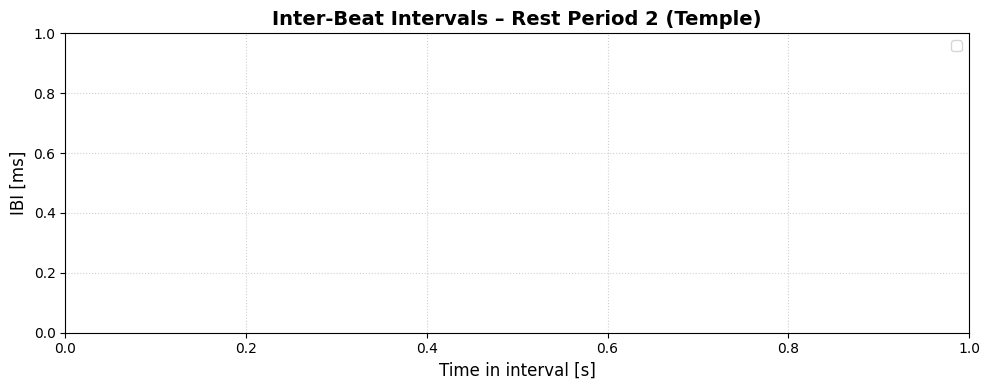

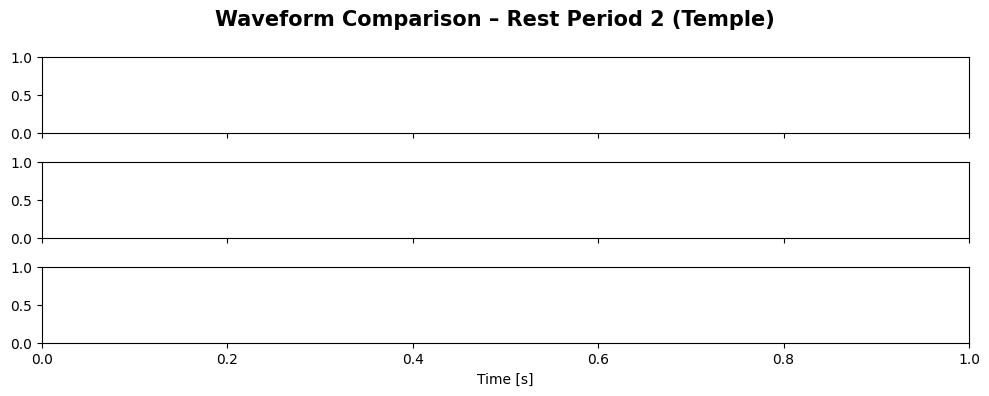

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


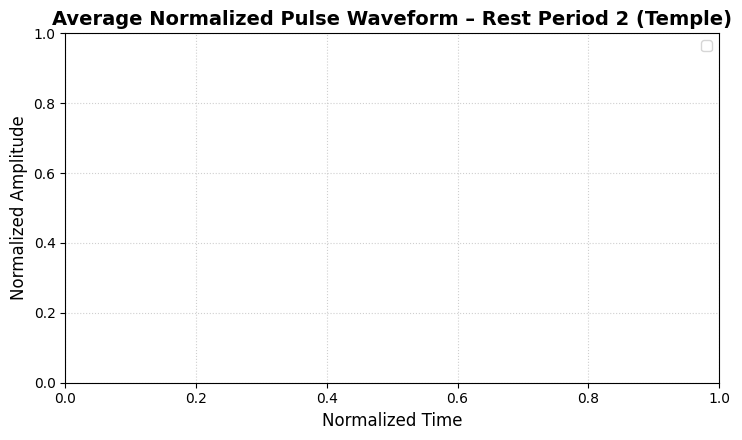

'for multiplier, segment_name in enumerate(segment_names):\n\n    interval_start = t_mmwave[0] + base_offset_s + step_s * multiplier\n    interval_end = interval_start + interval_duration_s\n\n    snippet_start = interval_start\n    snippet_duration = interval_end - interval_start\n\n    segment_folder = output_root / segment_name\n    segment_folder.mkdir(parents=True, exist_ok=True)\n\n    results_interval = {\n        "finger": crop_result_to_interval(results["finger"], interval_start, interval_end),\n        "brachial": crop_result_to_interval(results["brachial"], interval_start, interval_end),\n        "mmwave": crop_result_to_interval(results["mmwave"], interval_start, interval_end),\n    }\n\n    print(f"Saving {recording_name}/{segment_name}: "\n          f"{interval_start:.1f}s to {interval_end:.1f}s")\n\n    # 1) IBI plot\n    save_plot_function(\n        plot_ibi_interval,\n        segment_folder / "ibi.pdf",\n        results_interval,\n        title=f"Inter-Beat Intervals -

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
recording_name = "wrist"      # change to "temple" for temple measurement
output_root = Path(recording_name)


LOCATION_KEY = "temple"     # or "wrist"

os.makedirs(LOCATION_KEY, exist_ok=True)

base_offset_s = 25
step_s = 60
interval_duration_s = 20

segment_names = [
    "rest1",
    "hand1",
    "rest2",
    "hand2",
    "rest3",
    "hand3",
    "rest4",
    "cold1",
    "rest5",
    "cold2",
    "rest6",
    "valsal1",
    "rest7",
    "valsal2",
    "rest8",
    "stand1",
    "rest9",
    "stand2",
    "rest10",
]

output_root.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Helper: save plot functions that already call plt.show()
# ------------------------------------------------------------
def save_plot_function(plot_func, save_path, *args, **kwargs):
    """
    Calls a plotting function, prevents plt.show() from displaying,
    saves the current figure, and closes it.
    """

    old_show = plt.show
    plt.show = lambda *a, **k: None

    try:
        plot_func(*args, **kwargs)

        fig = plt.gcf()
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

    finally:
        plt.show = old_show

interval_start = t_mmwave[0] + 25 + 60 *0
interval_end   = t_mmwave[0] + 20

snippet_start  = interval_start + 5

make_interval_plots(
    results=results,
    interval_start=interval_start,
    interval_end=interval_end,
    interval_key="rest2",
    location_key="temple",
    snippet_start_s=snippet_start,
    snippet_duration_s=30.0,
    maneuver_mode=False,
    output_prefix="temple_rest2"
)


# ------------------------------------------------------------
# Loop over all maneuver intervals
# ------------------------------------------------------------
'''for multiplier, segment_name in enumerate(segment_names):

    interval_start = t_mmwave[0] + base_offset_s + step_s * multiplier
    interval_end = interval_start + interval_duration_s

    snippet_start = interval_start
    snippet_duration = interval_end - interval_start

    segment_folder = output_root / segment_name
    segment_folder.mkdir(parents=True, exist_ok=True)

    results_interval = {
        "finger": crop_result_to_interval(results["finger"], interval_start, interval_end),
        "brachial": crop_result_to_interval(results["brachial"], interval_start, interval_end),
        "mmwave": crop_result_to_interval(results["mmwave"], interval_start, interval_end),
    }

    print(f"Saving {recording_name}/{segment_name}: "
          f"{interval_start:.1f}s to {interval_end:.1f}s")

    # 1) IBI plot
    save_plot_function(
        plot_ibi_interval,
        segment_folder / "ibi.pdf",
        results_interval,
        title=f"Inter-Beat Intervals - {segment_name}"
    )

    # 2) Waveform snippet
    save_plot_function(
        plot_waveform_snippet,
        segment_folder / "waveform.pdf",
        results_interval,
        snippet_start_s=snippet_start,
        duration_s=snippet_duration,
        title=f"Waveform comparison - {segment_name}"
    )

    # 3) Average waveform
    save_plot_function(
        plot_average_waveforms,
        segment_folder / "average_waveform.pdf",
        results_interval,
        title=f"Average normalized pulse waveform - {segment_name}"
    )'''

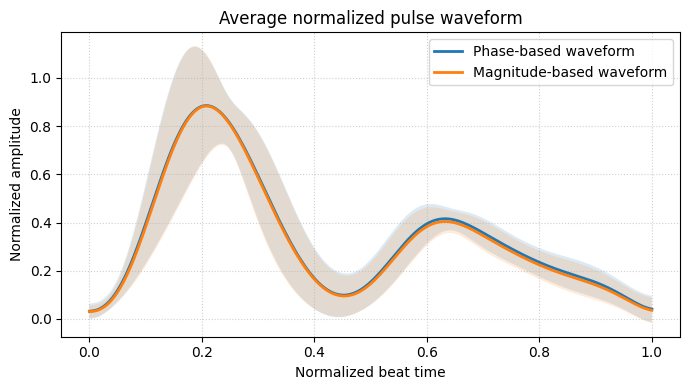

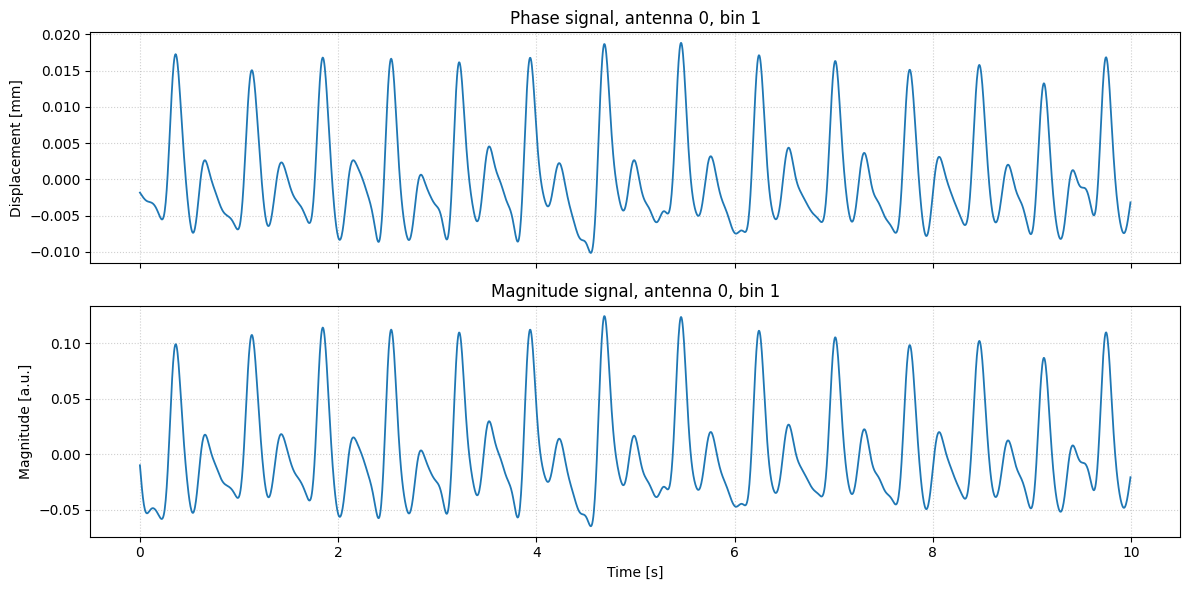

In [ ]:
result_phase = results[1]
result_mag = results_mag[1]

x_norm = np.linspace(0, 1, POINTS_PER_BEAT)

plt.figure(figsize=(7, 4))

plt.plot(
    x_norm,
    result_phase["average_pulse"],
    linewidth=2,
    label="Phase-based waveform"
)

plt.plot(
    x_norm,
    result_mag["average_pulse"],
    linewidth=2,
    label="Magnitude-based waveform"
)

plt.fill_between(
    x_norm,
    result_phase["average_pulse"] - result_phase["std_pulse"],
    result_phase["average_pulse"] + result_phase["std_pulse"],
    alpha=0.15
)

plt.fill_between(
    x_norm,
    result_mag["average_pulse"] - result_mag["std_pulse"],
    result_mag["average_pulse"] + result_mag["std_pulse"],
    alpha=0.15
)

plt.title("Average normalized pulse waveform")
plt.xlabel("Normalized beat time")
plt.ylabel("Normalized amplitude")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



t_phase = result_phase["time_axis"]
phase_signal = result_phase["vital_signal"]

t_mag = result_mag["time_axis"]
mag_signal = result_mag["vital_signal"]

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(t_phase, phase_signal, linewidth=1.3)
axs[0].set_title(
    f"Phase signal, antenna {result_phase['best_ant']}, bin {result_phase['best_bin']}"
)
axs[0].set_ylabel("Displacement [mm]")
axs[0].grid(True, linestyle=":", alpha=0.6)

axs[1].plot(t_mag, mag_signal, linewidth=1.3)
axs[1].set_title(
    f"Magnitude signal, antenna {result_mag['best_ant']}, bin {result_mag['best_bin']}"
)
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Magnitude [a.u.]")
axs[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

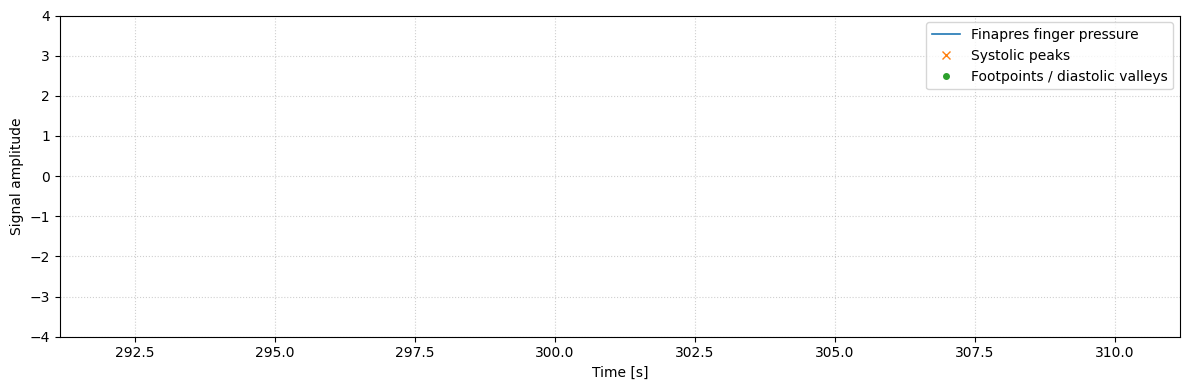

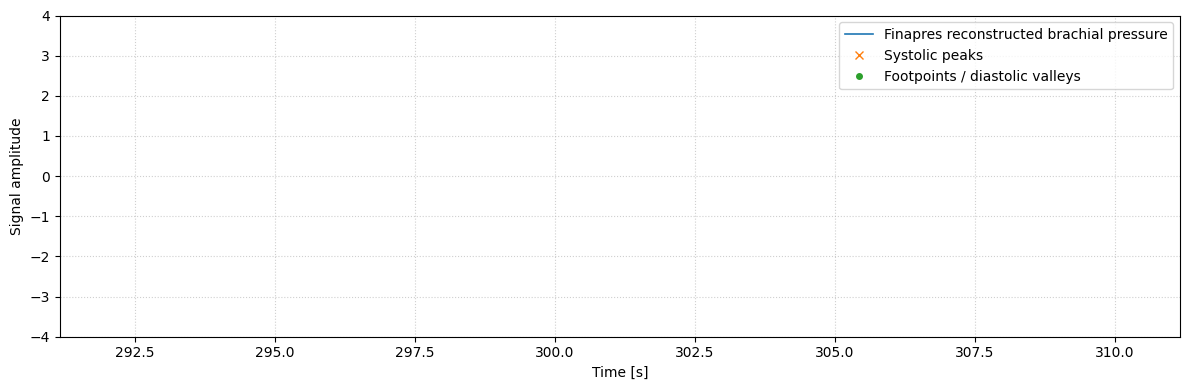

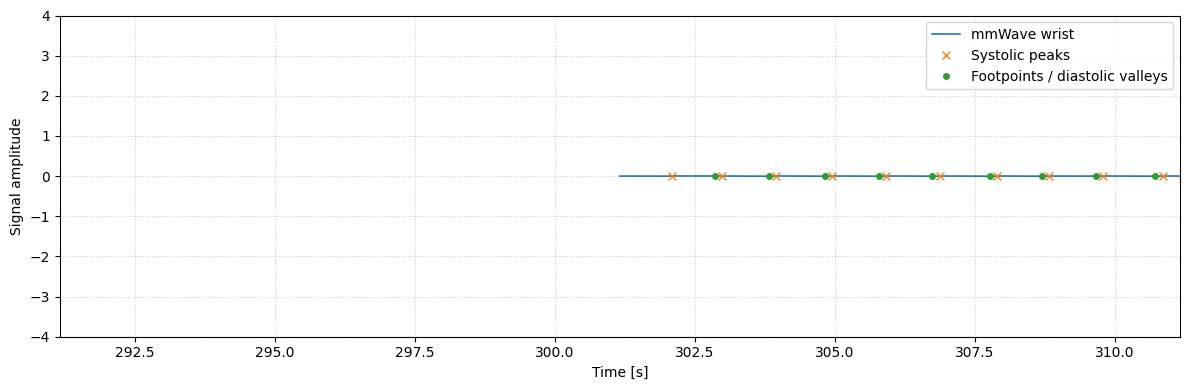

In [319]:
# ============================================================
# QUICK CHECK PLOTS
# ============================================================

def plot_detection_result(result, xlim=None):
    t = result["t"]
    y = result["signal"]
    peaks = result["systolic_peaks"]
    valleys = result["diastolic_valleys"]

    plt.figure(figsize=(12, 4))

    plt.plot(
        t,
        y,
        linewidth=1.2,
        label=result["name"]
    )

    plt.plot(
        t[peaks],
        y[peaks],
        "x",
        label="Systolic peaks"
    )

    plt.plot(
        t[valleys],
        y[valleys],
        "o",
        markersize=4,
        label="Footpoints / diastolic valleys"
    )

    if xlim is not None:
        plt.xlim(xlim)
    plt.ylim((-4,4))
    plt.xlabel("Time [s]")
    plt.ylabel("Signal amplitude")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example: show 20 seconds at the beginning of mmWave overlap
plot_start = t_mmwave[0] -10
plot_end = plot_start + 20

plot_detection_result(finger_result, xlim=(plot_start, plot_end))
plot_detection_result(brachial_result, xlim=(plot_start, plot_end))
plot_detection_result(mmwave_result, xlim=(plot_start, plot_end))

In [342]:

# ============================================================
# INTERACTIVE PLOTLY VIEWER
# ============================================================

fig = make_subplots(
    rows=1,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=[
        "Pulse waveform comparison",

    ]
)

# Row 1: Pulse signals
fig.add_trace(
    go.Scattergl(
        x=t_finger_p,
        y=finger_p,
        mode="lines",
        name="Finapres finger pressure",
        line=dict(width=1)
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scattergl(
        x=t_brachial_p,
        y=brachial_p,
        mode="lines",
        name="Finapres reconstructed brachial pressure",
        line=dict(width=1)
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scattergl(
        x=t_mmwave_p,
        y=mmwave_p,
        mode="lines",
        name=f"mmWave radar, bin {mmwave['best_bin']}",
        line=dict(width=1)
    ),
    row=1,
    col=1
)

# Row 2: Marker
'''
fig.add_trace(
    go.Scattergl(
        x=t_marker_p,
        y=marker_p,
        mode="lines",
        name="Finapres marker",
        line=dict(width=1)
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Scattergl(
        x=t_mmwave_sync_p,
        y=mmwave_sync_p,
        mode="lines",
        name="mmWave sync",
        line=dict(width=1)
    ),
    row=3,
    col=1
)
'''
fig.update_yaxes(title_text="normalized", row=1, col=1)
#fig.update_yaxes(title_text="normalized", row=2, col=1)
#fig.update_yaxes(title_text="normalized", row=3, col=1)

fig.update_xaxes(
    title_text="Time [s]",
    row=3,
    col=1,
    rangeslider=dict(visible=True)
)

fig.update_layout(
    title=(
        f"Finapres / NovaScope vs mmWave comparison "
        f"| mmWave shift = {mmwave_time_shift_s:.2f} s "
        f"| selected bin = {mmwave['best_bin']} "
    ),
    height=315,
    width=1400,
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=0,
        xanchor="left",
        x=0
    )
)

# ============================================================
# ADD PROTOCOL MARKERS TO PLOT
# ============================================================

# Colors are optional; remove fillcolor/line_color if you want default styling.
event_colors = {
    "Rest": "rgba(180, 180, 180, 0.12)",
    "Hand Grip": "rgba(255, 165, 0, 0.18)",
    "Cold Pressor": "rgba(0, 120, 255, 0.16)",
    "Valsalva": "rgba(180, 0, 180, 0.16)",
    "Stand Up": "rgba(0, 180, 80, 0.16)",
}

for interval in protocol_intervals:
    label = interval["label"]

    # Convert mmWave-relative protocol time to global Finapres time
    x0 = interval["start_mmwave"] * time_scale + time_offset_s
    x1 = interval["end_mmwave"] * time_scale + time_offset_s

    # Add shaded region over all subplot rows
    fig.add_vrect(
        x0=x0,
        x1=x1,
        fillcolor=event_colors.get(label, "rgba(150, 150, 150, 0.12)"),
        opacity=1.0,
        layer="below",
        line_width=0,
        annotation_text=label if label != "Rest" else "",
        annotation_position="top left",
    )

    # Optional: add vertical boundary lines
    fig.add_vline(
        x=x0,
        line_width=0.8,
        line_dash="dot",
        line_color="rgba(80, 80, 80, 0.5)"
    )

fig.write_html("finapres_mmwave_comparison.html", auto_open=True)


In [122]:
import zipfile

file_path = "mmWave/2026-05-22_16.38.27_1.nsc"

with zipfile.ZipFile(file_path, "r") as z:
    for name in z.namelist():
        print(name)

2026-05-22_16.38.27_1/
2026-05-22_16.38.27_1/Algo_X_Advanced_Hemodynamics.nsd
2026-05-22_16.38.27_1/Algo_X_ANSBasic_HRV-BC.nsd
2026-05-22_16.38.27_1/Algo_X_ANSBasic_HRV.nsd
2026-05-22_16.38.27_1/Algo_X_AvgCO.nsd
2026-05-22_16.38.27_1/Algo_X_BRS.nsd
2026-05-22_16.38.27_1/Algo_X_CalcGenerate.nsd
2026-05-22_16.38.27_1/Algo_X_CalcHeartRate.nsd
2026-05-22_16.38.27_1/Algo_X_CalcHeartRate_src.nsd
2026-05-22_16.38.27_1/Algo_X_fiApHcu.nsd
2026-05-22_16.38.27_1/Algo_X_PressureWave_Derived1.nsd
2026-05-22_16.38.27_1/Algo_X_PressureWave_Derived2.nsd
2026-05-22_16.38.27_1/Algo_X_PressureWave_Detect.nsd
2026-05-22_16.38.27_1/Algo_X_PressureWave_ReAO.nsd
2026-05-22_16.38.27_1/Algo_X_PressureWave_ReBr.nsd
2026-05-22_16.38.27_1/Algo_X_PressureWave_ReFlow.nsd
2026-05-22_16.38.27_1/Algo_Y_AvgCO_AverageCO.nsd
2026-05-22_16.38.27_1/Algo_Y_Beat Classification_BeatClassification.nsd
2026-05-22_16.38.27_1/Algo_Y_Block_BlockWave.nsd
2026-05-22_16.38.27_1/Algo_Y_BRS_BRS.nsd
2026-05-22_16.38.27_1/Algo_Y_BSA_BSA.

In [202]:
import numpy as np
data = np.load('radar_invivo_fps_sweep_2026-05-22_17-28/fps_200_order_04_rep_1_data.npy')

print(np.shape(data))
print(data.dtype)
print(data.min(), data.max())
print(np.percentile(data, [0, 1, 50, 99, 100]))
print(np.shape(data))
print(data)

(2000, 1, 32, 8)
uint16
0 4094
[   0.    0.    0. 4094. 4094.]
(2000, 1, 32, 8)
[[[[   0    0    0 ... 1810 4094 4094]
   [   0    0    0 ... 1404 4094 4094]
   [   0    0    0 ... 1404 4094 4094]
   ...
   [   0    0    0 ... 1404 4094 4094]
   [   0    0    0 ... 1404 4094 4094]
   [   0    0    0 ... 1400 4094 4094]]]


 [[[   0    0    0 ... 1805 4094 4094]
   [   0    0    0 ... 1402 4094 4094]
   [   0    0    0 ... 1402 4094 4094]
   ...
   [   0    0    0 ... 1407 4094 4094]
   [   0    0    0 ... 1404 4094 4094]
   [   0    0    0 ... 1412 4094 4094]]]


 [[[   0    0    0 ... 1807 4094 4094]
   [   0    0    0 ... 1410 4094 4094]
   [   0    0    0 ... 1404 4094 4094]
   ...
   [   0    0    0 ... 1412 4094 4094]
   [   0    0    0 ... 1410 4094 4094]
   [   0    0    0 ... 1404 4094 4094]]]


 ...


 [[[   0    0    0 ... 1918 4094 4094]
   [   0    0    0 ... 1518 4094 4094]
   [   0    0    0 ... 1512 4094 4094]
   ...
   [   0    0    0 ... 1520 4094 4094]
   [   0    0  

In [10]:
data = np.load('radar_session_2026-03-05_22-38/200fps_75chrep_64ch_16sa.npy')
print(np.shape(data))

FileNotFoundError: [Errno 2] No such file or directory: 'radar_session_2026-03-05_22-38/200fps_75chrep_64ch_16sa.npy'

In [8]:
from scipy.signal import butter, filtfilt, welch
import numpy as np

def calculate_robust_snr(filtered_signal, fps):
    # 1. Spektrum berechnen
    freqs, psd = welch(filtered_signal, fs=fps, nperseg=min(len(filtered_signal), int(fps * 4)))
    
    # 2. Herz-Band definieren
    mask = (freqs >= 0.8) & (freqs <= 4.0)
    f_band = freqs[mask]
    p_band = psd[mask]
    
    if len(p_band) < 3: return 0.0

    # 3. Signal: Wir nehmen den höchsten Peak
    #p_signal = np.max(p_band)
    

    # Statt p_signal = np.max(p_band)
    # Nehmen wir die Summe der Energie um den Puls-Peak herum
    peak_idx = np.argmax(p_band)
    window = 3 # Wir nehmen den Peak und 3 Bins links/rechts
    p_signal = np.sum(p_band[max(0, peak_idx-window) : min(len(p_band), peak_idx+window+1)])


    # 4. Rauschen: Wir nehmen den MEDIAN oder MITTELWERT des restlichen Rauschens im Band
    # Entferne den Peak-Bereich für die Rauschmessung
    noise_part = np.delete(p_band, [max(0, peak_idx-1), peak_idx, min(len(p_band)-1, peak_idx+1)])
    
    p_noise_avg = np.mean(noise_part) if len(noise_part) > 0 else 1e-10
    
    # 5. SNR Berechnung (Peak-to-Average)
    snr_db = 10 * np.log10(p_signal / p_noise_avg)
    return snr_db

In [9]:
def calculate_snr(signal, fps, heart_rate_band=(0.8, 2.5), peak_window_hz=0.1):
    """
    Calculate SNR of a heartbeat signal in the frequency domain.
    
    Parameters:
        signal      : 1D time-series (filtered phase or magnitude)
        fps         : frames per second (sampling rate)
        heart_rate_band : (low, high) Hz for valid heart rate (0.8–2.5 Hz = 48–150 BPM)
        peak_window_hz  : ±Hz around the dominant peak considered as "signal"
    
    Returns:
        snr_db      : SNR in dB
        hr_hz       : detected heart rate in Hz
        freqs       : frequency array
        psd         : power spectral density
    """
    n = len(signal)
    
    # FFT → Power Spectral Density
    fft_vals = np.fft.rfft(signal * np.hanning(n))
    psd = (np.abs(fft_vals) ** 2) / n          # power per bin
    freqs = np.fft.rfftfreq(n, d=1.0 / fps)
    
    # Restrict to heart rate band
    band_mask = (freqs >= heart_rate_band[0]) & (freqs <= heart_rate_band[1])
    band_freqs = freqs[band_mask]
    band_psd   = psd[band_mask]
    
    if band_psd.size == 0:
        raise ValueError("No frequency bins inside heart_rate_band — check fps and band limits.")
    
    # Find dominant peak inside band
    peak_idx_local = np.argmax(band_psd)
    hr_hz = band_freqs[peak_idx_local]
    
    # Signal power = bins within ±peak_window_hz of the dominant peak
    signal_mask = np.abs(band_freqs - hr_hz) <= peak_window_hz
    noise_mask  = ~signal_mask
    
    p_signal = np.sum(band_psd[signal_mask])
    p_noise  = np.sum(band_psd[noise_mask])
    
    if p_noise == 0:
        snr_db = np.inf
    else:
        snr_db = 10 * np.log10(p_signal / p_noise)
    
    return snr_db, hr_hz, freqs, psd

In [9]:
import os
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt



input_folder = 'radar_session_2026-03-06_17-39_seb'

lowcut = 0.5
highcut = 6.0
target_bin_index = 1
time = 10

file_path1 = os.path.join(input_folder, '01_200fps_35chrep_128ch_32sa.npy')
file_path = os.path.join(input_folder, '18_200fps_35chrep_128ch_32sa.npy')
file_path =  os.path.join('radar_session_2026-05-15_16-51', 'data.npy')
file_path1 = os.path.join('radar_session_2026-05-15_16-52', 'data.npy')
data1 = np.load(file_path1)
data2 = np.load(file_path)


num_frames, num_ant, num_chirps, num_samples = data.shape
fps = num_frames/time 
    
    # 2. Algorithmus (wie in deinem funktionierenden Code)
mean_removed1 = data1 - np.mean(data1, axis=-1, keepdims=True)
window = np.hanning(num_samples)
windowed_data1 = mean_removed1 * window
range_fft1 = np.fft.rfft(windowed_data1, axis=-1)


mean_removed2 = data2 - np.mean(data2, axis=-1, keepdims=True)
window = np.hanning(num_samples)
windowed_data2 = mean_removed2 * window
range_fft2 = np.fft.rfft(windowed_data2, axis=-1)

mean_energy = np.mean(np.abs(range_fft1[:, 0, 0, 1:6]), axis=0)
target_bin_index = np.argmax(mean_energy) + 1

print("target_bin_index:", target_bin_index)
    
    # Phase extrahieren (erste Antenne, Mittelwert über Chirps)

complex_signal1 = np.mean(range_fft1[:, 0, :, target_bin_index], axis=1)
complex_signal2 = np.mean(range_fft2[:, 0, :, target_bin_index], axis=1)

# 2. Jetzt erst den Winkel ziehen und entrollen
unwrapped_phase1 = np.unwrap(np.angle(complex_signal1))
unwrapped_phase2 = np.unwrap(np.angle(complex_signal2))

"""
phase_data1 = np.angle(range_fft1[:, 0, :, :]) 
phase_time_series1 = np.mean(phase_data1, axis=1)
unwrapped_phase1 = np.unwrap(phase_time_series1, axis=0)

phase_data2 = np.angle(range_fft2[:, 0, :, :]) 
phase_time_series2 = np.mean(phase_data2, axis=1)
unwrapped_phase2 = np.unwrap(phase_time_series2, axis=0)
"""

RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77
c = 3e8                                     # speed of light m/s
wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
wavelength_mm = wavelength_m * 1000         # in mm

# Convert unwrapped phase (radians) → displacement (mm)
displacement_mm1 = (wavelength_mm * unwrapped_phase1) / (4 * np.pi)
displacement_mm2 = (wavelength_mm * unwrapped_phase2) / (4 * np.pi)
        





    # Filter
nyquist = 0.5 * fps
b, a = butter(N=3, Wn=[lowcut/nyquist, highcut/nyquist], btype='band')
filtered_phase1 = filtfilt(b, a, displacement_mm1)
filtered_phase2 = filtfilt(b, a, displacement_mm2)



    # Signal für Bin 1 (oder target_bin_index)
vital_sign_signal1 = filtered_phase1
vital_sign_signal2 = filtered_phase2

snr_wert = calculate_robust_snr(vital_sign_signal1 , fps)
print(f"SNR des Szenarios: {snr_wert:.2f} dB")

unfilterd = unwrapped_phase1

    # Polarität anpassen
if np.mean(vital_sign_signal1**3) < 0:
    vital_sign_signal1 *= -1


if np.mean(vital_sign_signal2**3) < 0:
    vital_sign_signal2 *= -1

    # 3. Plotting direkt im Notebook
time_axis = np.arange(num_frames) / fps
    
plt.figure(figsize=(14, 4))
plt.plot(time_axis, vital_sign_signal1, color="#0c87df", linewidth=1.5, label='Heartbeat-Ref_1')
    
plt.plot(time_axis, vital_sign_signal2, color="#b41f1f", linewidth=1.5, label='Heartbeat-Ref_3')
    

    # Peaks markieren
    #peaks, _ = find_peaks(vital_sign_signal, distance=int(fps/2))
    #plt.plot(time_axis[peaks], vital_sign_signal[peaks], "rx", label=f'Beats ({len(peaks)})')

    # Styling
plt.title(f"Nima first and last ref. recordings, shape: {data.shape}", fontsize=12, fontweight='bold')
plt.xlabel("Time [sec]")
plt.ylabel("Displacement [mm]")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
    
plt.show() # In JPTNB zwingend, um nach jedem Loop das Bild zu rendern

FileNotFoundError: [Errno 2] No such file or directory: 'radar_session_2026-05-15_16-52\\data.npy'


Processing magnitude: radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_data.npy
Raw shape: (240000, 1, 32, 8)
Estimated fps: 200.0
Selected antenna: 0
Selected range bin: 1
Peak-to-peak magnitude: 186.22529502660092 a.u.
Detected systolic peaks: 1348
Detected diastolic valleys: 1347


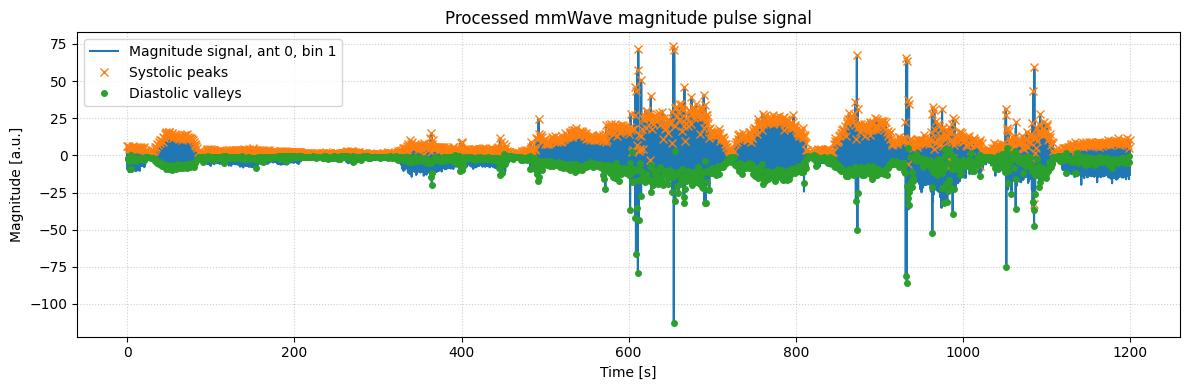

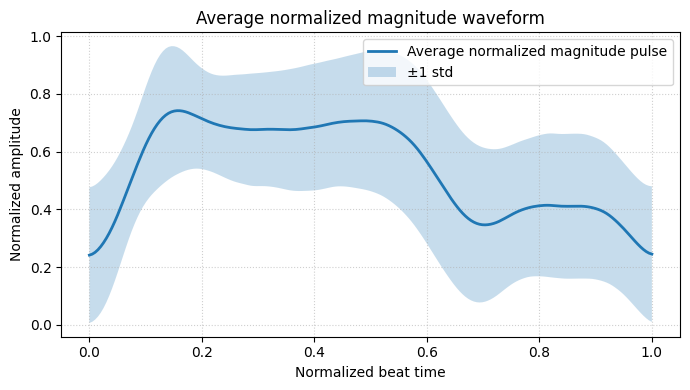

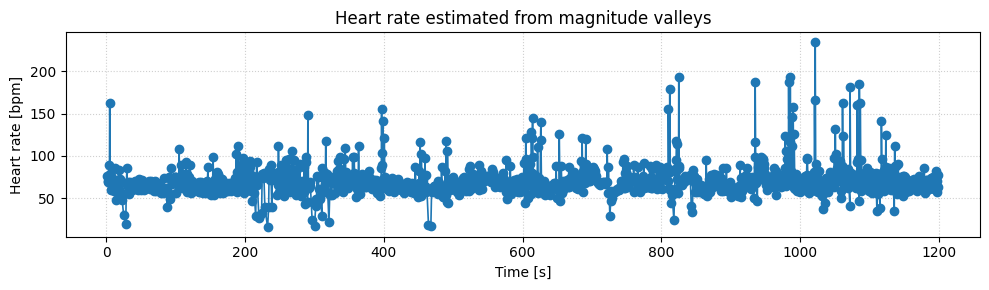

In [247]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d


# ============================================================
# CONFIG
# ============================================================

files = [
    #"radar_invivo_fps_sweep_2026-05-22_17-28/fps_200_order_04_rep_3_data.npy",
    #"radar_invivo_fps_sweep_2026-05-22_17-51/fps_200_order_04_rep_3_data.npy",
    #"radar_session_2026-03-06_17-39_seb/01_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-39_seb/09_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-39_seb/18_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_16-57_nima/01_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_16-57_nima/09_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_16-57_nima/18_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-15_ben/01_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-15_ben/09_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-15_ben/18_200fps_35chrep_128ch_32sa.npy",
    "radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_data.npy",
]

RECORDING_TIME_S = 20*60

LOWCUT_HZ = 0.5
HIGHCUT_HZ = 8.0
FILTER_ORDER = 4

BIN_SEARCH_START = 1
BIN_SEARCH_END = 4

POINTS_PER_BEAT = 200
MIN_HEART_PERIOD_S = 0.35
PROMINENCE_FACTOR = 0.20


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def bandpass_filter(x, fs, lowcut, highcut, order=4, axis=0):
    nyquist = 0.5 * fs

    if highcut >= nyquist:
        highcut = 0.95 * nyquist

    b, a = butter(
        order,
        [lowcut / nyquist, highcut / nyquist],
        btype="band"
    )

    return filtfilt(b, a, x, axis=axis)


def detect_systolic_and_diastolic(signal, fs):
    min_distance = max(1, int(MIN_HEART_PERIOD_S * fs))
    prominence = max(1e-12, PROMINENCE_FACTOR * np.nanstd(signal))

    systolic_peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )

    diastolic_valleys, _ = find_peaks(
        -signal,
        distance=min_distance,
        prominence=prominence
    )

    return systolic_peaks, diastolic_valleys

def detect_peaks_and_footpoints(signal, fs):
    """
    Detect systolic peaks and one foot/diastolic valley before each peak.
    Better for pulse waveform segmentation.
    """

    min_peak_distance = max(1, int(0.45 * fs))
    prominence = max(1e-12, 0.25 * np.nanstd(signal))

    systolic_peaks, _ = find_peaks(
        signal,
        distance=min_peak_distance,
        prominence=prominence
    )

    if len(systolic_peaks) < 2:
        return systolic_peaks, np.array([], dtype=int)

    footpoints = []

    for i in range(1, len(systolic_peaks)):
        prev_peak = systolic_peaks[i - 1]
        curr_peak = systolic_peaks[i]

        rr = curr_peak - prev_peak

        # Search before current systolic peak
        search_start = curr_peak - int(0.65 * rr)
        search_end = curr_peak - int(0.08 * rr)

        search_start = max(0, search_start)
        search_end = max(search_start + 1, search_end)

        segment = signal[search_start:search_end]

        if len(segment) == 0:
            continue

        foot_idx = search_start + np.nanargmin(segment)
        footpoints.append(foot_idx)

    return systolic_peaks, np.array(footpoints, dtype=int)

def correct_polarity(signal, fs):
    min_distance = max(1, int(MIN_HEART_PERIOD_S * fs))
    prominence = max(1e-12, PROMINENCE_FACTOR * np.nanstd(signal))

    pos_peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )

    neg_peaks, _ = find_peaks(
        -signal,
        distance=min_distance,
        prominence=prominence
    )

    if len(pos_peaks) == 0 or len(neg_peaks) == 0:
        if np.nanmean(signal ** 3) < 0:
            return -signal
        return signal

    pos_amp = np.nanmean(signal[pos_peaks])
    neg_amp = np.nanmean(-signal[neg_peaks])

    if neg_amp > pos_amp:
        signal = -signal

    return signal


def extract_normalized_beats(signal, valley_indices, points_per_beat=200):
    beats = []

    valley_indices = np.sort(valley_indices)

    for i in range(len(valley_indices) - 1):
        start = valley_indices[i]
        end = valley_indices[i + 1]

        beat = signal[start:end]

        if len(beat) < 10:
            continue

        beat = beat - np.nanmin(beat)
        beat = beat / (np.nanmax(beat) + 1e-12)

        x_old = np.linspace(0, 1, len(beat))
        x_new = np.linspace(0, 1, points_per_beat)

        beat_interp = interp1d(x_old, beat, kind="linear")(x_new)
        beats.append(beat_interp)

    return np.array(beats)


def process_mmwave_magnitude_file(
    file_path,
    recording_time_s,
    bin_search_start=1,
    bin_search_end=None,
):
    """
    Magnitude-based mmWave pulse waveform processing.

    Expected raw data shape:
    frames x antennas x chirps x samples
    """

    data = np.load(file_path)

    num_frames, num_antennas, num_chirps, num_samples = data.shape
    fps = num_frames / recording_time_s
    time_axis = np.arange(num_frames) / fps

    print("\nProcessing magnitude:", file_path)
    print("Raw shape:", data.shape)
    print("Estimated fps:", fps)

    # ------------------------------------------------------------
    # 1. DC removal across samples per chirp
    # ------------------------------------------------------------
    mean_removed = data - np.mean(data, axis=-1, keepdims=True)

    # ------------------------------------------------------------
    # 2. Windowing across ADC samples
    # ------------------------------------------------------------
    window = np.hanning(num_samples)
    windowed_data = mean_removed * window

    # ------------------------------------------------------------
    # 3. Range FFT along sample dimension
    # Shape: frames x antennas x chirps x range_bins
    # ------------------------------------------------------------
    range_fft = np.fft.rfft(windowed_data, axis=-1)

    # ------------------------------------------------------------
    # 4. Magnitude extraction and averaging over chirps
    # Shape: frames x antennas x range_bins
    # ------------------------------------------------------------
    magnitude = np.abs(range_fft)
    magnitude_mean = np.mean(magnitude, axis=2)

    # ------------------------------------------------------------
    # 5. Bandpass filtering, 4th-order Butterworth 0.5–8 Hz
    # ------------------------------------------------------------
    filtered_magnitude = bandpass_filter(
        magnitude_mean,
        fps,
        LOWCUT_HZ,
        HIGHCUT_HZ,
        order=FILTER_ORDER,
        axis=0
    )

    # ------------------------------------------------------------
    # 6. Automatic antenna/range-bin selection
    # Use highest peak-to-peak amplitude of filtered magnitude signal
    # ------------------------------------------------------------
    num_bins = filtered_magnitude.shape[2]

    if bin_search_end is None:
        bin_search_end = num_bins

    bin_search_end = min(bin_search_end, num_bins)

    search_data = filtered_magnitude[:, :, bin_search_start:bin_search_end]

    peak_to_peak = np.nanmax(search_data, axis=0) - np.nanmin(search_data, axis=0)

    best_ant_rel, best_bin_rel = np.unravel_index(
        np.nanargmax(peak_to_peak),
        peak_to_peak.shape
    )

    best_ant = best_ant_rel
    best_bin = best_bin_rel + bin_search_start

    vital_signal_mag = filtered_magnitude[:, best_ant, best_bin]

    print("Selected antenna:", best_ant)
    print("Selected range bin:", best_bin)
    print("Peak-to-peak magnitude:", peak_to_peak[best_ant_rel, best_bin_rel], "a.u.")

    # ------------------------------------------------------------
    # 7. Polarity correction
    # Magnitude can still appear inverted after filtering.
    # ------------------------------------------------------------
    vital_signal_mag = correct_polarity(vital_signal_mag, fps)

    # ------------------------------------------------------------
    # 8. Peak detection
    # ------------------------------------------------------------
    systolic_peaks, diastolic_valleys = detect_peaks_and_footpoints(
        vital_signal_mag,
        fps
    )

    print("Detected systolic peaks:", len(systolic_peaks))
    print("Detected diastolic valleys:", len(diastolic_valleys))

    # ------------------------------------------------------------
    # 9. IBI / HR from diastolic valleys
    # ------------------------------------------------------------
    if len(diastolic_valleys) > 1:
        ibi_s = np.diff(time_axis[diastolic_valleys])
        hr_bpm = 60.0 / ibi_s
    else:
        ibi_s = np.array([])
        hr_bpm = np.array([])

    # ------------------------------------------------------------
    # 10. Beat morphology extraction
    # ------------------------------------------------------------
    beats = extract_normalized_beats(
        vital_signal_mag,
        diastolic_valleys,
        points_per_beat=POINTS_PER_BEAT
    )

    if len(beats) > 0:
        average_pulse = np.nanmean(beats, axis=0)
        std_pulse = np.nanstd(beats, axis=0)
    else:
        average_pulse = None
        std_pulse = None

    return {
        "file_path": file_path,
        "data_shape": data.shape,
        "fps": fps,
        "time_axis": time_axis,
        "filtered_all_bins": filtered_magnitude,
        "vital_signal": vital_signal_mag,
        "best_ant": best_ant,
        "best_bin": best_bin,
        "systolic_peaks": systolic_peaks,
        "diastolic_valleys": diastolic_valleys,
        "ibi_s": ibi_s,
        "hr_bpm": hr_bpm,
        "beats": beats,
        "average_pulse": average_pulse,
        "std_pulse": std_pulse,
    }


# ============================================================
# MAIN LOOP
# ============================================================

results_mag = []

for file_path in files:
    result = process_mmwave_magnitude_file(
        file_path=file_path,
        recording_time_s=RECORDING_TIME_S,
        bin_search_start=BIN_SEARCH_START,
        bin_search_end=BIN_SEARCH_END,
    )

    results_mag.append(result)

    t = result["time_axis"]
    signal = result["vital_signal"]
    systolic_peaks = result["systolic_peaks"]
    diastolic_valleys = result["diastolic_valleys"]

    # ------------------------------------------------------------
    # Plot processed magnitude pulse signal with detected peaks
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 4))

    plt.plot(
        t,
        signal,
        linewidth=1.5,
        label=f"Magnitude signal, ant {result['best_ant']}, bin {result['best_bin']}"
    )

    plt.plot(
        t[systolic_peaks],
        signal[systolic_peaks],
        "x",
        label="Systolic peaks"
    )

    plt.plot(
        t[diastolic_valleys],
        signal[diastolic_valleys],
        "o",
        markersize=4,
        label="Diastolic valleys"
    )

    plt.title("Processed mmWave magnitude pulse signal")
    plt.xlabel("Time [s]")
    plt.ylabel("Magnitude [a.u.]")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot average magnitude pulse morphology
    # ------------------------------------------------------------
    if result["average_pulse"] is not None:
        x_norm = np.linspace(0, 1, POINTS_PER_BEAT)

        plt.figure(figsize=(7, 4))

        plt.plot(
            x_norm,
            result["average_pulse"],
            linewidth=2,
            label="Average normalized magnitude pulse"
        )

        plt.fill_between(
            x_norm,
            result["average_pulse"] - result["std_pulse"],
            result["average_pulse"] + result["std_pulse"],
            alpha=0.25,
            label="±1 std"
        )

        plt.title("Average normalized magnitude waveform")
        plt.xlabel("Normalized beat time")
        plt.ylabel("Normalized amplitude")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # Optional HR plot
    # ------------------------------------------------------------
    if len(result["hr_bpm"]) > 0:
        ibi_time = t[diastolic_valleys[1:]]

        plt.figure(figsize=(10, 3))

        plt.plot(
            ibi_time,
            result["hr_bpm"],
            marker="o",
            linewidth=1.2
        )

        plt.title("Heart rate estimated from magnitude valleys")
        plt.xlabel("Time [s]")
        plt.ylabel("Heart rate [bpm]")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        plt.show()


Processing: radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_data.npy
Raw shape: (240000, 1, 32, 8)
Estimated fps: 200.0
Selected antenna: 0
Selected range bin: 1
Peak-to-peak amplitude: 0.2619090611957153 mm
Detected systolic peaks: 1385
Detected diastolic valleys: 1384


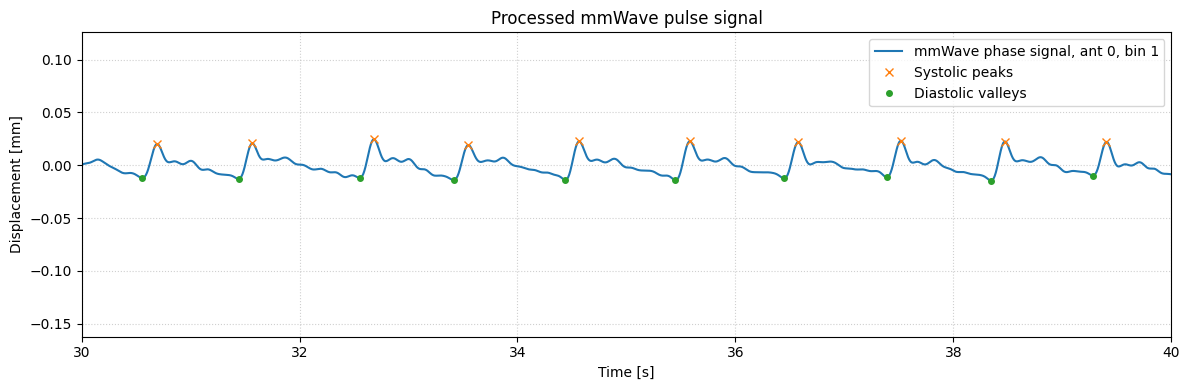

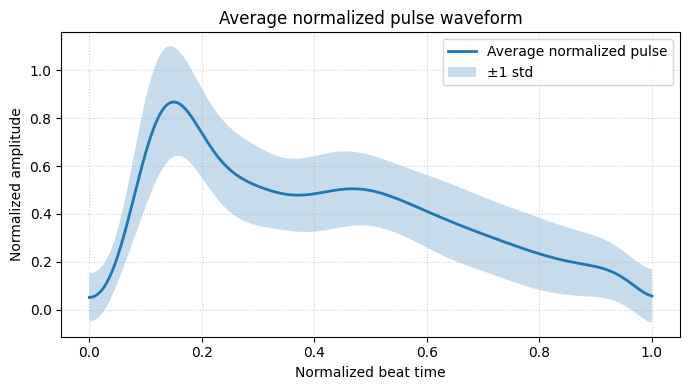

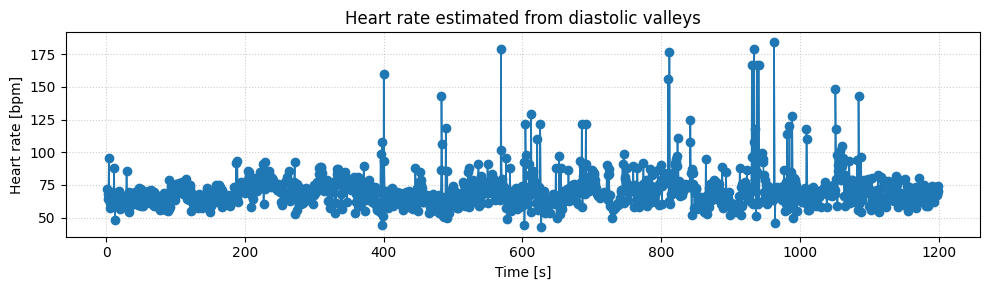

In [248]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from scipy.interpolate import interp1d


# ============================================================
# CONFIG
# ============================================================

files = [
    #"radar_invivo_fps_sweep_2026-05-22_17-28/fps_200_order_04_rep_3_data.npy",
    #"radar_invivo_fps_sweep_2026-05-22_17-51/fps_200_order_04_rep_3_data.npy",
    #"radar_session_2026-03-06_17-39_seb/01_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-39_seb/09_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-39_seb/18_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_16-57_nima/01_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_16-57_nima/09_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_16-57_nima/18_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-15_ben/01_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-15_ben/09_200fps_35chrep_128ch_32sa.npy",
    #"radar_session_2026-03-06_17-15_ben/18_200fps_35chrep_128ch_32sa.npy",
    "radar_invivo_fps_sweep_2026-05-22_18-36/fps_200_order_01_rep_1_data.npy",
]

RECORDING_TIME_S = 60*20

RADAR_FREQ_GHZ = 60.75

LOWCUT_HZ = 0.5
HIGHCUT_HZ = 8.0
FILTER_ORDER = 4

# Bin selection
BIN_SEARCH_START = 1      # skip DC / very near bin
BIN_SEARCH_END = 3     # None = all available bins

# Beat segmentation
POINTS_PER_BEAT = 200

# Peak detection
MIN_HEART_PERIOD_S = 0.35   # 0.35 s = ~171 bpm max
PROMINENCE_FACTOR = 0.20


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def bandpass_filter(x, fs, lowcut, highcut, order=4, axis=0):
    nyquist = 0.5 * fs

    if highcut >= nyquist:
        highcut = 0.95 * nyquist

    b, a = butter(
        order,
        [lowcut / nyquist, highcut / nyquist],
        btype="band"
    )

    return filtfilt(b, a, x, axis=axis)


def phase_to_displacement_mm(unwrapped_phase, radar_freq_ghz):
    c = 3e8
    wavelength_m = c / (radar_freq_ghz * 1e9)
    wavelength_mm = wavelength_m * 1000.0

    displacement_mm = (wavelength_mm * unwrapped_phase) / (4 * np.pi)

    return displacement_mm


def detect_systolic_and_diastolic(signal, fs):
    min_distance = max(1, int(MIN_HEART_PERIOD_S * fs))
    prominence = max(1e-12, PROMINENCE_FACTOR * np.nanstd(signal))

    systolic_peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )

    diastolic_valleys, _ = find_peaks(
        -signal,
        distance=min_distance,
        prominence=prominence
    )

    return systolic_peaks, diastolic_valleys


def correct_polarity(signal, fs):
    """
    Ensures that the dominant pulsatile peaks are positive.
    This is a simple shape-based polarity correction.
    """

    min_distance = max(1, int(MIN_HEART_PERIOD_S * fs))
    prominence = max(1e-12, PROMINENCE_FACTOR * np.nanstd(signal))

    pos_peaks, _ = find_peaks(
        signal,
        distance=min_distance,
        prominence=prominence
    )

    neg_peaks, _ = find_peaks(
        -signal,
        distance=min_distance,
        prominence=prominence
    )

    if len(pos_peaks) == 0 or len(neg_peaks) == 0:
        # fallback to your previous skewness-like method
        if np.nanmean(signal ** 3) < 0:
            return -signal
        return signal

    pos_amp = np.nanmean(signal[pos_peaks])
    neg_amp = np.nanmean(-signal[neg_peaks])

    if neg_amp > pos_amp:
        signal = -signal

    return signal


def extract_normalized_beats(signal, valley_indices, points_per_beat=200):
    """
    Extract beat segments between consecutive diastolic valleys.
    Each beat is normalized in amplitude and time.
    """

    beats = []

    valley_indices = np.sort(valley_indices)

    for i in range(len(valley_indices) - 1):
        start = valley_indices[i]
        end = valley_indices[i + 1]

        beat = signal[start:end]

        if len(beat) < 10:
            continue

        # amplitude normalization: 0 ... 1
        beat = beat - np.nanmin(beat)
        beat = beat / (np.nanmax(beat) + 1e-12)

        # time normalization: 0 ... 1
        x_old = np.linspace(0, 1, len(beat))
        x_new = np.linspace(0, 1, points_per_beat)

        f = interp1d(x_old, beat, kind="linear")
        beat_interp = f(x_new)

        beats.append(beat_interp)

    return np.array(beats)


def process_mmwave_file(
    file_path,
    recording_time_s,
    radar_freq_ghz=60.75,
    bin_search_start=1,
    bin_search_end=None,
):
    """
    Paper-like mmWave processing pipeline.

    Expected raw data shape:
    frames x antennas x chirps x samples
    """

    data = np.load(file_path)

    num_frames, num_antennas, num_chirps, num_samples = data.shape
    fps = num_frames / recording_time_s
    time_axis = np.arange(num_frames) / fps

    print("\nProcessing:", file_path)
    print("Raw shape:", data.shape)
    print("Estimated fps:", fps)

    # ------------------------------------------------------------
    # 1. DC removal across samples per chirp
    # ------------------------------------------------------------
    mean_removed = data - np.mean(data, axis=-1, keepdims=True)

    # ------------------------------------------------------------
    # 2. Windowing across ADC samples
    # ------------------------------------------------------------
    window = np.hanning(num_samples)
    windowed_data = mean_removed * window

    # ------------------------------------------------------------
    # 3. Range FFT along sample dimension
    # Shape: frames x antennas x chirps x range_bins
    # ------------------------------------------------------------
    range_fft = np.fft.rfft(windowed_data, axis=-1)

    # ------------------------------------------------------------
    # 4. Complex averaging over chirps
    # Shape: frames x antennas x range_bins
    # ------------------------------------------------------------
    complex_mean = np.mean(range_fft, axis=2)

    # ------------------------------------------------------------
    # 5. Phase extraction and temporal unwrapping
    # ------------------------------------------------------------
    phase = np.angle(complex_mean)
    unwrapped_phase = np.unwrap(phase, axis=0)

    # ------------------------------------------------------------
    # 6. Convert phase to displacement
    # Shape: frames x antennas x range_bins
    # ------------------------------------------------------------
    displacement_mm = phase_to_displacement_mm(
        unwrapped_phase,
        radar_freq_ghz
    )

    # ------------------------------------------------------------
    # 7. Bandpass filtering, 4th-order Butterworth 0.5–8 Hz
    # ------------------------------------------------------------
    filtered_phase = bandpass_filter(
        displacement_mm,
        fps,
        LOWCUT_HZ,
        HIGHCUT_HZ,
        order=FILTER_ORDER,
        axis=0
    )

    # ------------------------------------------------------------
    # 8. Automatic antenna/range-bin selection
    # Paper-like: highest peak-to-peak amplitude of pulsatile signal
    # ------------------------------------------------------------
    num_bins = filtered_phase.shape[2]

    if bin_search_end is None:
        bin_search_end = num_bins

    bin_search_end = min(bin_search_end, num_bins)

    search_data = filtered_phase[:, :, bin_search_start:bin_search_end]

    peak_to_peak = np.nanmax(search_data, axis=0) - np.nanmin(search_data, axis=0)

    best_ant_rel, best_bin_rel = np.unravel_index(
        np.nanargmax(peak_to_peak),
        peak_to_peak.shape
    )

    best_ant = best_ant_rel
    best_bin = best_bin_rel + bin_search_start

    vital_signal = filtered_phase[:, best_ant, best_bin]

    print("Selected antenna:", best_ant)
    print("Selected range bin:", best_bin)
    print("Peak-to-peak amplitude:", peak_to_peak[best_ant_rel, best_bin_rel], "mm")

    # ------------------------------------------------------------
    # 9. Polarity correction
    # ------------------------------------------------------------
    vital_signal = correct_polarity(vital_signal, fps)

    # ------------------------------------------------------------
    # 10. Peak detection
    # ------------------------------------------------------------
    systolic_peaks, diastolic_valleys = detect_peaks_and_footpoints(
        vital_signal,
        fps
    )

    print("Detected systolic peaks:", len(systolic_peaks))
    print("Detected diastolic valleys:", len(diastolic_valleys))

    # ------------------------------------------------------------
    # 11. IBI from diastolic valleys
    # ------------------------------------------------------------
    if len(diastolic_valleys) > 1:
        ibi_s = np.diff(time_axis[diastolic_valleys])
        hr_bpm = 60.0 / ibi_s
    else:
        ibi_s = np.array([])
        hr_bpm = np.array([])

    # ------------------------------------------------------------
    # 12. Beat morphology extraction
    # ------------------------------------------------------------
    beats = extract_normalized_beats(
        vital_signal,
        diastolic_valleys,
        points_per_beat=POINTS_PER_BEAT
    )

    if len(beats) > 0:
        average_pulse = np.nanmean(beats, axis=0)
        std_pulse = np.nanstd(beats, axis=0)
    else:
        average_pulse = None
        std_pulse = None

    return {
        "file_path": file_path,
        "data_shape": data.shape,
        "fps": fps,
        "time_axis": time_axis,
        "filtered_all_bins": filtered_phase,
        "vital_signal": vital_signal,
        "best_ant": best_ant,
        "best_bin": best_bin,
        "systolic_peaks": systolic_peaks,
        "diastolic_valleys": diastolic_valleys,
        "ibi_s": ibi_s,
        "hr_bpm": hr_bpm,
        "beats": beats,
        "average_pulse": average_pulse,
        "std_pulse": std_pulse,
    }


# ============================================================
# MAIN LOOP
# ============================================================

results = []

for file_path in files:
    result = process_mmwave_file(
        file_path=file_path,
        recording_time_s=RECORDING_TIME_S,
        radar_freq_ghz=RADAR_FREQ_GHZ,
        bin_search_start=BIN_SEARCH_START,
        bin_search_end=BIN_SEARCH_END,
    )

    results.append(result)

    t = result["time_axis"]
    signal = result["vital_signal"]
    systolic_peaks = result["systolic_peaks"]
    diastolic_valleys = result["diastolic_valleys"]

    # ------------------------------------------------------------
    # Plot processed pulse signal with detected peaks
    # ------------------------------------------------------------
    plt.figure(figsize=(12, 4))

    plt.plot(
        t,
        signal,
        linewidth=1.5,
        label=f"mmWave phase signal, ant {result['best_ant']}, bin {result['best_bin']}"
    )

    plt.plot(
        t[systolic_peaks],
        signal[systolic_peaks],
        "x",
        label="Systolic peaks"
    )

    plt.plot(
        t[diastolic_valleys],
        signal[diastolic_valleys],
        "o",
        markersize=4,
        label="Diastolic valleys"
    )

    plt.title("Processed mmWave pulse signal")
    plt.xlabel("Time [s]")
    plt.xlim((30,40))
    plt.ylabel("Displacement [mm]")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    #plt.show()

    # ------------------------------------------------------------
    # Plot average pulse morphology
    # ------------------------------------------------------------
    if result["average_pulse"] is not None:
        x_norm = np.linspace(0, 1, POINTS_PER_BEAT)

        plt.figure(figsize=(7, 4))

        plt.plot(
            x_norm,
            result["average_pulse"],
            linewidth=2,
            label="Average normalized pulse"
        )

        plt.fill_between(
            x_norm,
            result["average_pulse"] - result["std_pulse"],
            result["average_pulse"] + result["std_pulse"],
            alpha=0.25,
            label="±1 std"
        )

        plt.title("Average normalized pulse waveform")
        plt.xlabel("Normalized beat time")
        plt.ylabel("Normalized amplitude")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        #plt.show()

    # ------------------------------------------------------------
    # Optional HR / IBI plot
    # ------------------------------------------------------------
    if len(result["hr_bpm"]) > 0:
        ibi_time = t[diastolic_valleys[1:]]

        plt.figure(figsize=(10, 3))

        plt.plot(
            ibi_time,
            result["hr_bpm"],
            marker="o",
            linewidth=1.2
        )

        plt.title("Heart rate estimated from diastolic valleys")
        plt.xlabel("Time [s]")
        plt.ylabel("Heart rate [bpm]")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.tight_layout()
        #plt.show()

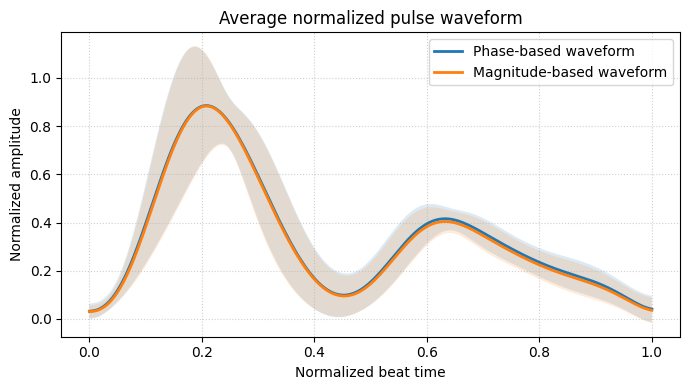

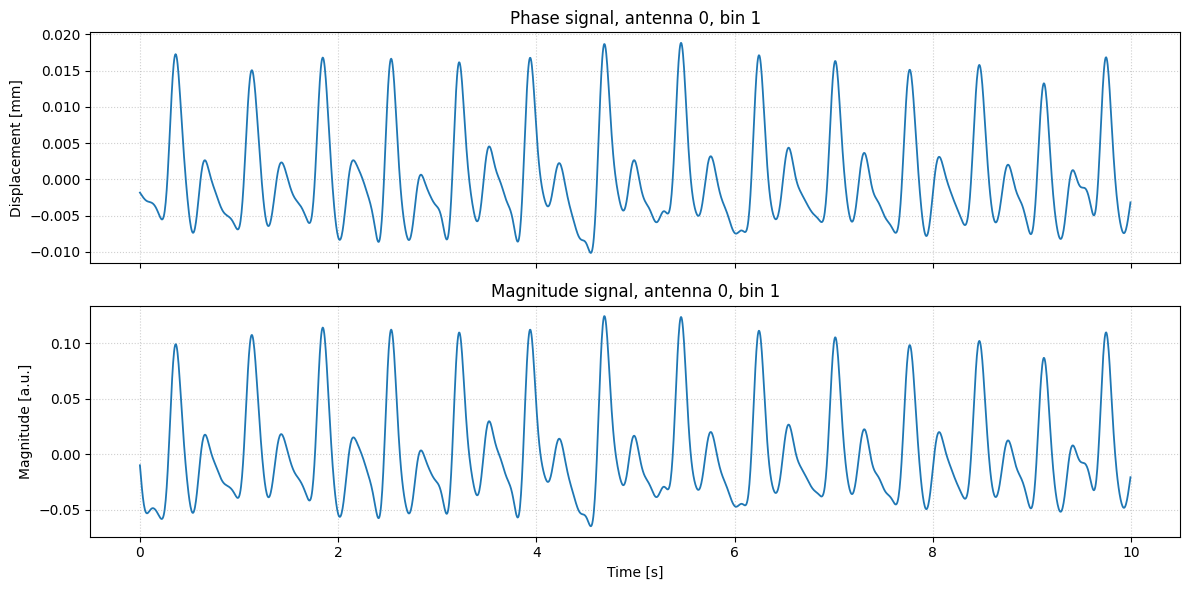

In [241]:
result_phase = results[1]
result_mag = results_mag[1]

x_norm = np.linspace(0, 1, POINTS_PER_BEAT)

plt.figure(figsize=(7, 4))

plt.plot(
    x_norm,
    result_phase["average_pulse"],
    linewidth=2,
    label="Phase-based waveform"
)

plt.plot(
    x_norm,
    result_mag["average_pulse"],
    linewidth=2,
    label="Magnitude-based waveform"
)

plt.fill_between(
    x_norm,
    result_phase["average_pulse"] - result_phase["std_pulse"],
    result_phase["average_pulse"] + result_phase["std_pulse"],
    alpha=0.15
)

plt.fill_between(
    x_norm,
    result_mag["average_pulse"] - result_mag["std_pulse"],
    result_mag["average_pulse"] + result_mag["std_pulse"],
    alpha=0.15
)

plt.title("Average normalized pulse waveform")
plt.xlabel("Normalized beat time")
plt.ylabel("Normalized amplitude")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



t_phase = result_phase["time_axis"]
phase_signal = result_phase["vital_signal"]

t_mag = result_mag["time_axis"]
mag_signal = result_mag["vital_signal"]

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axs[0].plot(t_phase, phase_signal, linewidth=1.3)
axs[0].set_title(
    f"Phase signal, antenna {result_phase['best_ant']}, bin {result_phase['best_bin']}"
)
axs[0].set_ylabel("Displacement [mm]")
axs[0].grid(True, linestyle=":", alpha=0.6)

axs[1].plot(t_mag, mag_signal, linewidth=1.3)
axs[1].set_title(
    f"Magnitude signal, antenna {result_mag['best_ant']}, bin {result_mag['best_bin']}"
)
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Magnitude [a.u.]")
axs[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

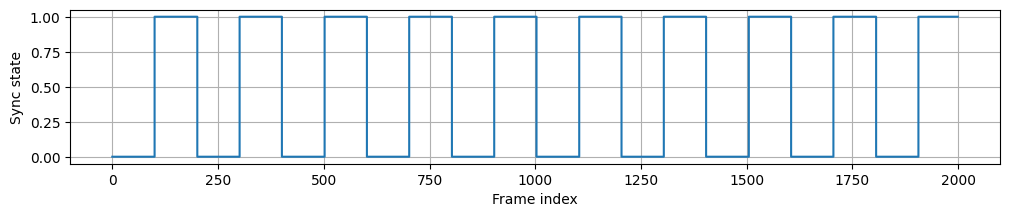

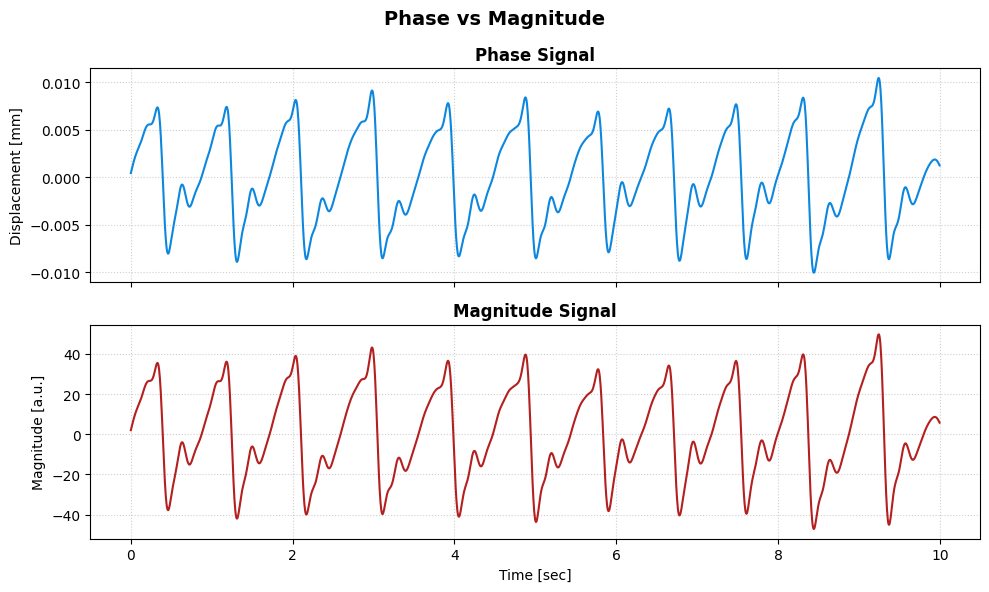

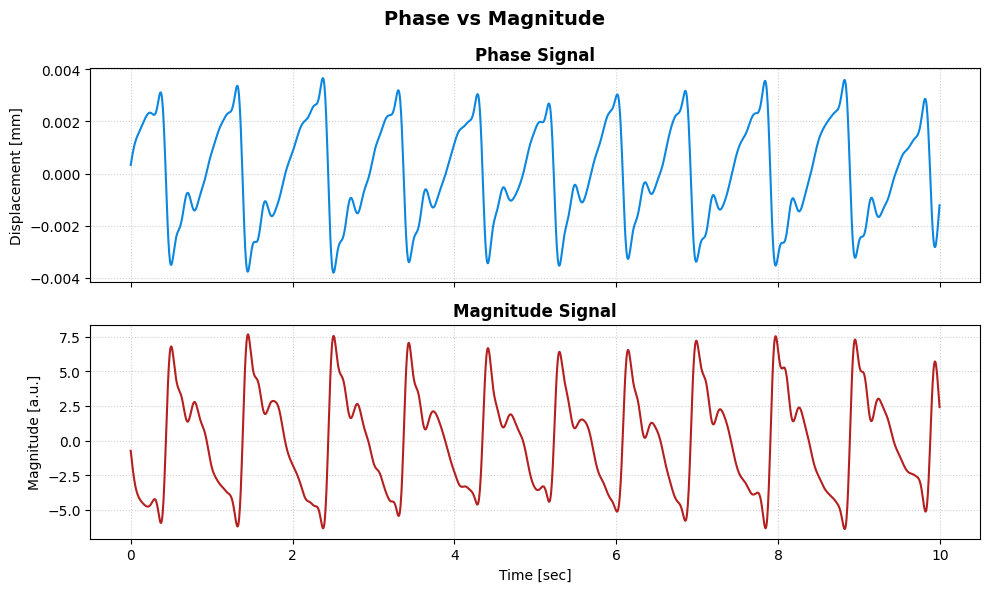

In [216]:
import os
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

# Verzeichnis mit deinen Messungen
#'radar_session_2026-03-05_23-31'
#'radar_session_2026-03-06_08-36'
# 'radar_session_2026-03-06_09-00'
input_folder = 'radar_session_2026-03-06_14-38_nima'
input_folder = 'radar_session_2026-05-15_17-13'
input_folder = 'radar_session_2026-05-18_12-10'
#input_folder = 'radar_session_2026-05-18_13-21'
#input_folder = 'radar_session_2026-05-18_12-14_bat'
input_folder = 'radar_session_2026-05-18_13-46'
input_folder = 'radar_session_2026-05-18_16-22'
input_folder = 'radar_invivo_fps_sweep_2026-05-20_12-33'
input_folder = 'radar_session_2026-03-06_17-39_seb'
input_folder = 'radar_session_2026-03-06_17-39_seb'
input_folder = 'radar_invivo_fps_sweep_2026-05-22_10-16'
input_folder = 'radar_invivo_fps_sweep_2026-05-22_17-28'

# Parameter (bleiben für alle gleich zum Vergleich)
lowcut = 0.5
highcut = 8.0
target_bin_index = 1
time = 10

# Alle .npy Dateien finden
files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

files = ['25_fps_data.npy', '50_fps_data.npy', '100_fps_data.npy', '150_fps_data.npy', '200_fps_data.npy']
files = ['01_200fps_35chrep_128ch_32sa.npy']
files = ['radar_invivo_fps_sweep_2026-05-22_17-28/fps_200_order_04_rep_3_data.npy', 'radar_invivo_fps_sweep_2026-05-22_17-51/fps_200_order_04_rep_3_data.npy']

#sync_state = np.load(os.path.join(input_folder, "fps_200_order_02_rep_1_sync_state.npy"))
plt.figure(figsize=(12,2))
plt.step(np.arange(len(sync_state)), sync_state, where="post")
plt.xlabel("Frame index")
plt.ylabel("Sync state")
plt.grid(True)
plt.show()


#print(f"Verarbeite {len(files)} Dateien direkt im Notebook...")

for filename in files:
    # 1. Laden
    #file_path = os.path.join(input_folder, filename)
    data = np.load(filename)
    #print(data.dtype)
    #print(data.min(), data.max())
    #print(np.percentile(data, [0, 1, 50, 99, 100]))
    #print(np.shape(data))
    #print(data)
    # Dimensionen automatisch erkennen
    # Erwartet (Frames, Antennas, Chirps, Samples)
    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames/time 
    
    # 2. Algorithmus (wie in deinem funktionierenden Code)
    mean_removed = data - np.mean(data, axis=-1, keepdims=True)
    window = np.hanning(num_samples)
    windowed_data = mean_removed * window
    range_fft = np.fft.rfft(windowed_data, axis=-1)
    
    # Phase extrahieren (erste Antenne, Mittelwert über Chirps)
    phase_data = np.angle(range_fft[:, 0, :, :]) 
    phase_time_series = np.mean(phase_data, axis=1)
    unwrapped_phase = np.unwrap(phase_time_series, axis=0)

    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77
    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm = (wavelength_mm * unwrapped_phase) / (4 * np.pi)

    magnitude = np.sqrt(np.square(np.real(range_fft[:, 0, :, :])) + np.square(np.imag(range_fft[:, 0, :, :])))
    magnitude_time_series = np.mean(magnitude, axis=1)


    # Filter
    nyquist = 0.5 * fps
    b, a = butter(N=4, Wn=[lowcut/nyquist, highcut/nyquist], btype='band')
    filtered_phase = filtfilt(b, a, displacement_mm, axis=0)

    filtered_magnitude = filtfilt(b,a ,magnitude_time_series, axis = 0)


    # Signal für Bin 1 (oder target_bin_index)
    vital_sign_signal = filtered_phase[:, target_bin_index]

    vital_sign_mag = filtered_magnitude[:, target_bin_index]

    #snr_wert = calculate_robust_snr(vital_sign_signal , fps)
    #print(f"SNR des Szenarios: {snr_wert:.2f} dB")

    # Polarität anpassen
    if np.mean(vital_sign_signal**3) < 0:
        vital_sign_signal *= -1


    #if np.mean(vital_sign_mag**3) < 0:
    #    vital_sign_mag *= -1

    # 3. Plotting direkt im Notebook
    time_axis = np.arange(num_frames) / fps

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Phase-Plot
    axs[0].plot(
        time_axis,
        vital_sign_signal,
        color="#0c87df",
        linewidth=1.5,
        label="Heartbeat-Signal Phase"
    )

    axs[0].set_title("Phase Signal", fontsize=12, fontweight="bold")
    axs[0].set_ylabel("Displacement [mm]")
    axs[0].grid(True, linestyle=":", alpha=0.6)
    #axs[0].legend(loc="upper right")

    # Magnitude-Plot
    axs[1].plot(
        time_axis,
        vital_sign_mag,
        color="#b41f1f",
        linewidth=1.5,
        label="Heartbeat-Signal Magnitude"
    )

    axs[1].set_title("Magnitude Signal", fontsize=12, fontweight="bold")
    axs[1].set_xlabel("Time [sec]")
    axs[1].set_ylabel("Magnitude [a.u.]")
    axs[1].grid(True, linestyle=":", alpha=0.6)
    #axs[1].legend(loc="upper right")

    fig.suptitle("Phase vs Magnitude", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

Verarbeite 1 Dateien direkt im Notebook...
float32
-0.5858364 0.44371188
[-0.58583641 -0.55311358  0.24151409  0.41147745  0.44371188]
(2000, 1, 128, 32)


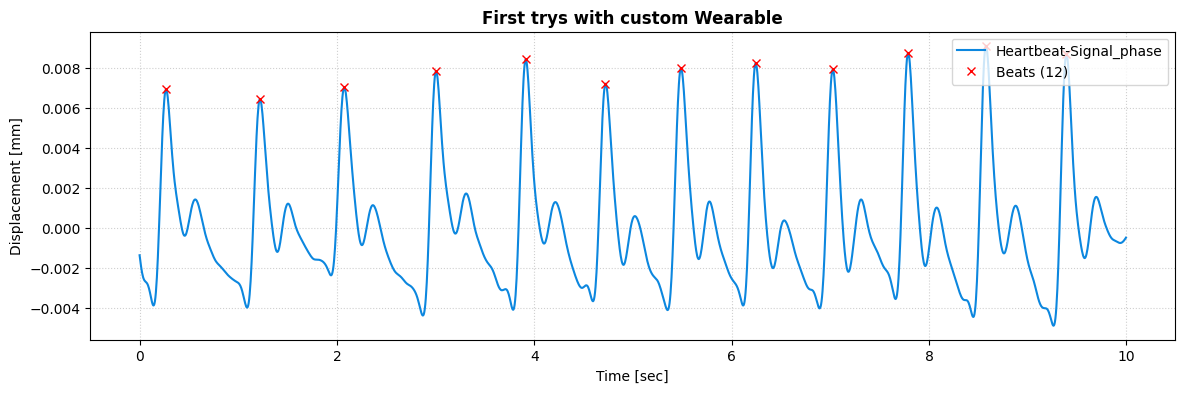

In [217]:
import os
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt

# Verzeichnis mit deinen Messungen
#'radar_session_2026-03-05_23-31'
#'radar_session_2026-03-06_08-36'
# 'radar_session_2026-03-06_09-00'
input_folder = 'radar_session_2026-03-06_14-38_nima'
input_folder = 'radar_session_2026-05-15_17-13'
input_folder = 'radar_session_2026-05-18_12-10'
#input_folder = 'radar_session_2026-05-18_13-21'
#input_folder = 'radar_session_2026-05-18_12-14_bat'
input_folder = 'radar_session_2026-05-18_13-46'
input_folder = 'radar_session_2026-05-18_16-22'
input_folder = 'radar_invivo_fps_sweep_2026-05-20_12-33'
input_folder = 'radar_session_2026-03-06_17-39_seb'


# Parameter (bleiben für alle gleich zum Vergleich)
lowcut = 0.5
highcut = 8.0
target_bin_index = 2
time = 10

# Alle .npy Dateien finden
files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

files = ['25_fps_data.npy', '50_fps_data.npy', '100_fps_data.npy', '150_fps_data.npy', '200_fps_data.npy']
files = ['01_200fps_35chrep_128ch_32sa.npy']

print(f"Verarbeite {len(files)} Dateien direkt im Notebook...")

for filename in files:
    # 1. Laden
    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)
    print(data.dtype)
    print(data.min(), data.max())
    print(np.percentile(data, [0, 1, 50, 99, 100]))
    print(np.shape(data))
    #print(data)
    # Dimensionen automatisch erkennen
    # Erwartet (Frames, Antennas, Chirps, Samples)
    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames/time 
    
    # 2. Algorithmus (wie in deinem funktionierenden Code)
    mean_removed = data - np.mean(data, axis=-1, keepdims=True)
    window = np.hanning(num_samples)
    windowed_data = mean_removed * window
    range_fft = np.fft.rfft(windowed_data, axis=-1)
    
    # Phase extrahieren (erste Antenne, Mittelwert über Chirps)
    phase_data = np.angle(range_fft[:, 0, :, :]) 
    phase_time_series = np.mean(phase_data, axis=1)
    unwrapped_phase = np.unwrap(phase_time_series, axis=0)

    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77
    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm = (wavelength_mm * unwrapped_phase) / (4 * np.pi)

    magnitude = np.sqrt(np.square(np.real(range_fft[:, 0, :, :])) + np.square(np.imag(range_fft[:, 0, :, :])))
    magnitude_time_series = np.mean(magnitude, axis=1)


    # Filter
    nyquist = 0.5 * fps
    b, a = butter(N=3, Wn=[lowcut/nyquist, highcut/nyquist], btype='band')
    filtered_phase = filtfilt(b, a, displacement_mm, axis=0)

    filtered_magnitude = filtfilt(b,a ,magnitude_time_series, axis = 0)


    # Signal für Bin 1 (oder target_bin_index)
    vital_sign_signal = filtered_phase[:, target_bin_index]

    vital_sign_mag = filtered_magnitude[:, target_bin_index]

    #snr_wert = calculate_robust_snr(vital_sign_signal , fps)
    #print(f"SNR des Szenarios: {snr_wert:.2f} dB")

    # Polarität anpassen
    if np.mean(vital_sign_signal**3) < 0:
        vital_sign_signal *= -1


    #if np.mean(vital_sign_mag**3) < 0:
    #    vital_sign_mag *= -1

    # 3. Plotting direkt im Notebook
    time_axis = np.arange(num_frames) / fps
    
    plt.figure(figsize=(14, 4))
    plt.plot(time_axis, vital_sign_signal, color="#0c87df", linewidth=1.5, label='Heartbeat-Signal_phase')
    
    #plt.plot(time_axis, vital_sign_mag, color="#b41f1f", linewidth=1.5, label='Heartbeat-Signal_mag')
    

    # Peaks markieren

    min_height = np.max(vital_sign_signal) * 0.3

    # 2. Dynamische Prominenz berechnen
    # Prominenz ist der Abstand vom Peak bis zum tiefsten Tal drumherum.
    # Das filtert kleine "Hubbel" (wie die am Rand) perfekt heraus.
    min_peak_distance = max(1, int(0.4 * fps))
    prominence = max(1e-9, 0.2 * np.std(vital_sign_signal))

    # 3. Die intelligente Peak-Detection
    peaks, properties = find_peaks(
        vital_sign_signal, 
        distance=min_peak_distance,   # Mindestens 0.5s Abstand (max 120 BPM)
        height=min_height,         # Schneidet die winzigen Peaks am Rand ab
        prominence=prominence  # Schneidet kleine Hubbel auf der abfallenden Flanke ab
    )
    #peaks, _ = find_peaks(vital_sign_signal, distance=int(fps*0.6))
    plt.plot(time_axis[peaks], vital_sign_signal[peaks], "rx", label=f'Beats ({len(peaks)})')

    # Styling
    #plt.title(f"{filename}", fontsize=20,  fontweight='bold')

    plt.title("First trys with custom Wearable", fontsize=12, fontweight='bold')
    plt.xlabel("Time [sec]")
    #plt.xlim((2,12))
    plt.ylabel("Displacement [mm]")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    plt.show() # In JPTNB zwingend, um nach jedem Loop das Bild zu rendern

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks


def bandpass_filter(data, fps, lowcut=0.5, highcut=8.0, order=3):
    nyquist = 0.5 * fps
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data)

def extract_average_pulse_waveform(signal, fps, num_points=100):
    # 1. Filtern
    filtered = bandpass_filter(signal, fps=fps)
    
    # 2. Peaks finden (mit Prominence für Stabilität)
    min_peak_distance = max(1, int(0.4 * fps))
    prominence = max(1e-9, 0.2 * np.std(filtered))
    peaks, _ = find_peaks(filtered, distance=min_peak_distance, prominence=prominence)
    
    if len(peaks) < 3: return None

    # 3. Segmente extrahieren und auf 100 Punkte resamplen
    beats = []
    for i in range(len(peaks) - 1):
        segment = filtered[peaks[i]:peaks[i+1]]
        if len(segment) < 4: continue
        
        x_old = np.linspace(0, 1, len(segment))
        x_new = np.linspace(0, 1, num_points)
        segment_resampled = np.interp(x_new, x_old, segment)
        beats.append(segment_resampled)
    
    if len(beats) < 2: return None
    
    beats = np.vstack(beats)
    mean_waveform = np.mean(beats, axis=0)
    
    # 4. Invertierung prüfen (Soll nach oben zeigen)
    k = max(3, int(0.10 * num_points))
    slope = np.polyfit(np.arange(k), mean_waveform[:k], 1)[0]
    if slope < 0:
        beats = -beats
        mean_waveform = np.mean(beats, axis=0)
        
    std_waveform = np.std(beats, axis=0)
    return np.linspace(0, 100, num_points), mean_waveform, std_waveform, len(beats)

# --- Haupt-Analyse für ein Szenario ---

def plot_scenario_quality(ax, file_path, fps, range_bin=1):
    # Daten laden (shape: frames, antennas, chirps, samples)
    data = np.load(file_path)
    
    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, range_bin] # Alle Chirps des Bins
    
    # Mittelwert über Chirps und Phase berechnen
    #print(bin_values.shape)
   # print(bin_values[:, :32].shape)
    complex_mean = np.mean(bin_values, axis=1)
    phase_signal = np.angle(complex_mean)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
    unwrapped_phase = np.unwrap(phase_signal)

    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm = (wavelength_mm * unwrapped_phase) / (4 * np.pi)
        
    # Durchschnittlichen Beat berechnen
    result = extract_average_pulse_waveform(displacement_mm, fps)
    

    if result:
        x_axis, mean_beat, std_beat, num_beats = result

        print(np.max(mean_beat) - np.min(mean_beat))
        
        ax.fill_between(x_axis, mean_beat - std_beat, mean_beat + std_beat, 
                        color='blue', alpha=0.15)
        ax.plot(x_axis, mean_beat, color='blue', lw=2, label='form')


        ax.set_title(f"{file_path.split('\\')[-1]}", fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Quality Index ausgeben
        #quality_score = 1.0 / np.mean(std_beat)
        #print(f"Quality Score (Stabilität): {quality_score:.2f}")
    else:
        print("Konnte keine sauberen Beats für dieses File finden.")

# Beispielaufruf:
# plot_scenario_quality("03_200fps_73chrep_32ch_128sa.npy", fs=200)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

def plot_peak_to_peak(file_path, fps, range_bin=1):
    # Daten laden (shape: frames, antennas, chirps, samples)
    data = np.load(file_path)
    
    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, range_bin] # Alle Chirps des Bins
    
    # Mittelwert über Chirps und Phase berechnen
    #print(bin_values.shape)
   # print(bin_values[:, :32].shape)
    complex_mean = np.mean(bin_values[:, :32], axis=1)
    phase_signal = np.angle(complex_mean)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
    unwrapped_phase = np.unwrap(phase_signal)

    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm = (wavelength_mm * unwrapped_phase) / (4 * np.pi)
        
    # Durchschnittlichen Beat berechnen
    result = extract_average_pulse_waveform(displacement_mm, fps)
    

    if result:
        x_axis, mean_beat, std_beat, num_beats = result

        return x_axis, np.max(mean_beat) - np.min(mean_beat)
        
    else:
        print("Konnte keine sauberen Beats für dieses File finden.")

0.005978163957809739


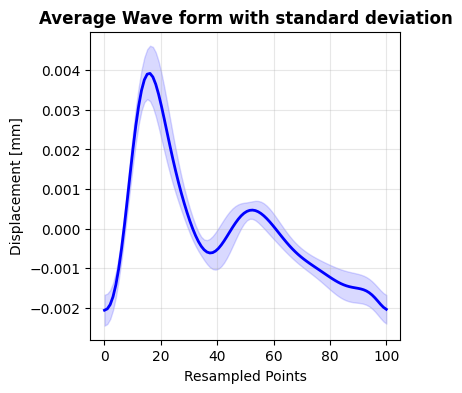

In [56]:
input_folder = 'radar_session_2026-03-06_17-39_seb'
filename ='01_200fps_35chrep_128ch_32sa.npy'

plt.figure(figsize=(4, 4))


file_path = os.path.join(input_folder, filename)
data = np.load(file_path)

num_frames, num_ant, num_chirps, num_samples = data.shape
fps = num_frames/time 
    # Daten laden (shape: frames, antennas, chirps, samples)
data = np.load(file_path)
    
    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
bin_values = range_fft[:, :, 1] # Alle Chirps des Bins
    
    # Mittelwert über Chirps und Phase berechnen
    #print(bin_values.shape)
   # print(bin_values[:, :32].shape)
complex_mean = np.mean(bin_values, axis=1)
phase_signal = np.angle(complex_mean)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
unwrapped_phase = np.unwrap(phase_signal)

RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

c = 3e8                                     # speed of light m/s
wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
displacement_mm = (wavelength_mm * unwrapped_phase) / (4 * np.pi)
        
    # Durchschnittlichen Beat berechnen
result = extract_average_pulse_waveform(displacement_mm, fps)
x_axis, mean_beat, std_beat, num_beats = result

print(np.max(mean_beat) - np.min(mean_beat))
        
plt.fill_between(x_axis, mean_beat - std_beat, mean_beat + std_beat, 
                        color='blue', alpha=0.15)
plt.plot(x_axis, mean_beat, color='blue', lw=2, label='form')


plt.grid(True, alpha=0.3)
       


plt.title(f"Average Wave form with standard deviation",  fontsize=12, fontweight='bold')
plt.ylabel("Displacement [mm]")
plt.xlabel("Resampled Points")
plt.show()

0.030150770649503025
0.0235378111952746
0.022061267635941025
0.029107319271446816
0.028709547857629567
0.021010506212013974
0.020625739750336665
0.026109263317150855
0.02614435890449033
0.02580051127908667
0.026387213033560352
0.020104956722946724
0.019201712978094063
0.028258879371916033
0.018407560743720238
0.023362170667919877
0.015703140753274787
0.023384532197841958


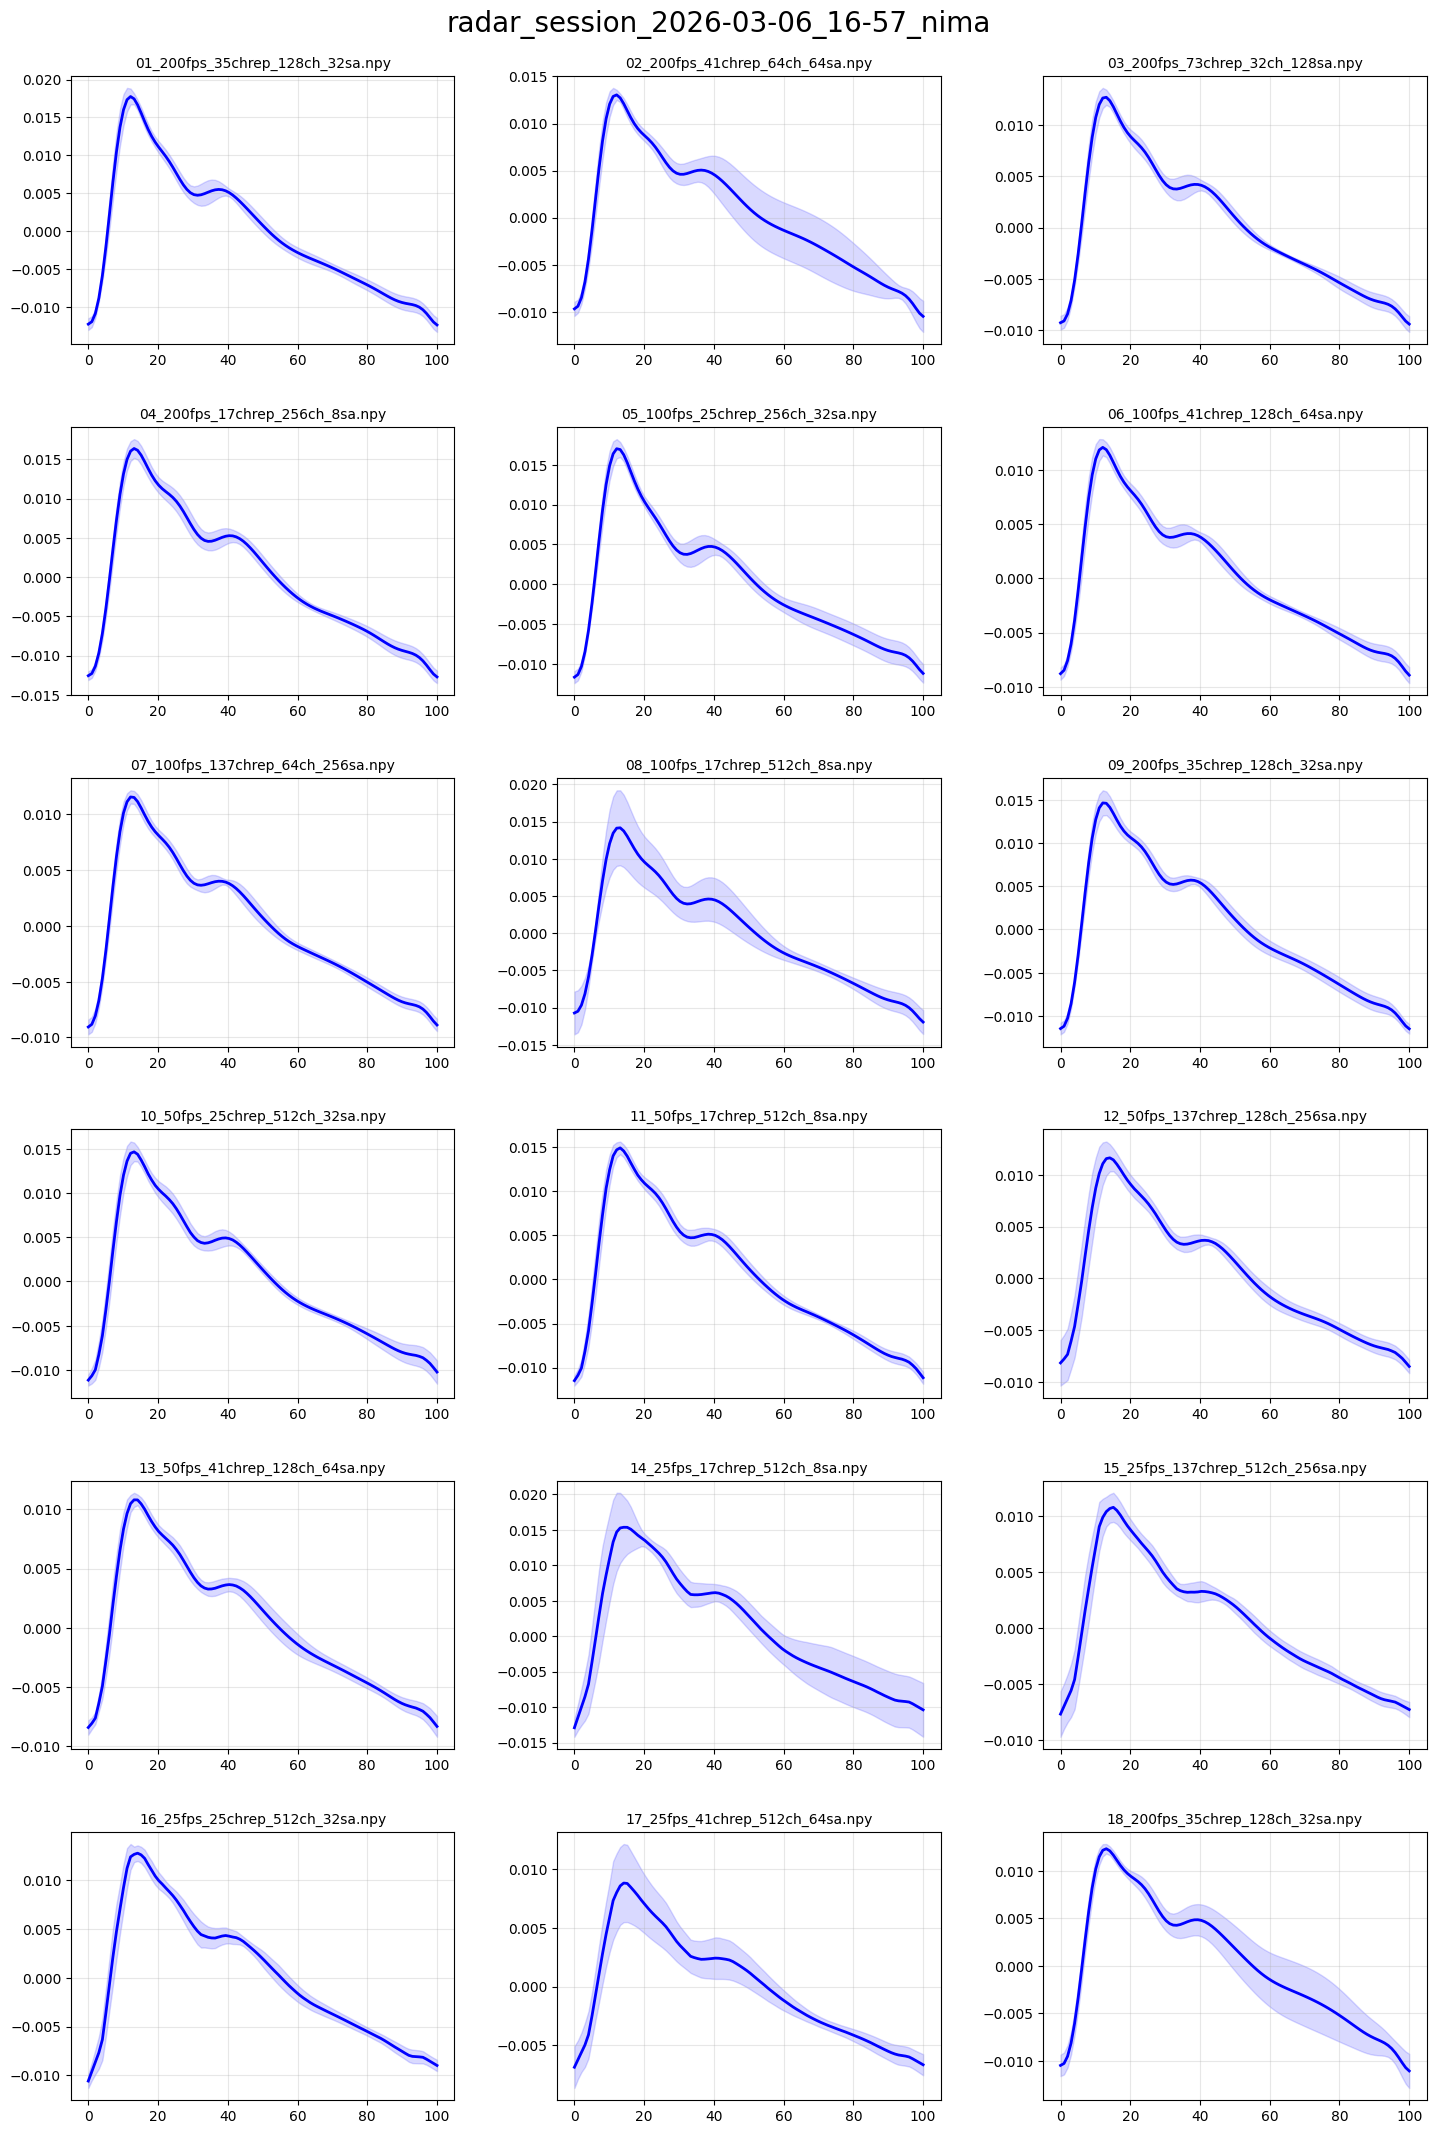

In [62]:
input_folder = 'radar_session_2026-03-06_16-57_nima'

time = 10

files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

fig, axes = plt.subplots(6, 3, figsize=(15, 22))
axes_flat = axes.flatten()


for i, filename in enumerate(files):
    ax = axes_flat[i]

    # 1. Laden
    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)

    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames/time 
    plot_scenario_quality(ax, file_path, fps)

    if i % 3 != 0: ax.set_ylabel("") 
    if i < 15: ax.set_xlabel("")


plt.tight_layout(pad=3.0) # Erhöht den Abstand zwischen den Plots
plt.subplots_adjust(top=0.95) # Platz für eine Hauptüberschrift
fig.suptitle(f"{input_folder}", fontsize=20)

plt.show()

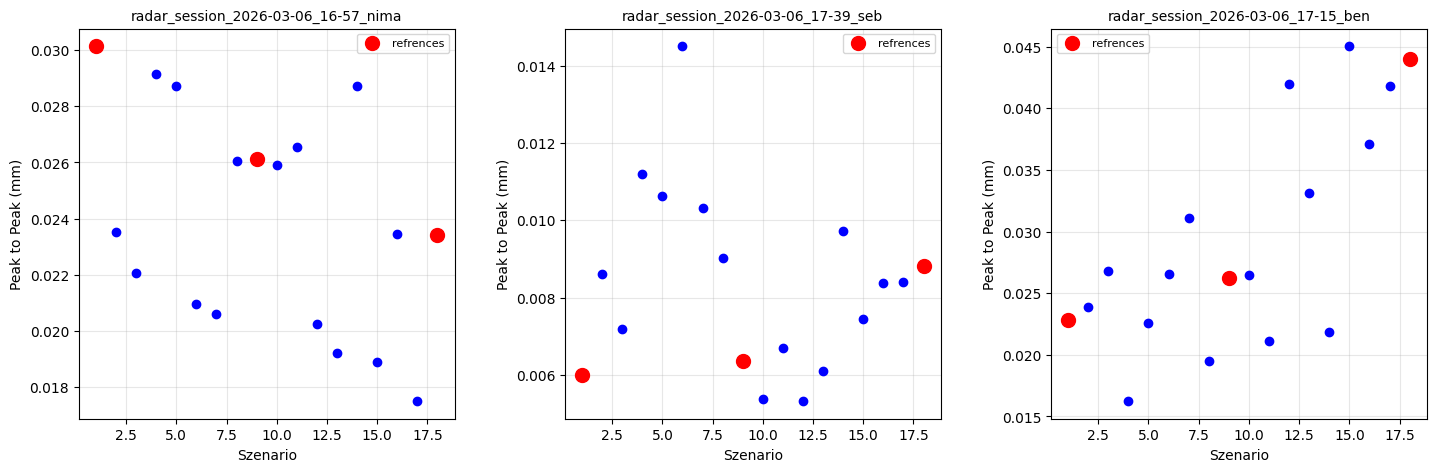

In [63]:
input_folder = 'radar_session_2026-03-06_16-57_nima'
inputs = ['radar_session_2026-03-06_16-57_nima', 'radar_session_2026-03-06_17-39_seb', 'radar_session_2026-03-06_17-15_ben']
time = 10

x = np.linspace(1,18,18)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes_flat = axes.flatten()

for j, input_folder in enumerate(inputs):
    peak_to_peak = []
    ax = axes_flat[j]
    files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])
    for i, filename in enumerate(files):

        file_path = os.path.join(input_folder, filename)
        data = np.load(file_path)
        

        num_frames, num_ant, num_chirps, num_samples = data.shape
        fps = num_frames/time 
        x_axis, ptp = plot_peak_to_peak(file_path=file_path, fps =fps)
        
        peak_to_peak.append(ptp)

    peak_to_peak = np.array(peak_to_peak)
    
    highlight_idx = [0, 8, 17]
    
    ax.plot(x, peak_to_peak,'o', color='blue', lw=2)

    ax.plot(x[highlight_idx], peak_to_peak[highlight_idx], 'o', color='red', 
            markersize=10, zorder=5, label='refrences')

    ax.set_title(f"{input_folder.split('/')[0]}", fontsize=10)
    ax.set_xlabel("Szenario")
    ax.set_ylabel("Peak to Peak (mm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)



plt.tight_layout(pad=3.0) # Erhöht den Abstand zwischen den Plots
plt.subplots_adjust(top=0.95) # Platz für eine Hauptüberschrift

plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks


def extract_middle_pulse_waveform(signal, fps, num_points=100):
    # 1. Filtern
    #filtered = bandpass_filter(signal, fps=fps)
    
    # 2. Peaks finden (mit Prominence für Stabilität)
    min_peak_distance = max(1, int(0.4 * fps))
    prominence = max(1e-9, 0.2 * np.std(signal))
    peaks, _ = find_peaks(signal, distance=min_peak_distance, prominence=prominence)
    
    if len(peaks) < 3: return None

    # 3. Segmente extrahieren und auf 100 Punkte resamplen
    beats = []
    for i in range(len(peaks) - 1):
        segment = signal[peaks[i]:peaks[i+1]]
        if len(segment) < 4: continue
        
        x_old = np.linspace(0, 1, len(segment))
        x_new = np.linspace(0, 1, num_points)
        segment_resampled = np.interp(x_new, x_old, segment)
        beats.append(segment_resampled)
    
    if len(beats) < 2: return None
    
    beats = np.vstack(beats)
    mean_waveform = np.mean(beats, axis=0)
    
    # 4. Invertierung prüfen (Soll nach oben zeigen)
    k = max(3, int(0.10 * num_points))
    slope = np.polyfit(np.arange(k), mean_waveform[:k], 1)[0]
    if slope < 0:
        beats = -beats

    correlations = np.array([
        np.mean([np.corrcoef(beats[i], beats[j])[0, 1] 
                 for j in range(len(beats)) if i != j])
        for i in range(len(beats))
    ])
    median_beat = beats[np.argmax(correlations)]

    return np.linspace(0, 100, num_points), median_beat


def plot_chirps(ax, file_path, fps, ref ,range_bin=1):
    # Daten laden (shape: frames, antennas, chirps, samples)
    data = np.load(file_path)
    
    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, range_bin] # Alle Chirps des Bins
    
    # Mittelwert über Chirps und Phase berechnen
    #print(bin_values.shape)
   # print(bin_values[:, :32].shape)
    complex_mean_1 = np.mean(bin_values[:, :1], axis=1)
    complex_mean_32 = np.mean(bin_values[:, :32], axis=1)
    complex_mean_all = np.mean(bin_values, axis=1)
    phase_signal_1 = np.angle(complex_mean_1)
    phase_signal_32 = np.angle(complex_mean_32)
    phase_signal_all = np.angle(complex_mean_all)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
    unwrapped_phase_1 = np.unwrap(phase_signal_1)
    unwrapped_phase_32 = np.unwrap(phase_signal_32)
    unwrapped_phase_all = np.unwrap(phase_signal_all)

    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm_1 = (wavelength_mm * unwrapped_phase_1) / (4 * np.pi)
    displacement_mm_32 = (wavelength_mm * unwrapped_phase_32) / (4 * np.pi)
    displacement_mm_all = (wavelength_mm * unwrapped_phase_all) / (4 * np.pi)
        
    #print(displacement_mm_1.shape, '  ',displacement_mm_32.shape, '  ',displacement_mm_all.shape,)
        
    # Durchschnittlichen Beat berechnen
    #result = extract_average_pulse_waveform(displacement_mm, fps)

    x_axis, wave_1 = extract_middle_pulse_waveform(displacement_mm_1, fps)
    _, wave_32 = extract_middle_pulse_waveform(displacement_mm_32, fps)
    _, wave_all = extract_middle_pulse_waveform(displacement_mm_all, fps)
    wave_1 = (wave_1 - np.min(wave_1)) / (np.max(wave_1) - np.min(wave_1))
    wave_32 = (wave_32 - np.min(wave_32)) / (np.max(wave_32) - np.min(wave_32))
    wave_all = (wave_all - np.min(wave_all)) / (np.max(wave_all) - np.min(wave_all))
    '''
    peak = np.max(np.abs(wave_1))
    if peak > 0:
        wave_1 = wave_1 / peak

    peak = np.max(np.abs(wave_32))
    if peak > 0:
        wave_32 = wave_32 / peak

    peak = np.max(np.abs(wave_all))
    if peak > 0:
        wave_all = wave_all / peak
    '''
    ax.plot(x_axis, wave_1, color='red', lw=2, label='1')
    ax.plot(x_axis, wave_32, color='green', lw=2, label='32')
    ax.plot(x_axis, wave_all, color='blue', lw=2, label='all')
    ax.plot(x_axis, ref, color='black', lw=2, label='ref', linestyle='dashed')



    ax.set_title(f"{file_path.split('\\')[-1]}", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    #    return x_axis, np.max(mean_beat) - np.min(mean_beat)


(100,)


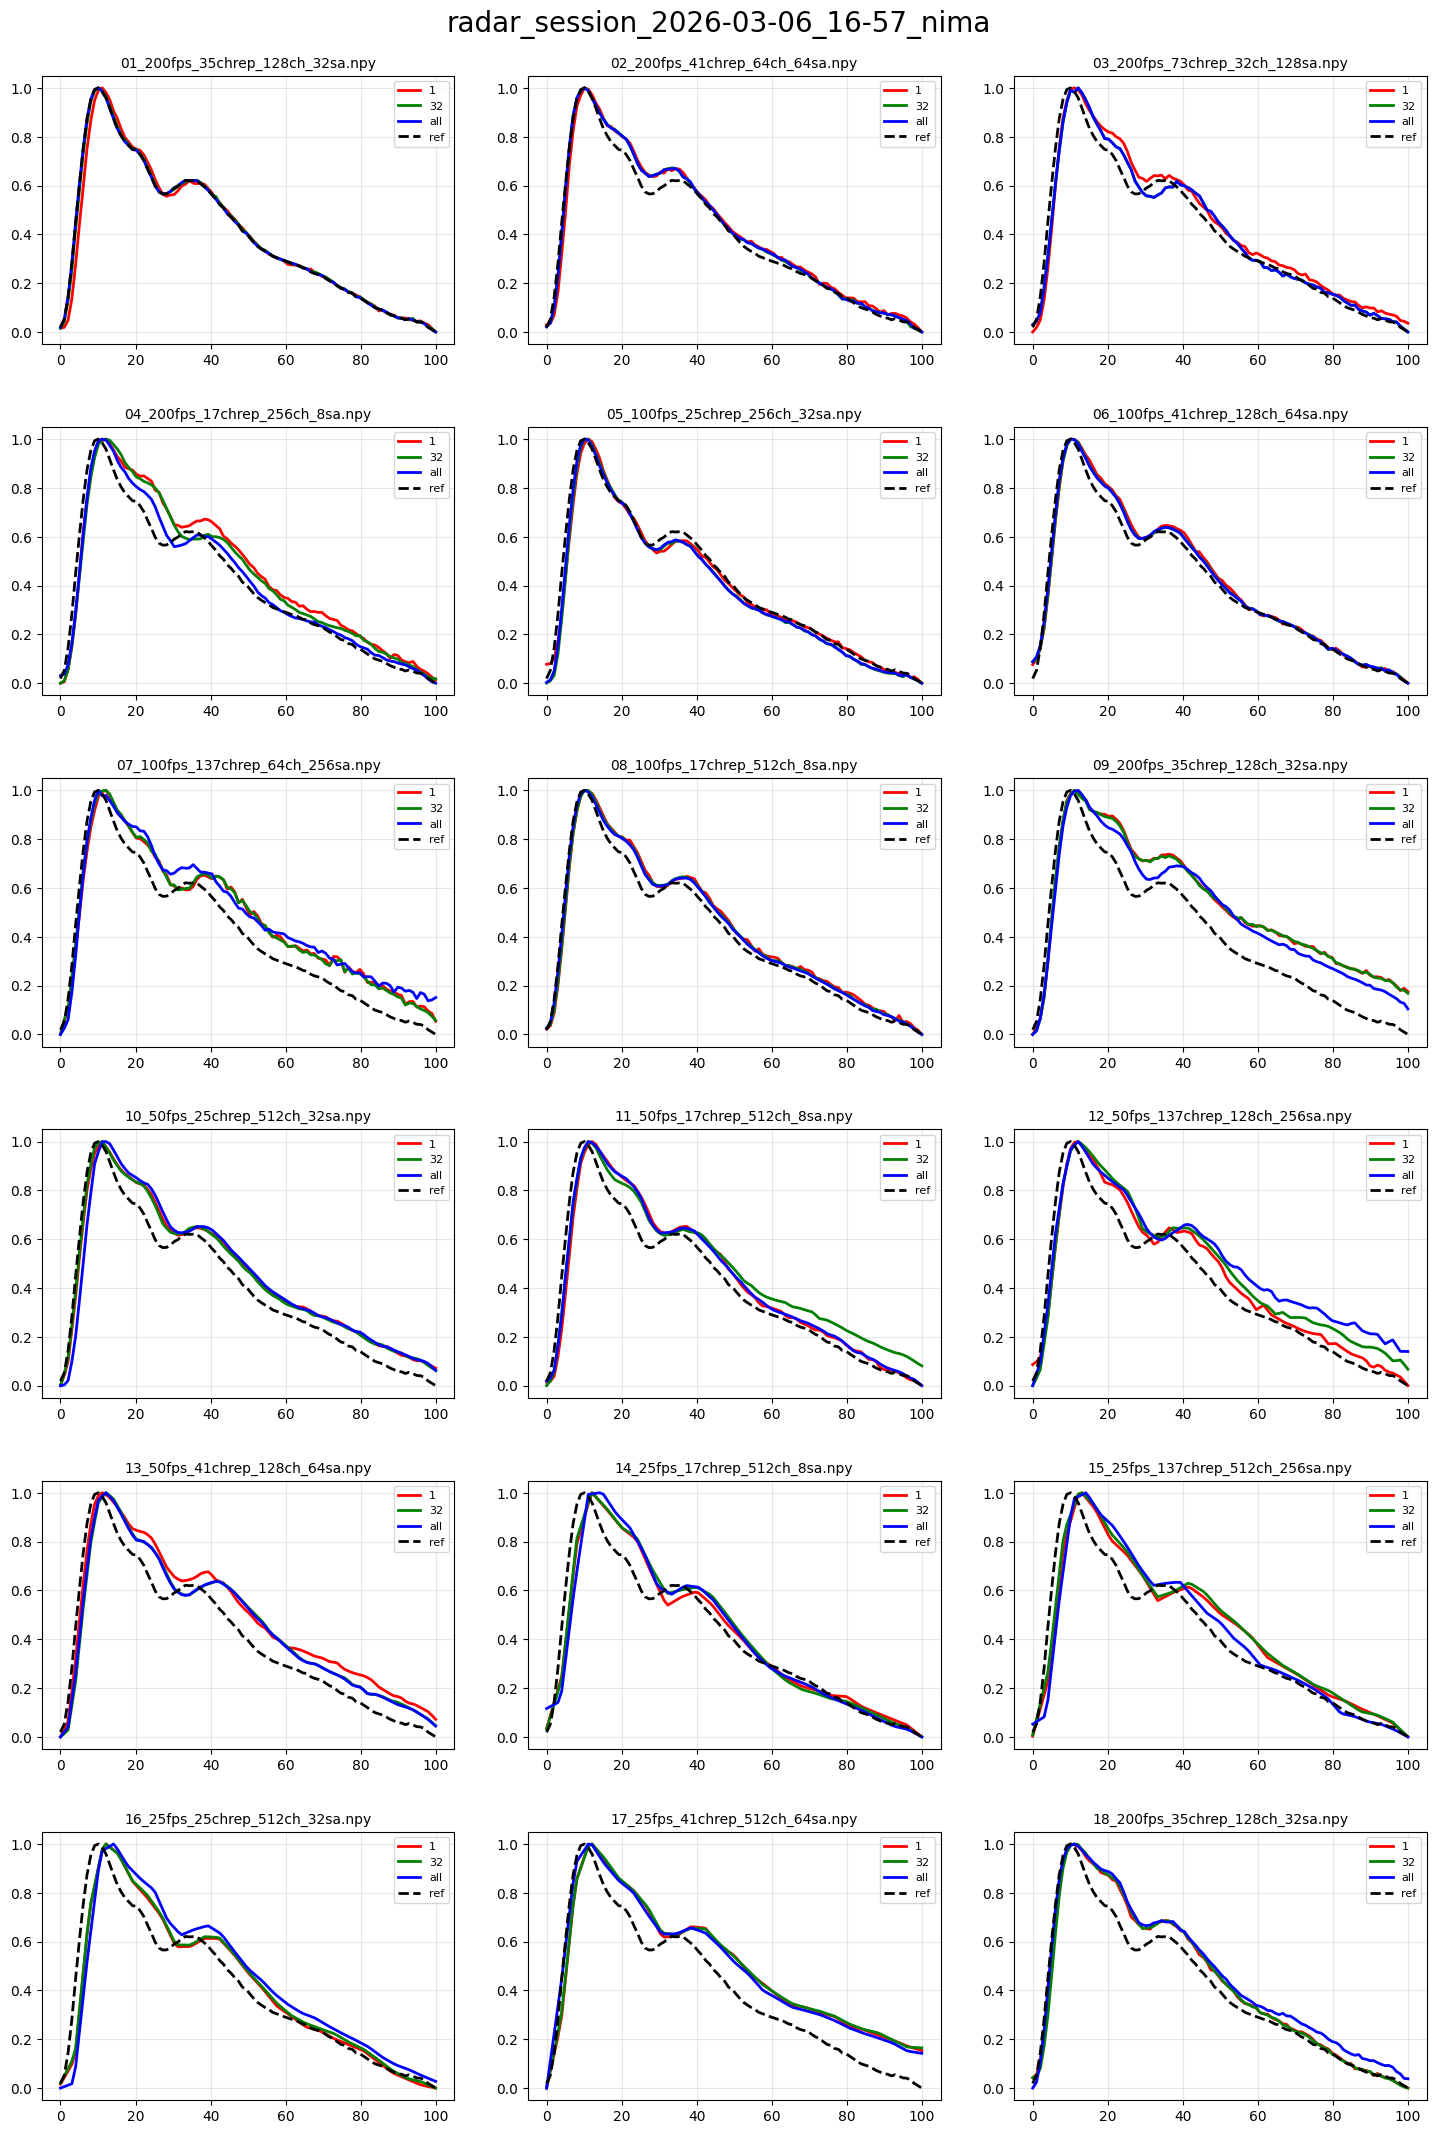

In [65]:
input_folder = 'radar_session_2026-03-06_16-57_nima'

time = 10

files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

fig, axes = plt.subplots(6, 3, figsize=(15, 22))
axes_flat = axes.flatten()

data = np.load(os.path.join(input_folder, files[0]))
    
# Phase extrahieren (wie in deinem RadarReader)
# Wir nehmen Antenne 0 und den gewählten Range-Bin
# FFT über die Samples pro Chirp
range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
bin_values = range_fft[:, :, 1] # Alle Chirps des Bins
    
    # Mittelwert über Chirps und Phase berechnen
    #print(bin_values.shape

complex_mean_all = np.mean(bin_values, axis=1)
phase_signal_all = np.angle(complex_mean_all)

unwrapped_phase_all = np.unwrap(phase_signal_all)

RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

c = 3e8                                     # speed of light m/s
wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
wavelength_mm = wavelength_m * 1000         # in mm
displacement_mm_all = (wavelength_mm * unwrapped_phase_all) / (4 * np.pi)
_, wave_all = extract_middle_pulse_waveform(displacement_mm_all, fps)
wave_all = (wave_all - np.min(wave_all)) / (np.max(wave_all) - np.min(wave_all))
print(wave_all.shape)



for i, filename in enumerate(files):
    ax = axes_flat[i]

    # 1. Laden
    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)

    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames/time 
    plot_chirps(ax, file_path, fps, wave_all)

    if i % 3 != 0: ax.set_ylabel("") 
    if i < 15: ax.set_xlabel("")


plt.tight_layout(pad=3.0) # Erhöht den Abstand zwischen den Plots
plt.subplots_adjust(top=0.95) # Platz für eine Hauptüberschrift
fig.suptitle(f"{input_folder}", fontsize=20)

plt.show()

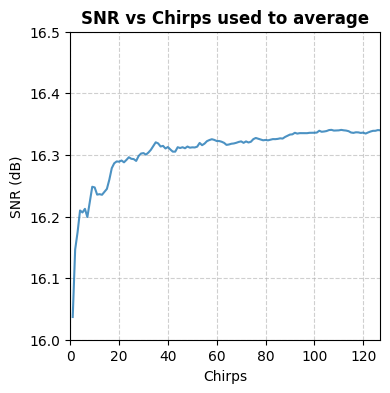

In [53]:
import os
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt


input_folder = 'radar_session_2026-03-06_17-39_seb'
input_folder = 'radar_invivo_fps_sweep_2026-05-20_12-33'

input_folder = 'radar_session_2026-03-06_17-39_seb'
filename ='01_200fps_35chrep_128ch_32sa.npy'


# Parameter (bleiben für alle gleich zum Vergleich)

target_bin_index = 1
time = 10

# Alle .npy Dateien finden
files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

files = [filename]

plt.figure(figsize=(4, 4))

for filename in files:
    # 1. Laden
    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)

    # Erwartet (Frames, Antennas, Chirps, Samples)
    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames/time 
    

    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, target_bin_index] # Alle Chirps des Bins
    
    snr = []

    # Mittelwert über Chirps und Phase berechnen
    # print(bin_values.shape)
    # print(bin_values[:, :32].shape)
    for i in range(1, num_chirps + 1):
        complex_mean_1 = np.mean(bin_values[:, :i], axis=1)
        phase_signal_1 = np.angle(complex_mean_1)

        #Unwrapping um 2pi-Sprünge zu entfernen
        unwrapped_phase_1 = np.unwrap(phase_signal_1)

        RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

        c = 3e8                                     # speed of light m/s
        wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
        wavelength_mm = wavelength_m * 1000         # in mm

        # Convert unwrapped phase (radians) → displacement (mm)
        displacement_mm_1 = (wavelength_mm * unwrapped_phase_1) / (4 * np.pi)


        signal = bandpass_filter(displacement_mm_1, fps, lowcut=0.5, highcut=6, order=3)
        noise = bandpass_filter(displacement_mm_1, fps, lowcut=6, highcut=12, order=3)

        p_signal = np.mean(signal ** 2)
        p_noise  = np.mean(noise ** 2)

        snr.append(10 * np.log10(p_signal / p_noise))

    #label_name = filename.split('_')[1] if '_' in filename else filename
    label_name = filename
    plt.plot(range(1, num_chirps + 1), snr, label=f"{label_name})", alpha=0.8)

# 3. Styling NACHDEM alle Linien gezeichnet wurden

plt.title(f"SNR vs Chirps used to average",  fontsize=12, fontweight='bold')
plt.xlabel("Chirps")
plt.xlim(0, 127)
plt.ylim(16, 16.5)
plt.ylabel("SNR (dB)")
plt.grid(True, linestyle='--', alpha=0.6)
#plt.xscale('log')
plt.show()

In [104]:
import os
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt


input_folder = 'radar_session_2026-03-06_17-39_seb'
input_folder = 'radar_session_2026-03-06_16-57_nima'
input_folder = 'radar_session_2026-03-06_15-18_seb'
#input_folder = 'radar_invivo_fps_sweep_2026-05-20_12-33'
input_folders = [
    'radar_session_2026-03-06_17-39_seb',
    'radar_session_2026-03-06_15-18_seb',
    'radar_session_2026-03-06_16-57_nima',
    'radar_session_2026-03-06_14-38_nima',
    'radar_session_2026-03-06_17-27_seb',
    'radar_session_2026-03-06_17-15_ben',
]


# Parameter (bleiben für alle gleich zum Vergleich)

target_bin_index = 1
time = 10

# Alle .npy Dateien finden

plt.figure(figsize=(12, 7))
all_snr_norm = []
max_chirps = 512  # oder automatisch bestimmen

for input_folder in input_folders:

    files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

    for filename in files:
        # 1. Laden
        file_path = os.path.join(input_folder, filename)
        data = np.load(file_path)

        # Erwartet (Frames, Antennas, Chirps, Samples)
        num_frames, num_ant, num_chirps, num_samples = data.shape
        fps = num_frames/time 
        

        # Phase extrahieren (wie in deinem RadarReader)
        # Wir nehmen Antenne 0 und den gewählten Range-Bin
        # FFT über die Samples pro Chirp
        range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
        bin_values = range_fft[:, :, target_bin_index] # Alle Chirps des Bins
        
        snr = []

        # Mittelwert über Chirps und Phase berechnen
        # print(bin_values.shape)
        # print(bin_values[:, :32].shape)
        for i in range(1, min(max_chirps+1,num_chirps+ 1)):
            complex_mean_1 = np.mean(bin_values[:, :i], axis=1)
            phase_signal_1 = np.angle(complex_mean_1)

            #Unwrapping um 2pi-Sprünge zu entfernen
            unwrapped_phase_1 = np.unwrap(phase_signal_1)

            RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

            c = 3e8                                     # speed of light m/s
            wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
            wavelength_mm = wavelength_m * 1000         # in mm

            # Convert unwrapped phase (radians) → displacement (mm)
            displacement_mm_1 = (wavelength_mm * unwrapped_phase_1) / (4 * np.pi)


            signal = bandpass_filter(displacement_mm_1, fps, lowcut=0.5, highcut=6, order=3)
            noise = bandpass_filter(displacement_mm_1, fps, lowcut=6, highcut=12, order=3)

            p_signal = np.mean(signal ** 2)
            p_noise  = np.mean(noise ** 2)

            snr.append(10 * np.log10(p_signal / p_noise))

        #label_name = filename.split('_')[1] if '_' in filename else filename

        snr = np.array(snr)

        snr = (snr - np.min(snr)) / (np.max(snr) - np.min(snr) + 1e-12)

        padded = np.full(max_chirps, np.nan)
        padded[:num_chirps] = snr

        all_snr_norm.append(padded)

<Figure size 1200x700 with 0 Axes>

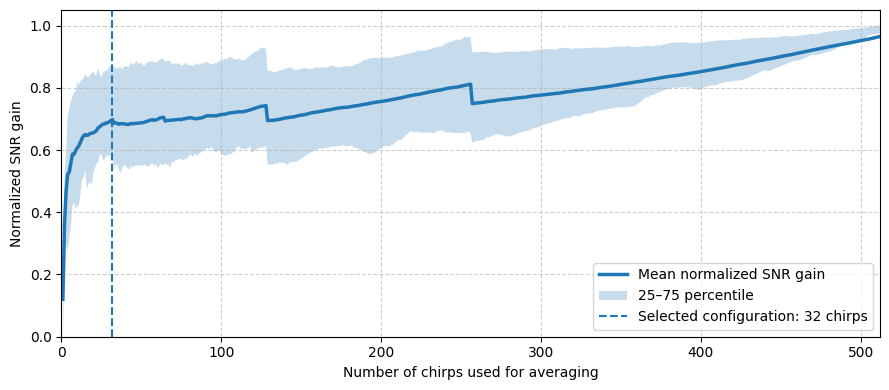

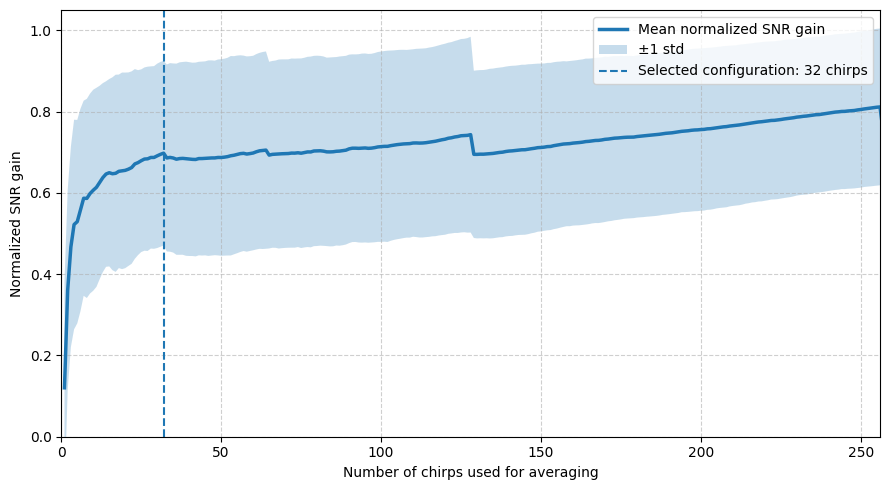

In [108]:
all_snr_norm = np.array(all_snr_norm)
# 3. Styling NACHDEM alle Linien gezeichnet wurden
chirp_axis = np.arange(1, max_chirps + 1)

mean_snr = np.nanmean(all_snr_norm, axis=0)
lower = np.nanpercentile(all_snr_norm, 25, axis=0)
upper = np.nanpercentile(all_snr_norm, 75, axis=0)

# Anzahl Kurven pro Chirp, wichtig zur Kontrolle
n_available = np.sum(~np.isnan(all_snr_norm), axis=0)
plt.figure(figsize=(9, 4))

plt.plot(
    chirp_axis,
    mean_snr,
    linewidth=2.5,
    label="Mean normalized SNR gain"
)

plt.fill_between(
    chirp_axis,
    lower,
    upper,
    alpha=0.25,
    label="25–75 percentile"
)

plt.axvline(
    x=32,
    linestyle="--",
    linewidth=1.5,
    label="Selected configuration: 32 chirps"
)

plt.xlabel("Number of chirps used for averaging")
plt.ylabel("Normalized SNR gain")
plt.ylim(0, 1.05)
plt.xlim(0, 512)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


std_snr = np.nanstd(all_snr_norm, axis=0)

plt.figure(figsize=(9, 5))

plt.plot(
    chirp_axis,
    mean_snr,
    linewidth=2.5,
    label="Mean normalized SNR gain"
)

plt.fill_between(
    chirp_axis,
    mean_snr - std_snr,
    mean_snr + std_snr,
    alpha=0.25,
    label="±1 std"
)

plt.axvline(
    x=32,
    linestyle="--",
    linewidth=1.5,
    label="Selected configuration: 32 chirps"
)

plt.xlabel("Number of chirps used for averaging")
plt.ylabel("Normalized SNR gain")
plt.ylim(0, 1.05)
plt.xlim(0,256)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

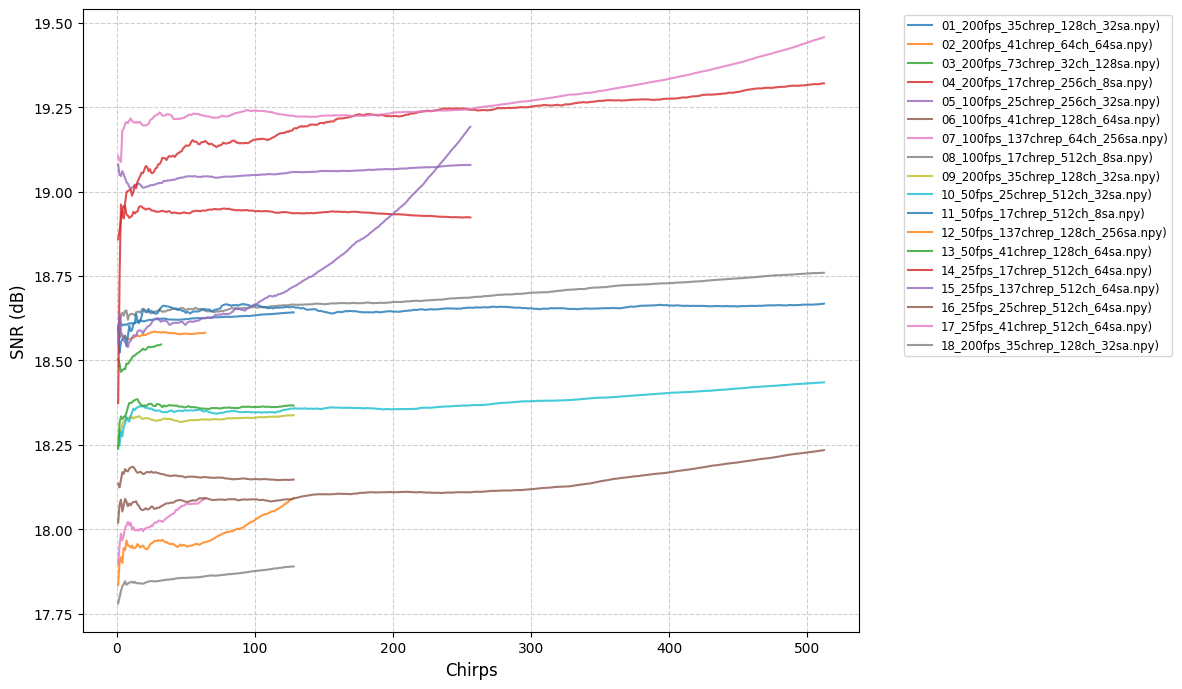

In [85]:
import os
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt


input_folder = 'radar_session_2026-03-06_17-39_seb'
input_folder = 'radar_session_2026-03-06_15-18_seb'
input_folder = 'radar_session_2026-03-06_16-57_nima'
input_folder = 'radar_session_2026-03-06_14-38_nima'
input_folder = 'radar_session_2026-03-06_17-27_seb'
input_folder = 'radar_session_2026-03-06_17-15_ben'
#input_folder = 'radar_invivo_fps_sweep_2026-05-20_12-33'


# Parameter (bleiben für alle gleich zum Vergleich)

target_bin_index = 1
time = 10

# Alle .npy Dateien finden
files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

plt.figure(figsize=(12, 7))

for filename in files:
    # 1. Laden
    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)

    # Erwartet (Frames, Antennas, Chirps, Samples)
    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames/time 
    

    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, target_bin_index] # Alle Chirps des Bins
    
    snr = []

    # Mittelwert über Chirps und Phase berechnen
    # print(bin_values.shape)
    # print(bin_values[:, :32].shape)
    for i in range(1, num_chirps + 1):
        complex_mean_1 = np.mean(bin_values[:, :i], axis=1)
        phase_signal_1 = np.angle(complex_mean_1)

        #Unwrapping um 2pi-Sprünge zu entfernen
        unwrapped_phase_1 = np.unwrap(phase_signal_1)

        RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

        c = 3e8                                     # speed of light m/s
        wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
        wavelength_mm = wavelength_m * 1000         # in mm

        # Convert unwrapped phase (radians) → displacement (mm)
        displacement_mm_1 = (wavelength_mm * unwrapped_phase_1) / (4 * np.pi)


        signal = bandpass_filter(displacement_mm_1, fps, lowcut=0.5, highcut=6, order=3)
        noise = bandpass_filter(displacement_mm_1, fps, lowcut=6, highcut=12, order=3)

        p_signal = np.mean(signal ** 2)
        p_noise  = np.mean(noise ** 2)

        snr.append(10 * np.log10(p_signal / p_noise))

    #label_name = filename.split('_')[1] if '_' in filename else filename
    label_name = filename
    plt.plot(range(1, num_chirps + 1), snr, label=f"{label_name})", alpha=0.8)

# 3. Styling NACHDEM alle Linien gezeichnet wurden
plt.xlabel("Chirps", fontsize=12)


plt.ylabel("SNR (dB)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
#plt.xscale('log')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small') # Legende außen platzieren
plt.tight_layout()
plt.show()

Text(0.5, 0.98, 'radar_session_2026-03-06_17-39_seb')

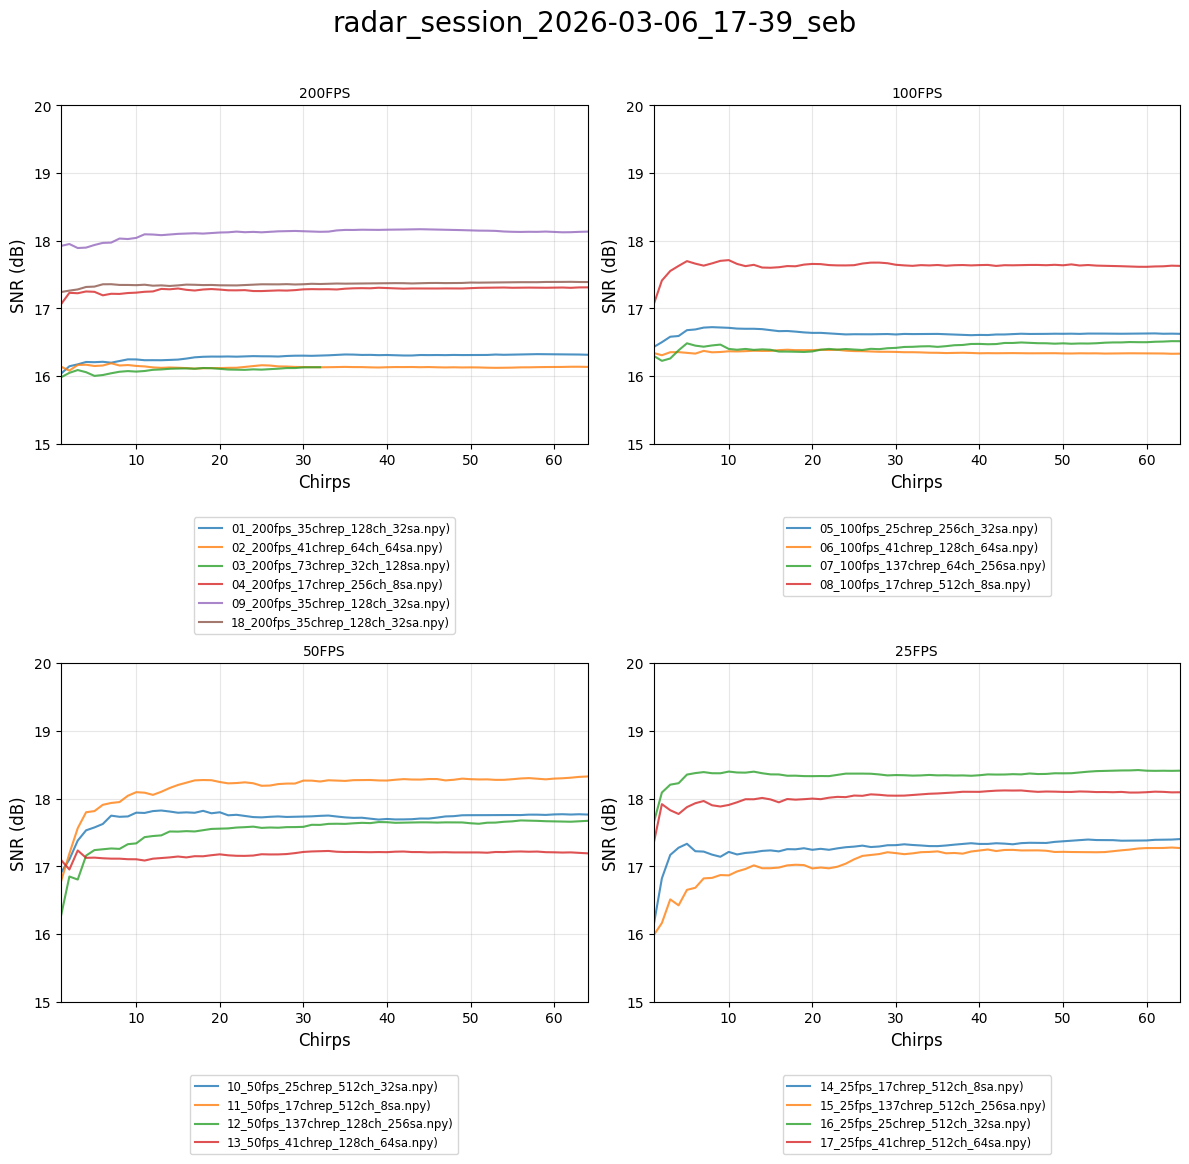

In [67]:

import os
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks
import matplotlib.pyplot as plt


input_folder = 'radar_session_2026-03-06_17-39_seb'

# Parameter (bleiben für alle gleich zum Vergleich)

target_bin_index = 1
time = 10

# Alle .npy Dateien finden
files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

#plt.figure(figsize=(12, 7))
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes_flat = axes.flatten()


for filename in files:
    # 1. Laden
    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)

    # Erwartet (Frames, Antennas, Chirps, Samples)
    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = num_frames/time 

    if fps == 200:
        ax = axes_flat[0]
        ax.set_title(f"200FPS", fontsize=10)
    if fps == 100:
        ax = axes_flat[1]
        ax.set_title(f"100FPS", fontsize=10)
    if fps == 50:
        ax = axes_flat[2]
        ax.set_title(f"50FPS", fontsize=10)
    if fps == 25:
        ax = axes_flat[3]
        ax.set_title(f"25FPS", fontsize=10)
    
    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, target_bin_index] # Alle Chirps des Bins
    
    snr = []

    # print(bin_values.shape)
    # print(bin_values[:, :32].shape)
    for i in range(1, num_chirps + 1):
        complex_mean_1 = np.mean(bin_values[:, :i], axis=1)
        phase_signal_1 = np.angle(complex_mean_1)

        #Unwrapping um 2pi-Sprünge zu entfernen
        unwrapped_phase_1 = np.unwrap(phase_signal_1)

        RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

        c = 3e8                                     # speed of light m/s
        wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)   # in meters
        wavelength_mm = wavelength_m * 1000         # in mm

        # Convert unwrapped phase (radians) → displacement (mm)
        displacement_mm_1 = (wavelength_mm * unwrapped_phase_1) / (4 * np.pi)


        signal = bandpass_filter(displacement_mm_1, fps, lowcut=0.5, highcut=6, order=3)
        noise = bandpass_filter(displacement_mm_1, fps, lowcut=6, highcut=12, order=3)

        p_signal = np.mean(signal ** 2)
        p_noise  = np.mean(noise ** 2)

        snr.append(10 * np.log10(p_signal / p_noise))

    #label_name = filename.split('_')[1] if '_' in filename else filename
    label_name = filename
    ax.plot(range(1, num_chirps + 1), snr, label=f"{label_name})", alpha=0.8)
    
    ax.set_ylabel("SNR (dB)", fontsize=12)
    ax.set_xlabel("Chirps", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', fontsize='small') # Legende außen platzieren
    ax.set_xlim(1, 64)
    ax.set_ylim(15, 20)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
fig.suptitle(f"{input_folder}", fontsize=20)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks



def extract_middle_pulse_waveform_filterd(signal, fps, num_points=100):
    # 1. Filtern
    filtered = bandpass_filter(signal, fps=fps)
    #filtered = signal
    # 2. Peaks finden (mit Prominence für Stabilität)
    min_peak_distance = max(1, int(0.4 * fps))
    prominence = max(1e-9, 0.2 * np.std(filtered))
    peaks, _ = find_peaks(filtered, distance=min_peak_distance, prominence=prominence)
    
    if len(peaks) < 3: return None

    # 3. Segmente extrahieren und auf 100 Punkte resamplen
    beats = []
    for i in range(len(peaks) - 1):
        segment = filtered[peaks[i]:peaks[i+1]]
        if len(segment) < 4: continue
        
        x_old = np.linspace(0, 1, len(segment))
        x_new = np.linspace(0, 1, num_points)
        segment_resampled = np.interp(x_new, x_old, segment)
        beats.append(segment_resampled)
    
    if len(beats) < 2: return None
    
    beats = np.vstack(beats)
    mean_waveform = np.mean(beats, axis=0)
    
    # 4. Invertierung prüfen (Soll nach oben zeigen)
    k = max(3, int(0.10 * num_points))
    slope = np.polyfit(np.arange(k), mean_waveform[:k], 1)[0]
    if slope < 0:
        beats = -beats

    correlations = np.array([
        np.mean([np.corrcoef(beats[i], beats[j])[0, 1] 
                 for j in range(len(beats)) if i != j])
        for i in range(len(beats))
    ])
    median_beat = beats[np.argmax(correlations)]

    return np.linspace(0, 100, num_points), median_beat

def get_wave(range_fft, fps, chirps, range_bin=1):
    # Daten laden (shape: frames, antennas, chirps, samples)

    
    bin_values = range_fft[:, :, range_bin] # Alle Chirps des Bins
    
    complex_mean_1 = np.mean(bin_values[:, :chirps], axis=1)
    phase_signal_1 = np.angle(complex_mean_1)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
    unwrapped_phase_1 = np.unwrap(phase_signal_1)


    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm_1 = (wavelength_mm * unwrapped_phase_1) / (4 * np.pi)
        
    _, wave_1 = extract_middle_pulse_waveform_filterd(displacement_mm_1, fps)

    wave_1 = (wave_1 - np.min(wave_1)) / (np.max(wave_1) - np.min(wave_1))

    return wave_1


def get_ref(file_path, fps, range_bin=1):
    # Daten laden (shape: frames, antennas, chirps, samples)
    data = np.load(file_path)
    
    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, range_bin] # Alle Chirps des Bins
    
    # Mittelwert über Chirps und Phase berechnen
    #print(bin_values.shape)
   # print(bin_values[:, :32].shape)
    complex_mean_all = np.mean(bin_values, axis=1)
    phase_signal_all = np.angle(complex_mean_all)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
    unwrapped_phase_all = np.unwrap(phase_signal_all)

    #filtered_ref_1 = bandpass_filter(unwrapped_phase_all, fps)

    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)   # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm_all = (wavelength_mm * unwrapped_phase_all) / (4 * np.pi)
        
    #print(displacement_mm_1.shape, '  ',displacement_mm_32.shape, '  ',displacement_mm_all.shape,)

    # Durchschnittlichen Beat berechnen
    _, wave_1 = extract_middle_pulse_waveform_filterd(displacement_mm_all, fps)

        
    wave_1 = (wave_1 - np.min(wave_1)) / (np.max(wave_1) - np.min(wave_1))

    return wave_1

def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0
    return np.dot(a, b) / denom


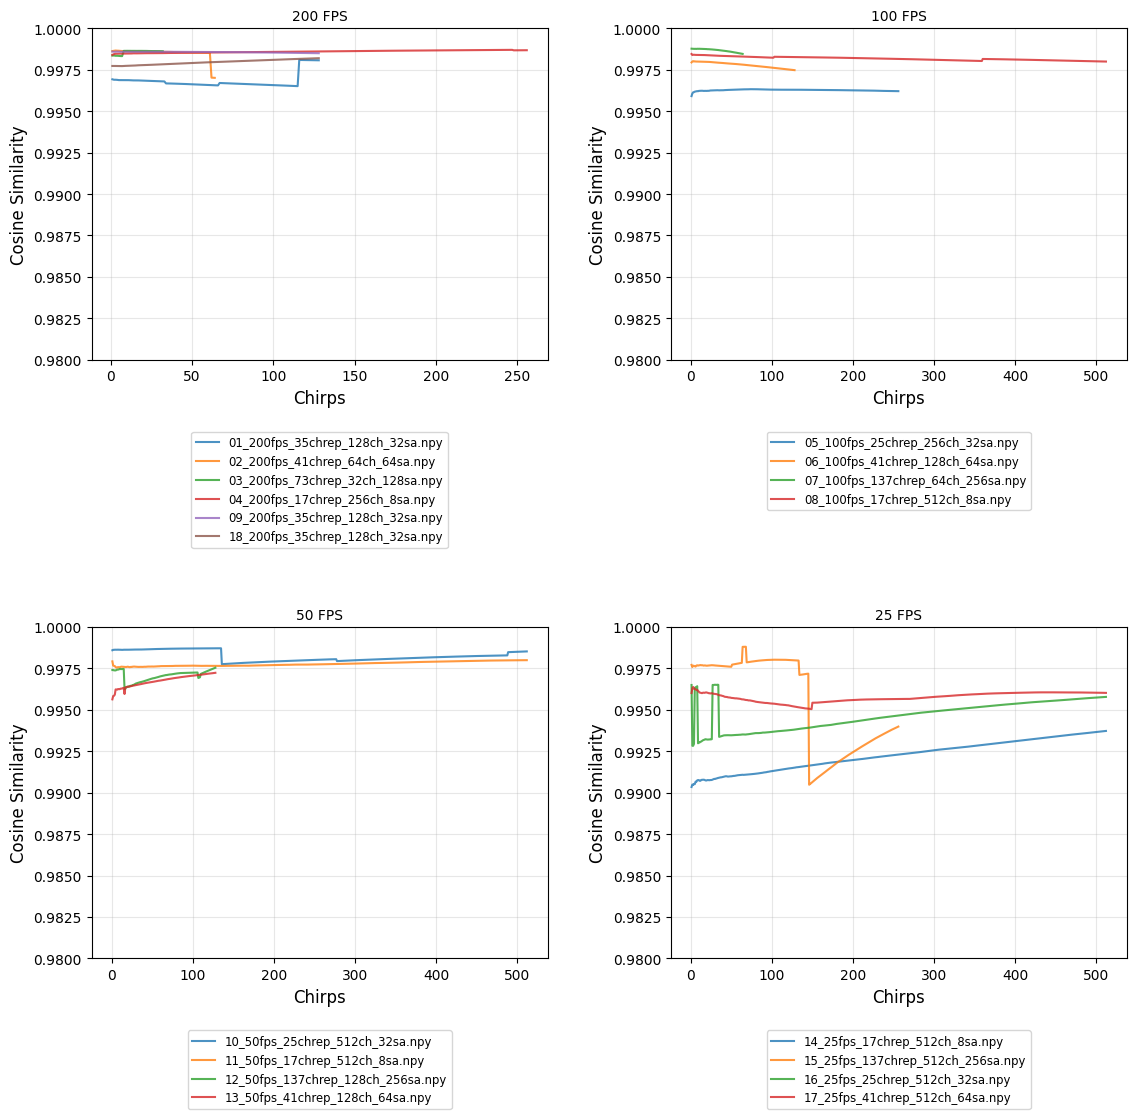

In [78]:
input_folder = 'radar_session_2026-03-06_16-57_nima'

time = 10

max_chirps = 512

files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

ref1 = get_ref(os.path.join(input_folder,'01_200fps_35chrep_128ch_32sa.npy'), 200)
ref2 = get_ref(os.path.join(input_folder,'09_200fps_35chrep_128ch_32sa.npy'), 200)
ref3 = get_ref(os.path.join(input_folder,'18_200fps_35chrep_128ch_32sa.npy'), 200)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes_flat = axes.flatten()


for i, filename in enumerate(files):

    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)
    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = int(num_frames/time)

    if fps == 200:
        ax = axes_flat[0]
        ax.set_title("200 FPS", fontsize=10)
    if fps == 100:
        ax = axes_flat[1]
        ax.set_title("100 FPS", fontsize=10)
    if fps == 50:
        ax = axes_flat[2]
        ax.set_title("50 FPS", fontsize=10)
    if fps == 25:
        ax = axes_flat[3]
        ax.set_title("25 FPS", fontsize=10)

    output = []
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)

    for chirpcount in range(1, num_chirps+1):
       
        wave = get_wave(range_fft,fps,chirpcount)

        cos1 = cosine_similarity(ref1, wave)
        cos2 = cosine_similarity(ref2, wave)
        cos3 = cosine_similarity(ref3, wave)
        output.append((cos1+cos2+cos3)/3.0)

        #if chirpcount == max_chirps:
        #    break




    label_name = filename
    ax.plot(range(1, np.min([max_chirps + 1, num_chirps+1])), output, label=f"{label_name}", alpha=0.8)
    
    ax.set_xlabel("Chirps", fontsize=12)
    ax.set_ylabel("Cosine Similarity", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', fontsize='small') # Legende außen platzieren
    #ax.set_xlim(1, 64)
    ax.set_ylim(0.980, 1)
    
    
plt.tight_layout(pad=3.0) # Erhöht den Abstand zwischen den Plots
plt.subplots_adjust(top=0.95) # Platz für eine Hauptüberschrift
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks



def extract_average_pulse_waveform_filterd(signal, fps, num_points=100):
    # 1. Filtern
    filtered = bandpass_filter(signal, fps=fps)
    
    #filtered = signal
    # 2. Peaks finden (mit Prominence für Stabilität)
    min_peak_distance = max(1, int(0.4 * fps))
    prominence = max(1e-9, 0.2 * np.std(filtered))
    peaks, _ = find_peaks(filtered, distance=min_peak_distance, prominence=prominence)
    
    if len(peaks) < 3: return None

    # 3. Segmente extrahieren und auf 100 Punkte resamplen
    beats = []
    for i in range(len(peaks) - 1):
        segment = filtered[peaks[i]:peaks[i+1]]
        if len(segment) < 4: continue
        
        x_old = np.linspace(0, 1, len(segment))
        x_new = np.linspace(0, 1, num_points)
        segment_resampled = np.interp(x_new, x_old, segment)
        beats.append(segment_resampled)
    
    if len(beats) < 2: return None
    
    beats = np.vstack(beats)
    mean_waveform = np.mean(beats, axis=0)
    
    # 4. Invertierung prüfen (Soll nach oben zeigen)
    k = max(3, int(0.10 * num_points))
    slope = np.polyfit(np.arange(k), mean_waveform[:k], 1)[0]
    if slope < 0:
        beats = -beats
        mean_waveform = np.mean(beats, axis=0)

    return np.linspace(0, 100, num_points), mean_waveform

def get_wave_mean(range_fft, fps, chirps, range_bin=1):
    # Daten laden (shape: frames, antennas, chirps, samples)

    
    bin_values = range_fft[:, :, range_bin] # Alle Chirps des Bins
    
    complex_mean_1 = np.mean(bin_values[:, :chirps], axis=1)
    phase_signal_1 = np.angle(complex_mean_1)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
    unwrapped_phase_1 = np.unwrap(phase_signal_1)


    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)  # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm_1 = (wavelength_mm * unwrapped_phase_1) / (4 * np.pi)
        
    _, wave_1 = extract_average_pulse_waveform_filterd(displacement_mm_1, fps)

    wave_1 = (wave_1 - np.min(wave_1)) / (np.max(wave_1) - np.min(wave_1))

    return wave_1


def get_ref_mean(file_path, fps, range_bin=1):
    # Daten laden (shape: frames, antennas, chirps, samples)
    data = np.load(file_path)
    
    # Phase extrahieren (wie in deinem RadarReader)
    # Wir nehmen Antenne 0 und den gewählten Range-Bin
    # FFT über die Samples pro Chirp
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)
    bin_values = range_fft[:, :, range_bin] # Alle Chirps des Bins
    
    # Mittelwert über Chirps und Phase berechnen
    #print(bin_values.shape)
   # print(bin_values[:, :32].shape)
    complex_mean_all = np.mean(bin_values, axis=1)
    phase_signal_all = np.angle(complex_mean_all)
    
    # WICHTIG: Unwrapping um 2pi-Sprünge zu entfernen
    unwrapped_phase_all = np.unwrap(phase_signal_all)

    #filtered_ref_1 = bandpass_filter(unwrapped_phase_all, fps)

    RADAR_FREQ_GHZ = 60.75  # e.g. 60 or 77

    c = 3e8                                     # speed of light m/s
    wavelength_m = c / (RADAR_FREQ_GHZ * 1e9)   # in meters
    wavelength_mm = wavelength_m * 1000         # in mm

    # Convert unwrapped phase (radians) → displacement (mm)
    displacement_mm_all = (wavelength_mm * unwrapped_phase_all) / (4 * np.pi)
        
    #print(displacement_mm_1.shape, '  ',displacement_mm_32.shape, '  ',displacement_mm_all.shape,)

    # Durchschnittlichen Beat berechnen
    _, wave_1 = extract_average_pulse_waveform_filterd(displacement_mm_all, fps)

        
    wave_1 = (wave_1 - np.min(wave_1)) / (np.max(wave_1) - np.min(wave_1))

    return wave_1

def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0
    return np.dot(a, b) / denom

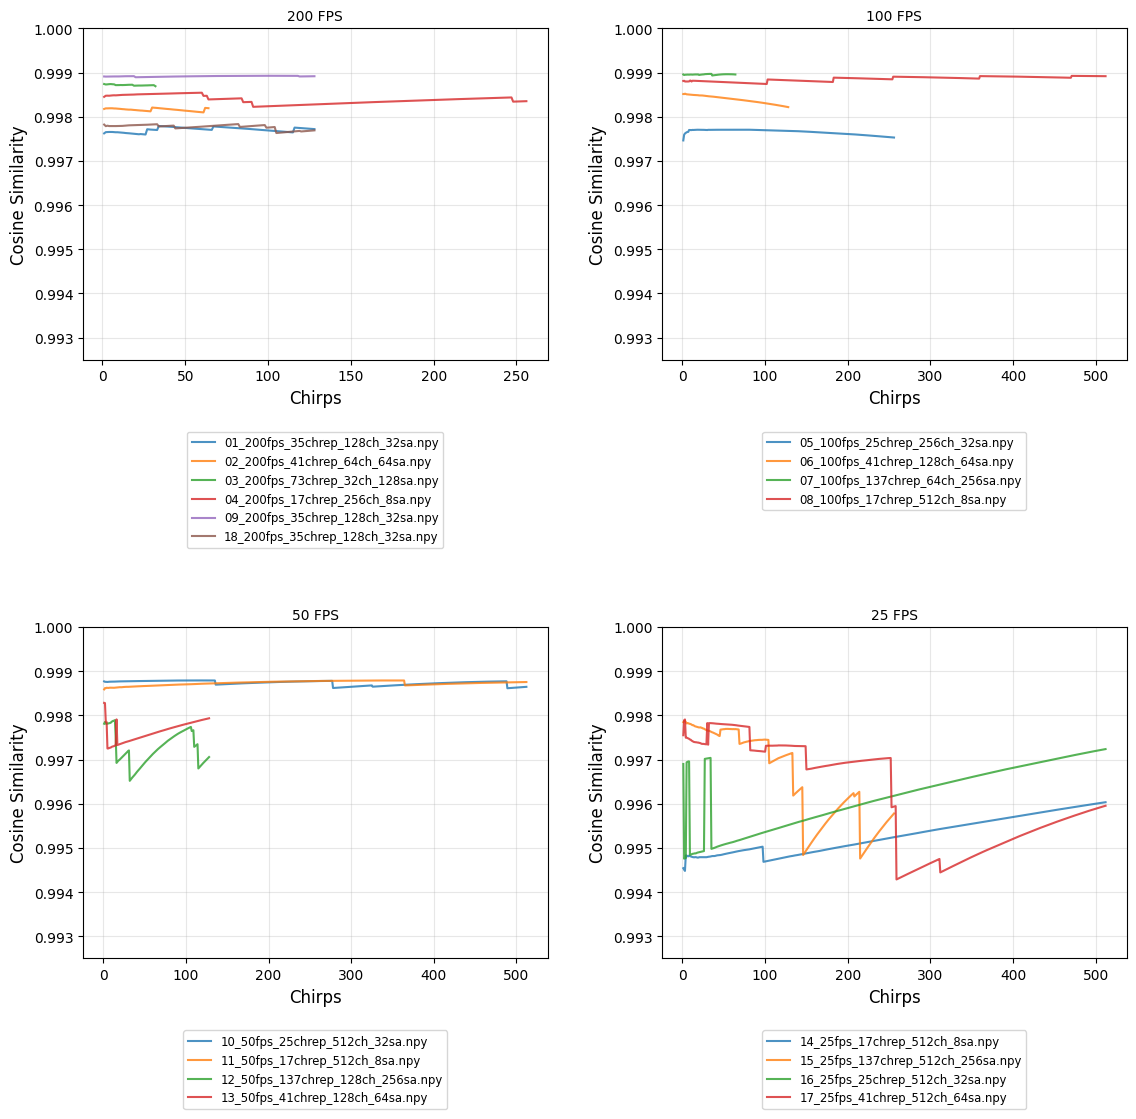

In [73]:
input_folder = 'radar_session_2026-03-06_16-57_nima'

time = 10

max_chirps = 512

files = sorted([f for f in os.listdir(input_folder) if f.endswith('.npy')])

ref1 = get_ref_mean(os.path.join(input_folder,'01_200fps_35chrep_128ch_32sa.npy'), 200)
ref2 = get_ref_mean(os.path.join(input_folder,'09_200fps_35chrep_128ch_32sa.npy'), 200)
ref3 = get_ref_mean(os.path.join(input_folder,'18_200fps_35chrep_128ch_32sa.npy'), 200)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes_flat = axes.flatten()


for i, filename in enumerate(files):

    file_path = os.path.join(input_folder, filename)
    data = np.load(file_path)
    num_frames, num_ant, num_chirps, num_samples = data.shape
    fps = int(num_frames/time)

    if fps == 200:
        ax = axes_flat[0]
        ax.set_title("200 FPS", fontsize=10)
    if fps == 100:
        ax = axes_flat[1]
        ax.set_title("100 FPS", fontsize=10)
    if fps == 50:
        ax = axes_flat[2]
        ax.set_title("50 FPS", fontsize=10)
    if fps == 25:
        ax = axes_flat[3]
        ax.set_title("25 FPS", fontsize=10)

    output = []
    range_fft = np.fft.fft(data[:, 0, :, :], axis=-1)

    for chirpcount in range(1, num_chirps+1):
       
        wave = get_wave_mean(range_fft,fps,chirpcount)

        cos1 = cosine_similarity(ref1, wave)
        cos2 = cosine_similarity(ref2, wave)
        cos3 = cosine_similarity(ref3, wave)
        output.append((cos1+cos2+cos3)/3.0)

        #if chirpcount == max_chirps:
        #    break




    label_name = filename
    ax.plot(range(1, np.min([max_chirps + 1, num_chirps+1])), output, label=f"{label_name}", alpha=0.8)
    
    ax.set_xlabel("Chirps", fontsize=12)
    ax.set_ylabel("Cosine Similarity", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(0.5, -0.2), loc='upper center', fontsize='small') # Legende außen platzieren
    #ax.set_xlim(1, 64)
    ax.set_ylim(0.9925, 1)
    
    
plt.tight_layout(pad=3.0) # Erhöht den Abstand zwischen den Plots
plt.subplots_adjust(top=0.95) # Platz für eine Hauptüberschrift
plt.show()

In [1]:
import numpy as np

data = np.load('test123.npy')
data = data/4095
print(np.shape(data))



(2000, 1, 32, 8)
